# Base de datos y primeras tomas de contacto

In [1]:
import os

ruta = r"C:\Users\jimena\OneDrive\Documentos\4 CARRERA\TFG"
print(os.listdir(ruta))

['2 entrega tfg.pdf', '20260407_Sesión_1_TFG_actualizada.pdf', 'base.csv', 'crear base de datos.ipynb', 'código BASE.ipynb', 'etr_cuestionario.pdf', 'etr_metodologia.pdf', 'figuras_clustering', 'figuras_eda', 'figuras_famd', 'guía de uso de los ficheros.pdf', 'Imágenes', 'Microdatos', 'prueba base.ipynb']


In [2]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

BASE_PATH = r"C:\Users\jimena\OneDrive\Documentos\4 CARRERA\TFG\base.csv"
base = pd.read_csv(BASE_PATH, sep=";")

In [4]:
# Info rápida
print("Shape:", base.shape)
print("Años:", sorted(base["ANYO"].unique()))
print("Meses:", sorted(base["MES"].unique()))

# Comprobar que cada año tiene 12 meses
meses_por_anyo = base.groupby("ANYO")["MES"].nunique().sort_index()
print("\nMeses distintos por año:")
print(meses_por_anyo)

# Detectar meses que faltan por año
faltan = []
for anyo in sorted(base["ANYO"].unique()):
    meses_presentes = set(base.loc[base["ANYO"] == anyo, "MES"].unique())
    meses_esperados = set(range(1, 13))
    missing = sorted(list(meses_esperados - meses_presentes))
    if missing:
        faltan.append((anyo, missing))

print("\nMeses que faltan:")
print(faltan if faltan else "Ninguno")

# Filas por año
filas_por_anyo = base.groupby("ANYO").size().sort_index()
print("\nFilas por año:")
print(filas_por_anyo)

# Filas por año-mes
filas_por_anyo_mes = base.groupby(["ANYO","MES"]).size().unstack(fill_value=0).sort_index()
print("\nTabla filas por año-mes:")
print(filas_por_anyo_mes)

# Duplicados exactos de filas
dup_rows = base.duplicated().sum()
print("\nFilas duplicadas exactas:", dup_rows)

# NA% por columna (top 20 con más NA)
na_pct = (base.isna().mean().sort_values(ascending=False) * 100).head(20)
print("\nTop 20 columnas con más %NA:")
print(na_pct)


Shape: (551108, 118)
Años: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Meses: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Meses distintos por año:
ANYO
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
Name: MES, dtype: int64

Meses que faltan:
Ninguno

Filas por año:
ANYO
2016    69522
2017    74248
2018    74096
2019    70079
2020    35902
2021    51989
2022    54935
2023    59208
2024    61129
dtype: int64

Tabla filas por año-mes:
MES     1     2     3     4     5     6     7     8     9     10    11    12
ANYO                                                                        
2016  5251  4482  6177  4924  5928  5445  7068  8611  6247  5636  4864  4889
2017  5328  5031  5099  7149  5911  5946  8012  9051  6541  620

In [5]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551108 entries, 0 to 551107
Columns: 118 entries, MES to ZIP_ORIGEN
dtypes: float64(63), int64(42), object(13)
memory usage: 496.1+ MB


Variables con pocos valores distintos (candidatas a categóricas)

In [6]:
low_card = []

for col in base.columns:
    nun = base[col].nunique()
    if nun <= 20:
        low_card.append((col, nun))

low_card = sorted(low_card, key=lambda x: x[1])
print("Variables con <=20 valores distintos:")
print(low_card[:40])
print("Total:", len(low_card))

Variables con <=20 valores distintos:
[('DESTESP', 2), ('VIAJA_SOLO', 2), ('VIAJA_PAREJA', 2), ('VIAJA_HIJOS', 2), ('VIAJA_OTROSFAMILIARES', 2), ('VIAJA_AMIGOS', 2), ('VIAJA_COMPTRABAJO', 2), ('PAQ_TRANSP', 2), ('PAQ_ALOJA', 2), ('PAQ_COMBEB', 2), ('PAQ_ACT', 2), ('BLOQUE_ETAPAS', 2), ('IMPU_PARCIAL', 2), ('GASTO_PAQ', 2), ('GASTO_ALOJA', 2), ('GASTO_TRANS', 2), ('GASTO_BAREST', 2), ('GASTO_ACT', 2), ('GASTO_BIENDUR', 2), ('GASTO_RESTO', 2), ('PPAL_TRANSP_PAQ', 2), ('PPAL_ALOJA_PAQ', 2), ('ACTI_GOLF', 2), ('ACTI_DEPOR', 2), ('ACTI_NAVEGA', 2), ('ACTI_OTROSNAUTICOS', 2), ('ACTI_CAZA', 2), ('ACTI_SENDER', 2), ('ACTI_AVENTURA', 2), ('ACTI_CABALLO', 2), ('ACTI_OTROSDEPORTES', 2), ('ACTI_ESPECDEPOR', 2), ('ACTI_VISITASCULTU', 2), ('ACTI_ESPECULTU', 2), ('ACTI_OTRASCULTU', 2), ('ACTI_CIUDADES', 2), ('ACTI_RURALES', 2), ('ACTI_TEMATICOS', 2), ('ACTI_RELAX', 2), ('ACTI_JUEGOS', 2)]
Total: 98


In [7]:
num_vars = base.select_dtypes(include=["int64","float64"]).columns
print("Numéricas:", len(num_vars))

obj_vars = base.select_dtypes(include=["object"]).columns
print("Object:", len(obj_vars))
print(obj_vars)

Numéricas: 105
Object: 13
Index(['GASTOFI_PAQ', 'GASTOFI_ALOJA', 'GASTOFI_TRANS', 'GASTOFI_BAREST',
       'GASTOFI_ACT', 'GASTOFI_BIENDUR', 'GASTOFI_RESTO', 'GASTOFI_TOTAL',
       'CORR15_VT', 'FACTORVI_15MAS', 'FACTORVI_TOT', 'FACTORGAS_TOT',
       'ZIP_ORIGEN'],
      dtype='object')


# Preprocesamiento y limpieza

Tamaño y estructura de la base

In [8]:
base.shape
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551108 entries, 0 to 551107
Columns: 118 entries, MES to ZIP_ORIGEN
dtypes: float64(63), int64(42), object(13)
memory usage: 496.1+ MB


In [9]:
num_vars = base.select_dtypes(include=["int64","float64"]).columns
obj_vars = base.select_dtypes(include=["object"]).columns

print(len(num_vars))
print(len(obj_vars))

105
13


In [10]:
base[col].nunique()

108

MUESTRA ALEATORIA PARA EDA

In [11]:
muestra = base.sample(n=100000, random_state=42)

# EDA ANTIGUO

Viajes por año

ANYO
2016    69522
2017    74248
2018    74096
2019    70079
2020    35902
2021    51989
2022    54935
2023    59208
2024    61129
dtype: int64


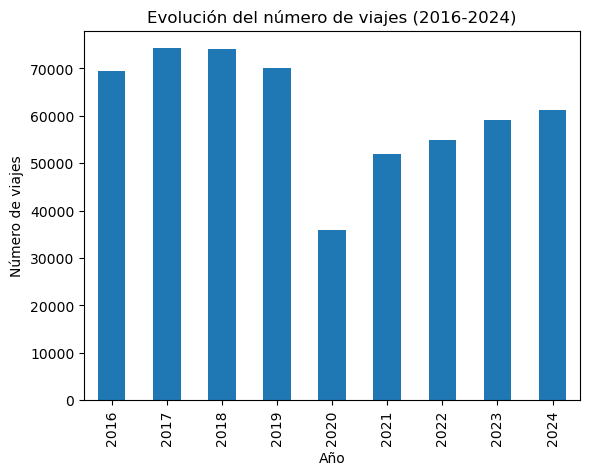

In [12]:
import matplotlib.pyplot as plt

# Viajes por año (conteo de registros)
viajes_anyo = base.groupby("ANYO").size()

print(viajes_anyo)

# Gráfico
plt.figure()
viajes_anyo.plot(kind="bar")

plt.xlabel("Año")
plt.ylabel("Número de viajes")
plt.title("Evolución del número de viajes (2016-2024)")

plt.show()

Viajes por mes

MES
1     40596
2     36601
3     38825
4     43669
5     42408
6     45427
7     59292
8     72277
9     50233
10    43849
11    36504
12    41427
dtype: int64


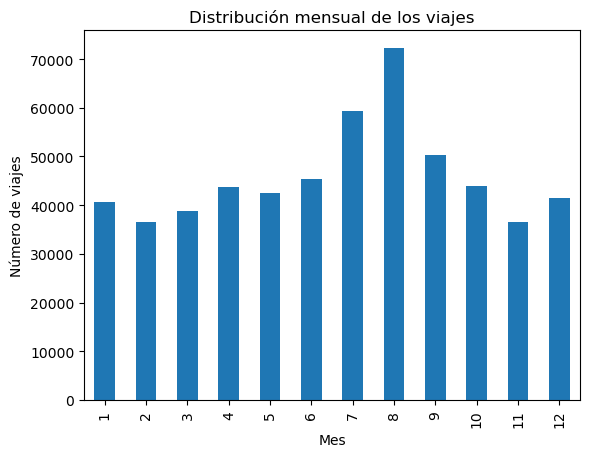

In [13]:
# Viajes por mes
viajes_mes = base.groupby("MES").size()

print(viajes_mes)

import matplotlib.pyplot as plt

plt.figure()
viajes_mes.plot(kind="bar")

plt.xlabel("Mes")
plt.ylabel("Número de viajes")
plt.title("Distribución mensual de los viajes")

plt.show()

Heatmap Año mes

In [14]:
# Tabla año-mes
tabla_anyo_mes = base.groupby(["ANYO", "MES"]).size().unstack(fill_value=0)

print(tabla_anyo_mes)

MES     1     2     3     4     5     6     7     8     9     10    11    12
ANYO                                                                        
2016  5251  4482  6177  4924  5928  5445  7068  8611  6247  5636  4864  4889
2017  5328  5031  5099  7149  5911  5946  8012  9051  6541  6201  4722  5257
2018  5481  5087  5572  6914  5823  5764  7718  9011  6592  5917  4957  5260
2019  5462  5135  5574  6511  5416  6207  6815  7952  6000  4869  4608  5530
2020  4787  4198  1438   171   725  2231  4717  6823  4056  2784  1851  2121
2021  2031  1921  2471  3013  4230  4968  6282  8116  5304  5036  4166  4451
2022  3987  3925  4046  5277  4726  4493  5931  6773  4491  4000  3338  3948
2023  3835  3081  3223  4936  4686  4810  6569  8084  5471  5211  4071  5231
2024  4434  3741  5225  4774  4963  5563  6180  7856  5531  4195  3927  4740


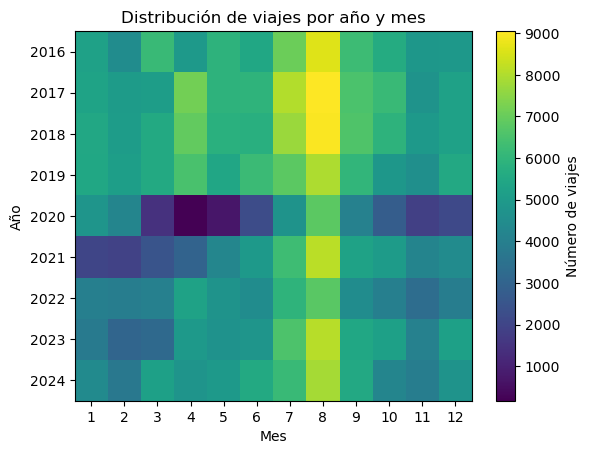

In [15]:
import matplotlib.pyplot as plt

plt.figure()

plt.imshow(tabla_anyo_mes, aspect='auto')

plt.colorbar(label="Número de viajes")

plt.xlabel("Mes")
plt.ylabel("Año")
plt.title("Distribución de viajes por año y mes")

# Etiquetas
plt.xticks(range(12), range(1,13))
plt.yticks(range(len(tabla_anyo_mes.index)), tabla_anyo_mes.index)

plt.show()

# EDA MEJORADO

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

In [25]:
OUTPUT_DIR  = r"C:\Users\jimena\OneDrive\Documentos\4 CARRERA\TFG\figuras_eda"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def guardar(fig, nombre):
    """Guarda la figura en OUTPUT_DIR y la cierra."""
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    ruta = os.path.join(OUTPUT_DIR, nombre)
    fig.savefig(ruta, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"   ✓ Guardada: {ruta}")


PESO_VIAJES     = "FACTORVI_TOT"
VAR_ANYO        = "ANYO"
VAR_MES         = "MES"
VAR_DURACION    = "NPERNOC_CORR"   # pernoctaciones corregidas
VAR_GASTO       = "GASTOFI_TOTAL"  # gasto total corregido INE
VAR_MOTIVO      = "MOTIV"
VAR_ALOJAMIENTO = "ALOJAPRIN"
VAR_TRANSPORTE  = "TRANSPRIN"
VAR_DESTINO     = "DESTESP"        # 1=España, 2=Extranjero

# Estilo de los gráficos
PALETTE_ANYO  = sns.color_palette("Blues_d", 9)
COLOR_BASE    = "#2c7bb6"
COLOR_ACCENT  = "#d7191c"
FIGSIZE_STD   = (11, 5)
FIGSIZE_WIDE  = (14, 6)
FIGSIZE_SQ    = (9, 7)

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight"})


RANDOM_STATE = 42

1. Carga y validación inicial

In [26]:
base = pd.read_csv(
    BASE_PATH,
    sep=";",
    decimal=",",
    thousands=".",
    low_memory=False
)

print(f"   Shape: {base.shape}")
print(f"   Memoria: {base.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Columnas numéricas clave
cols_numericas_clave = [PESO_VIAJES, VAR_ANYO, VAR_MES, VAR_DURACION, VAR_GASTO]



# Conversión
for col in cols_numericas_clave:
    if col in base.columns:
        base[col] = pd.to_numeric(base[col], errors="coerce")



print("\nTipos de variables clave:")
cols_presentes = [c for c in cols_numericas_clave if c in base.columns]
print(base[cols_presentes].dtypes)

print("\nNA en variables clave tras conversión:")
print(base[cols_presentes].isna().sum())

# Validaciones básicas
assert VAR_ANYO in base.columns, f"No existe la columna {VAR_ANYO}"
assert VAR_MES in base.columns, f"No existe la columna {VAR_MES}"
assert PESO_VIAJES in base.columns, f"No existe la columna {PESO_VIAJES}"

assert base[VAR_ANYO].notna().all(), "ANYO tiene NA tras conversión"
assert base[VAR_MES].notna().all(), "MES tiene NA tras conversión"
assert base[PESO_VIAJES].notna().all(), "FACTORVI_TOT tiene NA tras conversión"

assert base[VAR_ANYO].between(2016, 2024).all(), "Años fuera del rango esperado"
assert base[VAR_MES].between(1, 12).all(), "Meses fuera del rango esperado"
assert (base[PESO_VIAJES] > 0).all(), "Pesos no positivos detectados"
assert base.duplicated().sum() == 0, "Hay filas duplicadas exactas"

print("   ✓ Validaciones superadas\n")

# Submuestra
muestra = base.sample(n=min(100_000, len(base)), random_state=RANDOM_STATE)
print(f"   Submuestra para gráficos: {len(muestra):,} filas\n")

   Shape: (551108, 118)
   Memoria: 550.7 MB

Tipos de variables clave:
FACTORVI_TOT     float64
ANYO               int64
MES                int64
NPERNOC_CORR       int64
GASTOFI_TOTAL    float64
dtype: object

NA en variables clave tras conversión:
FACTORVI_TOT     0
ANYO             0
MES              0
NPERNOC_CORR     0
GASTOFI_TOTAL    0
dtype: int64
   ✓ Validaciones superadas

   Submuestra para gráficos: 100,000 filas



In [27]:
print("\nChequeo pesos:")
print(base[PESO_VIAJES].head(10))
print(base[PESO_VIAJES].describe())

print("\nChequeo gasto:")
print(base[VAR_GASTO].head(10))
print(base[VAR_GASTO].describe())


Chequeo pesos:
0    3198.971049
1    3198.971049
2    3573.372673
3    2908.021225
4    2908.021225
5    2908.021225
6    2908.021225
7    2908.021225
8    2419.238321
9    1877.684311
Name: FACTORVI_TOT, dtype: float64
count    551108.000000
mean       2815.647838
std        2903.725338
min           3.438782
25%        1020.662508
50%        1971.207793
75%        3633.899410
max       98175.773379
Name: FACTORVI_TOT, dtype: float64

Chequeo gasto:
0      35.79
1      35.79
2     592.67
3      12.67
4      12.67
5      12.67
6      12.67
7      12.67
8    1165.38
9      54.96
Name: GASTOFI_TOTAL, dtype: float64
count    551108.000000
mean        288.207837
std         474.476695
min           0.000000
25%          67.740000
50%         151.380000
75%         348.500000
max      120697.880000
Name: GASTOFI_TOTAL, dtype: float64


In [28]:
print(base[PESO_VIAJES].describe())
print(base[VAR_GASTO].describe())

count    551108.000000
mean       2815.647838
std        2903.725338
min           3.438782
25%        1020.662508
50%        1971.207793
75%        3633.899410
max       98175.773379
Name: FACTORVI_TOT, dtype: float64
count    551108.000000
mean        288.207837
std         474.476695
min           0.000000
25%          67.740000
50%         151.380000
75%         348.500000
max      120697.880000
Name: GASTOFI_TOTAL, dtype: float64


2. Funciones auxiliares

In [29]:
def guardar(fig, nombre):
    """Guarda la figura en OUTPUT_DIR y la cierra."""
    ruta = os.path.join(OUTPUT_DIR, nombre)
    fig.savefig(ruta, dpi=300)
    plt.close(fig)
    print(f"   ✓ Guardada: {nombre}") # Al final las guardo manualmente


def resumen_numerica(df, col, peso=None):
    """Estadísticos descriptivos (ponderados si se indica peso)."""
    aux = df[[col]].copy() if peso is None else df[[col, peso]].copy()
    aux = aux.dropna(subset=[col])

    if len(aux) == 0:
        return pd.Series(dtype=float)

    s = aux[col]

    if peso is None:
        return pd.Series({
            "n": len(s),
            "media": s.mean(),
            "mediana": s.median(),
            "std": s.std(),
            "p25": s.quantile(.25),
            "p75": s.quantile(.75),
            "min": s.min(),
            "max": s.max()
        })

    aux = aux.dropna(subset=[peso])
    s = aux[col]
    w = aux[peso]

    media_p = np.average(s, weights=w)

    # Cuantiles ponderados
    idx = np.argsort(s.values)
    sv = s.values[idx]
    wv = w.values[idx]
    acum = np.cumsum(wv) / wv.sum()

    p25 = np.interp(0.25, acum, sv)
    p50 = np.interp(0.50, acum, sv)
    p75 = np.interp(0.75, acum, sv)

    return pd.Series({
        "n_validos": len(s),
        "media_pond": media_p,
        "p25_pond": p25,
        "mediana_pond": p50,
        "p75_pond": p75,
        "min": sv.min(),
        "max": sv.max()
    })


def frecuencias_cat(df, col, peso=None, top_n=15):
    """Frecuencias absolutas y relativas (ponderadas si se indica peso)."""
    if col not in df.columns:
        return pd.DataFrame()

    if peso is None:
        t = df[col].value_counts(dropna=False).head(top_n).rename("n")
        t = t.to_frame().reset_index().rename(columns={"index": col})
        t["pct"] = 100 * t["n"] / t["n"].sum()
        return t

    aux = df[[col, peso]].dropna(subset=[peso]).copy()
    t = (
        aux.groupby(col, dropna=False)[peso]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .rename("peso_total")
        .reset_index()
    )
    t["pct_pond"] = 100 * t["peso_total"] / t["peso_total"].sum()
    return t


def etiqueta_destino(x):
    """Recodifica DESTESP si solo tiene 1/2."""
    if pd.isna(x):
        return "NA"
    if x == 1:
        return "España"
    if x == 2:
        return "Extranjero"
    return str(x)

3. Estadísticos de resumen tabulares

In [30]:
# Registros por año
registros_anyo = base.groupby(VAR_ANYO).size().rename("registros")
viajes_pond    = base.groupby(VAR_ANYO)[PESO_VIAJES].sum().rename("viajes_pond")
tabla_anyo     = pd.concat([registros_anyo, viajes_pond], axis=1)
tabla_anyo["pct_cambio_reg"] = tabla_anyo["registros"].pct_change() * 100

print("\nRegistros y viajes estimados por año:")
print(tabla_anyo.round(0).to_string())

# Descriptivos de gasto y duración (ponderados)
for var, label in [
    (VAR_GASTO, "Gasto total (€)"),
    (VAR_DURACION, "Duración (pernoctaciones)")
]:
    if var in base.columns:
        r = resumen_numerica(base, var, peso=PESO_VIAJES)
        print(f"\n{label}:")
        print(r.round(2).to_string())

# Descriptivos por año (sin ponderar)
if VAR_GASTO in base.columns:
    desc_gasto_anyo = (
        base.groupby(VAR_ANYO)[VAR_GASTO]
        .agg(["mean", "median", "std"])
        .round(2)
    )
    print("\nGasto medio y mediano por año (sin ponderar):")
    print(desc_gasto_anyo.to_string())

print()


Registros y viajes estimados por año:
      registros  viajes_pond  pct_cambio_reg
ANYO                                        
2016      69522  181950842.0             NaN
2017      74248  193689289.0             7.0
2018      74096  196079470.0            -0.0
2019      70079  193874716.0            -5.0
2020      35902  101523862.0           -49.0
2021      51989  142893461.0            45.0
2022      54935  171388138.0             6.0
2023      59208  185895163.0             8.0
2024      61129  184431108.0             3.0

Gasto total (€):
n_validos       551108.00
media_pond         281.07
p25_pond            67.02
mediana_pond       150.14
p75_pond           343.45
min                  0.00
max             120697.88

Duración (pernoctaciones):
n_validos       551108.00
media_pond           4.29
p25_pond             2.00
mediana_pond         2.00
p75_pond             4.00
min                  1.00
max                112.00

Gasto medio y mediano por año (sin ponderar):
        m

4. Evolución temporal

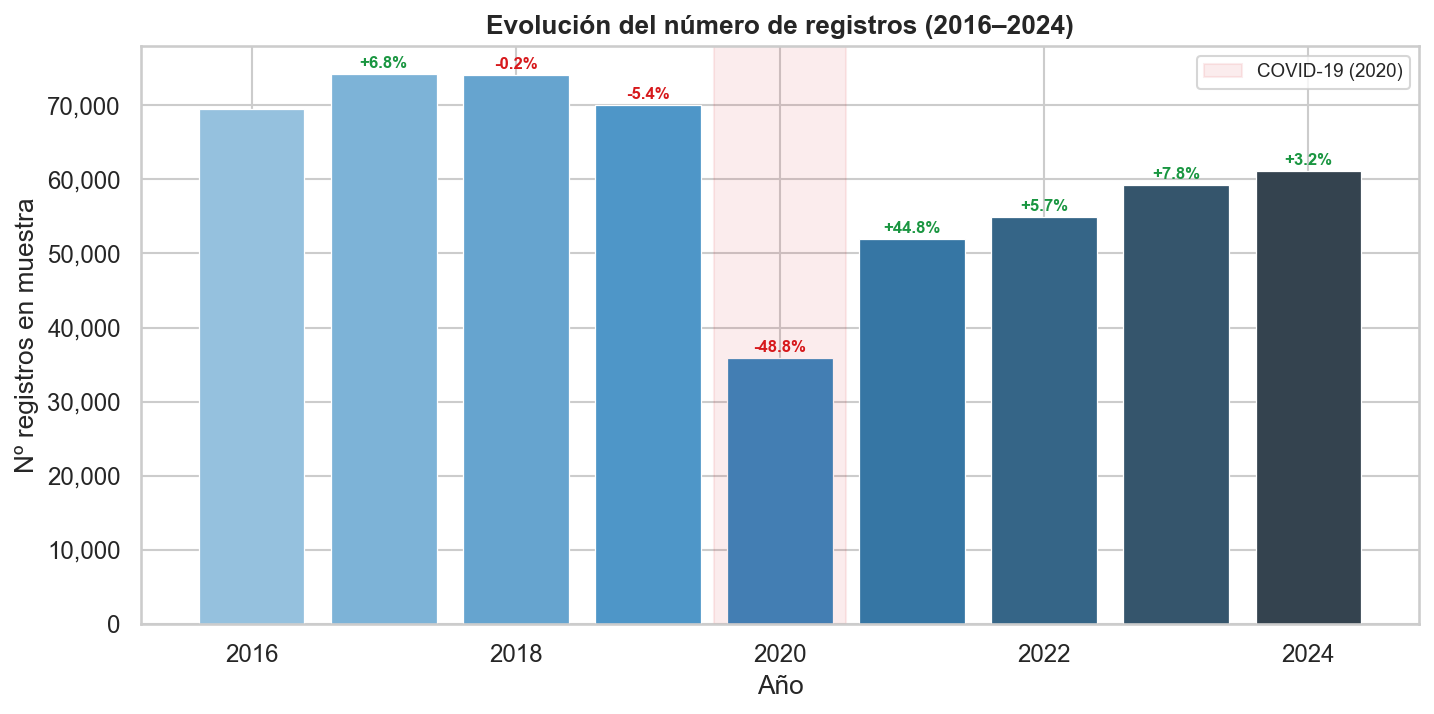

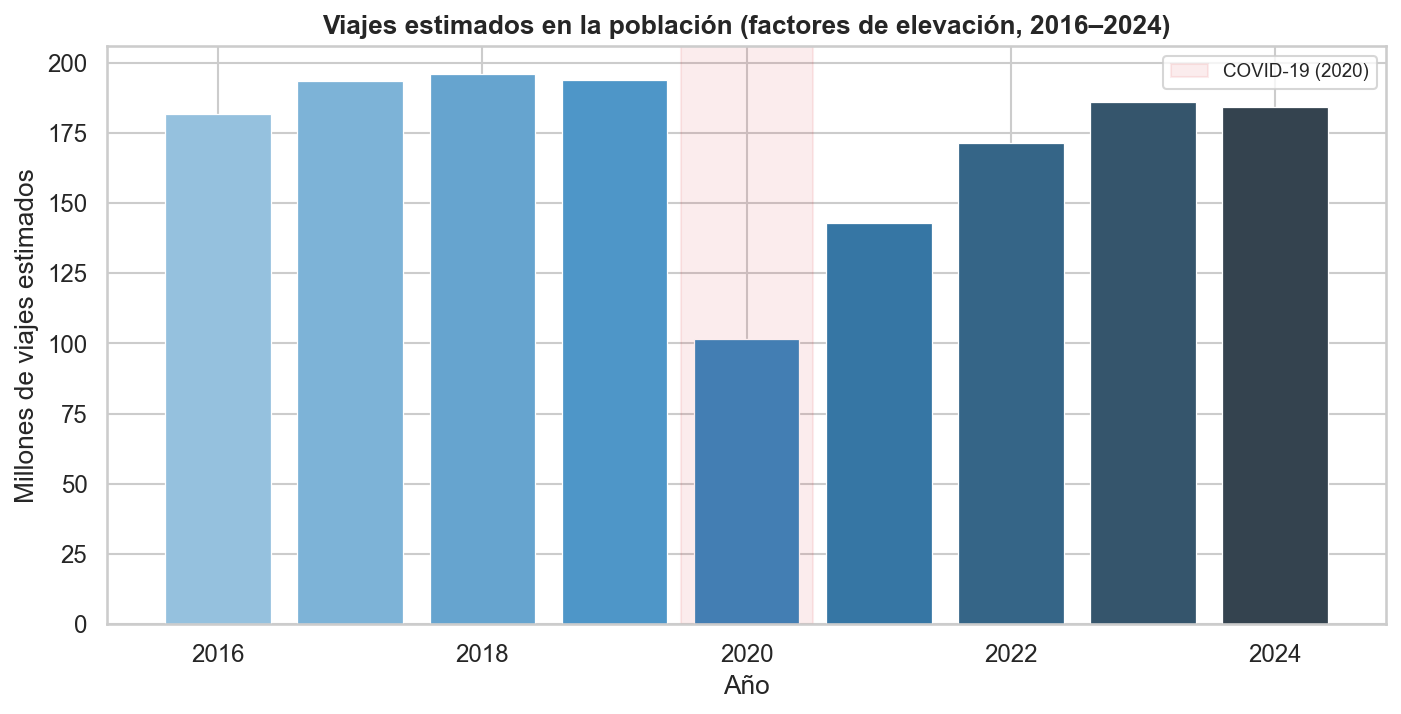

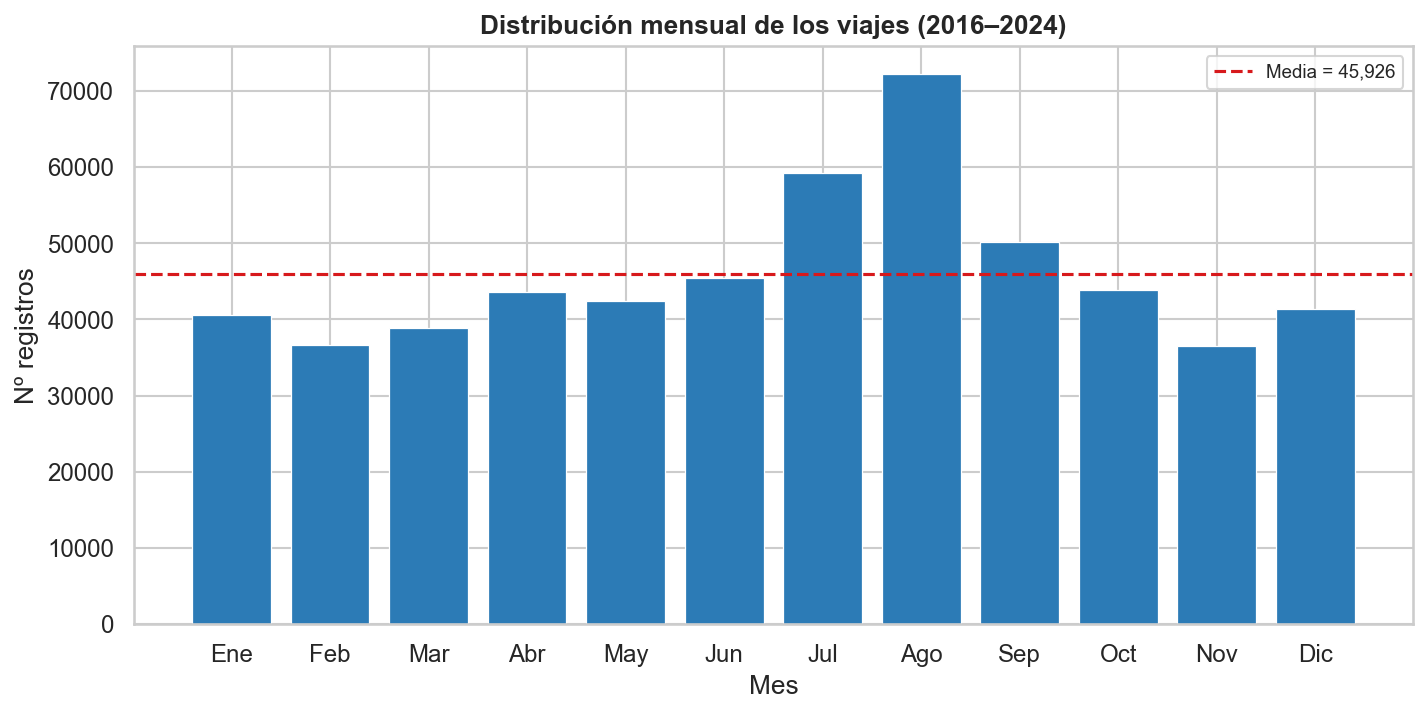

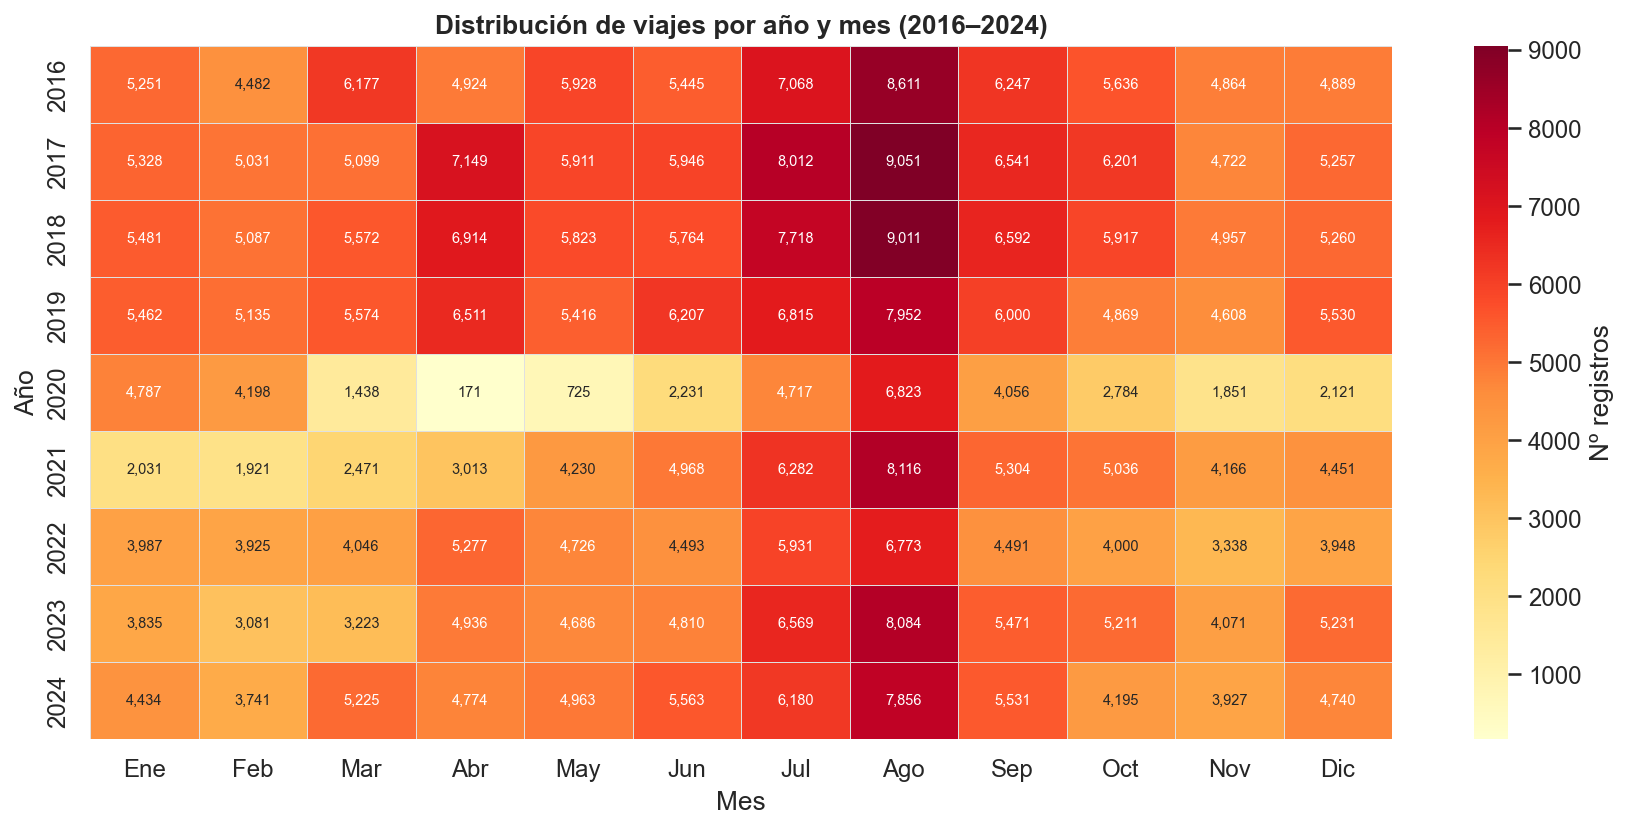

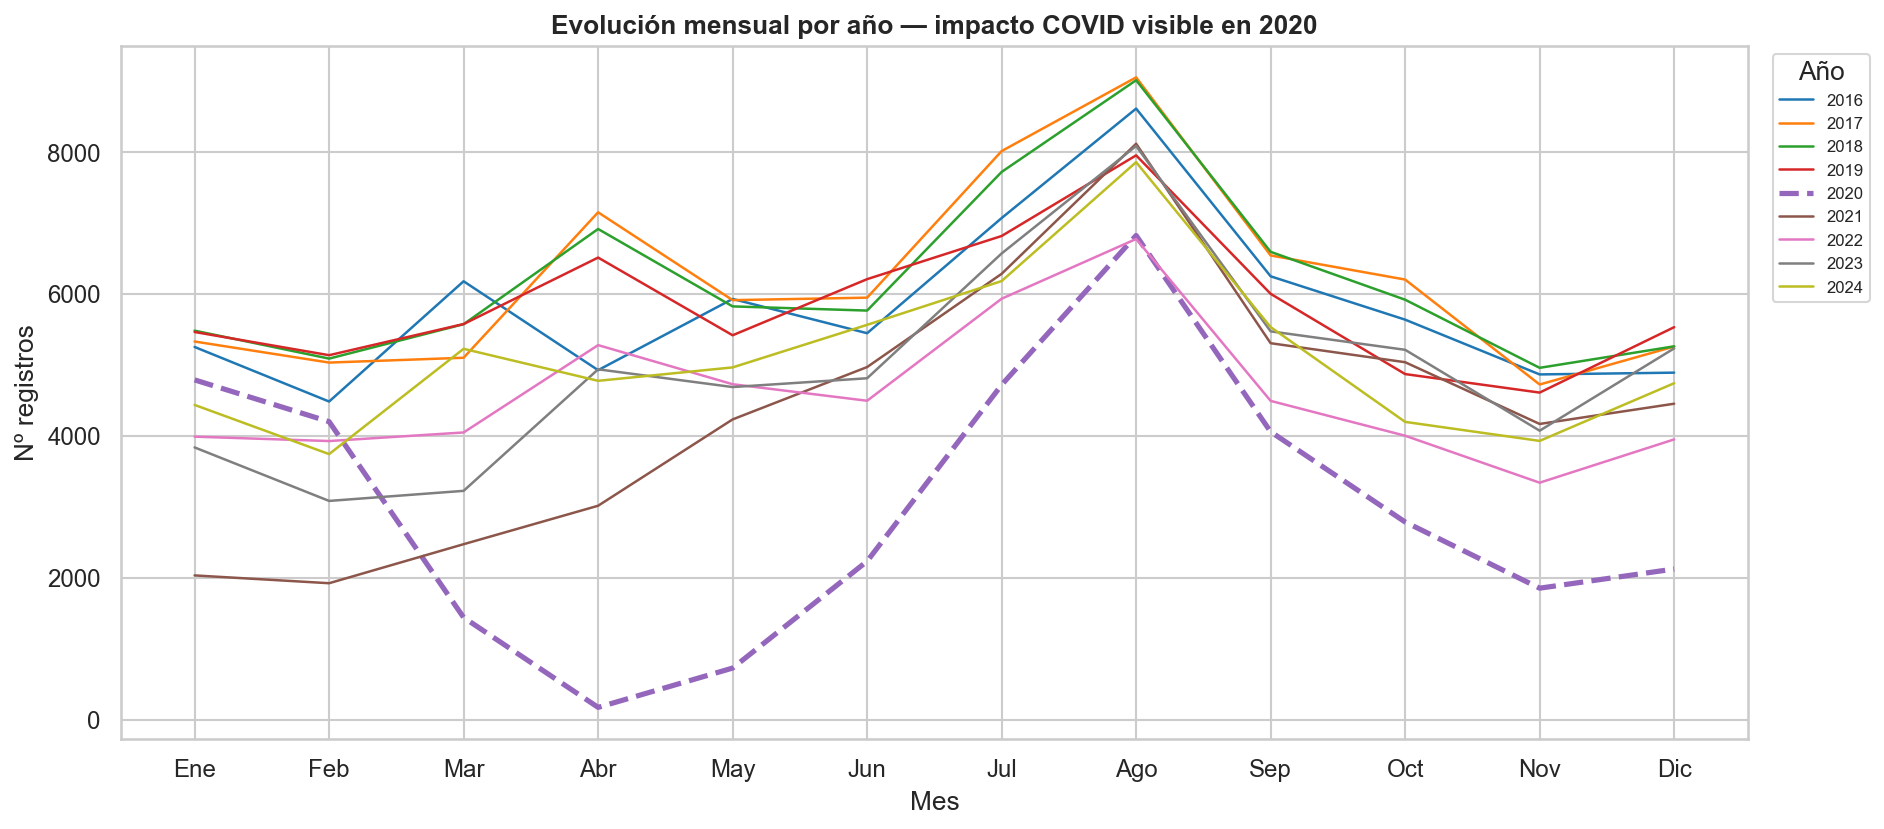

In [31]:
# Registros por año
fig, ax = plt.subplots(figsize=FIGSIZE_STD)
ax.bar(
    tabla_anyo.index.astype(int),
    tabla_anyo["registros"],
    color=PALETTE_ANYO,
    edgecolor="white",
    linewidth=0.6
)

for anyo, row in tabla_anyo.iterrows():
    pct = row["pct_cambio_reg"]
    if not np.isnan(pct):
        color = COLOR_ACCENT if pct < 0 else "#1a9641"
        ax.text(
            anyo, row["registros"] + 400, f"{pct:+.1f}%",
            ha="center", va="bottom", fontsize=8, color=color, fontweight="bold"
        )

ax.axvspan(2019.5, 2020.5, color=COLOR_ACCENT, alpha=0.08, label="COVID-19 (2020)")
ax.set_xlabel("Año")
ax.set_ylabel("Nº registros en muestra")
ax.set_title("Evolución del número de registros (2016–2024)", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=9)


# Viajes estimados por año
fig, ax = plt.subplots(figsize=FIGSIZE_STD)
ax.bar(
    tabla_anyo.index.astype(int),
    tabla_anyo["viajes_pond"] / 1e6,
    color=PALETTE_ANYO,
    edgecolor="white",
    linewidth=0.6
)
ax.axvspan(2019.5, 2020.5, color=COLOR_ACCENT, alpha=0.08, label="COVID-19 (2020)")
ax.set_xlabel("Año")
ax.set_ylabel("Millones de viajes estimados")
ax.set_title("Viajes estimados en la población (factores de elevación, 2016–2024)", fontweight="bold")
ax.legend(fontsize=9)


# Distribución mensual
viajes_mes = base.groupby(VAR_MES).size().rename("registros")

fig, ax = plt.subplots(figsize=FIGSIZE_STD)
ax.bar(
    viajes_mes.index.astype(int),
    viajes_mes.values,
    color=COLOR_BASE,
    edgecolor="white",
    linewidth=0.6
)
ax.axhline(
    viajes_mes.mean(),
    color=COLOR_ACCENT,
    linewidth=1.5,
    linestyle="--",
    label=f"Media = {viajes_mes.mean():,.0f}"
)
ax.set_xlabel("Mes")
ax.set_ylabel("Nº registros")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])
ax.set_title("Distribución mensual de los viajes (2016–2024)", fontweight="bold")
ax.legend(fontsize=9)


# Heatmap año × mes
tabla_anyo_mes = base.groupby([VAR_ANYO, VAR_MES]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
sns.heatmap(
    tabla_anyo_mes,
    cmap="YlOrRd",
    annot=True,
    fmt=",d",
    annot_kws={"fontsize": 7},
    linewidths=0.3,
    linecolor="#e0e0e0",
    cbar_kws={"label": "Nº registros"},
    ax=ax
)
ax.set_xlabel("Mes")
ax.set_ylabel("Año")
ax.set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"], rotation=0)
ax.set_title("Distribución de viajes por año y mes (2016–2024)", fontweight="bold")

# Líneas mensuales por año
pivot_lineas = tabla_anyo_mes.T

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
palette_lineas = sns.color_palette("tab10", n_colors=len(pivot_lineas.columns))

for i, anyo in enumerate(pivot_lineas.columns):
    lw = 2.5 if anyo == 2020 else 1.2
    ls = "--" if anyo == 2020 else "-"
    ax.plot(
        pivot_lineas.index,
        pivot_lineas[anyo],
        label=str(int(anyo)),
        color=palette_lineas[i],
        linewidth=lw,
        linestyle=ls
    )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])
ax.set_xlabel("Mes")
ax.set_ylabel("Nº registros")
ax.set_title("Evolución mensual por año — impacto COVID visible en 2020", fontweight="bold")
ax.legend(title="Año", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)



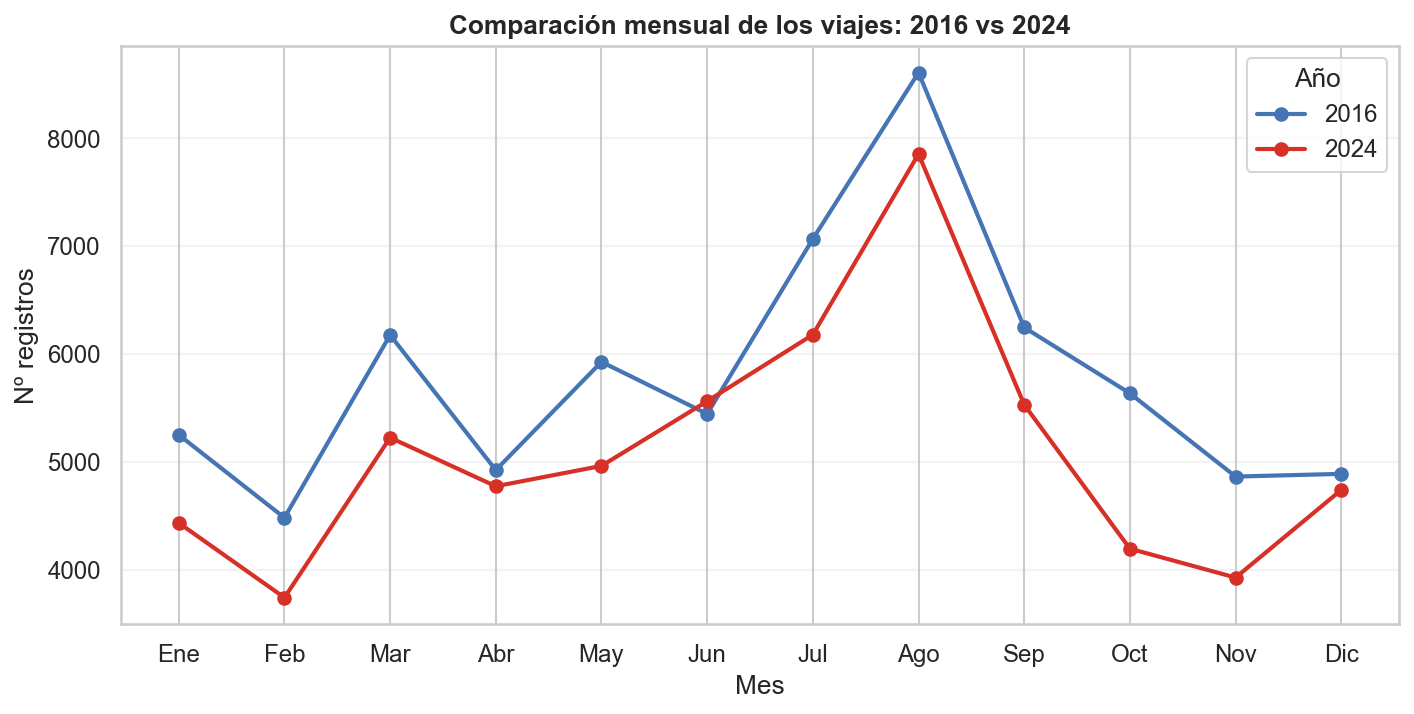

In [32]:
# Comparación mensual 2016 vs 2024
comparacion_2016_2024 = (
    base[base[VAR_ANYO].isin([2016, 2024])]
    .groupby([VAR_ANYO, VAR_MES])
    .size()
    .unstack(fill_value=0)
    .T
)

fig, ax = plt.subplots(figsize=FIGSIZE_STD)

ax.plot(
    comparacion_2016_2024.index,
    comparacion_2016_2024[2016],
    marker="o",
    linewidth=2,
    color="#4575b4",
    label="2016"
)

ax.plot(
    comparacion_2016_2024.index,
    comparacion_2016_2024[2024],
    marker="o",
    linewidth=2,
    color="#d73027",
    label="2024"
)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])

ax.set_xlabel("Mes")
ax.set_ylabel("Nº registros")
ax.set_title(
    "Comparación mensual de los viajes: 2016 vs 2024",
    fontweight="bold"
)

ax.legend(title="Año")
ax.grid(axis="y", alpha=0.25)

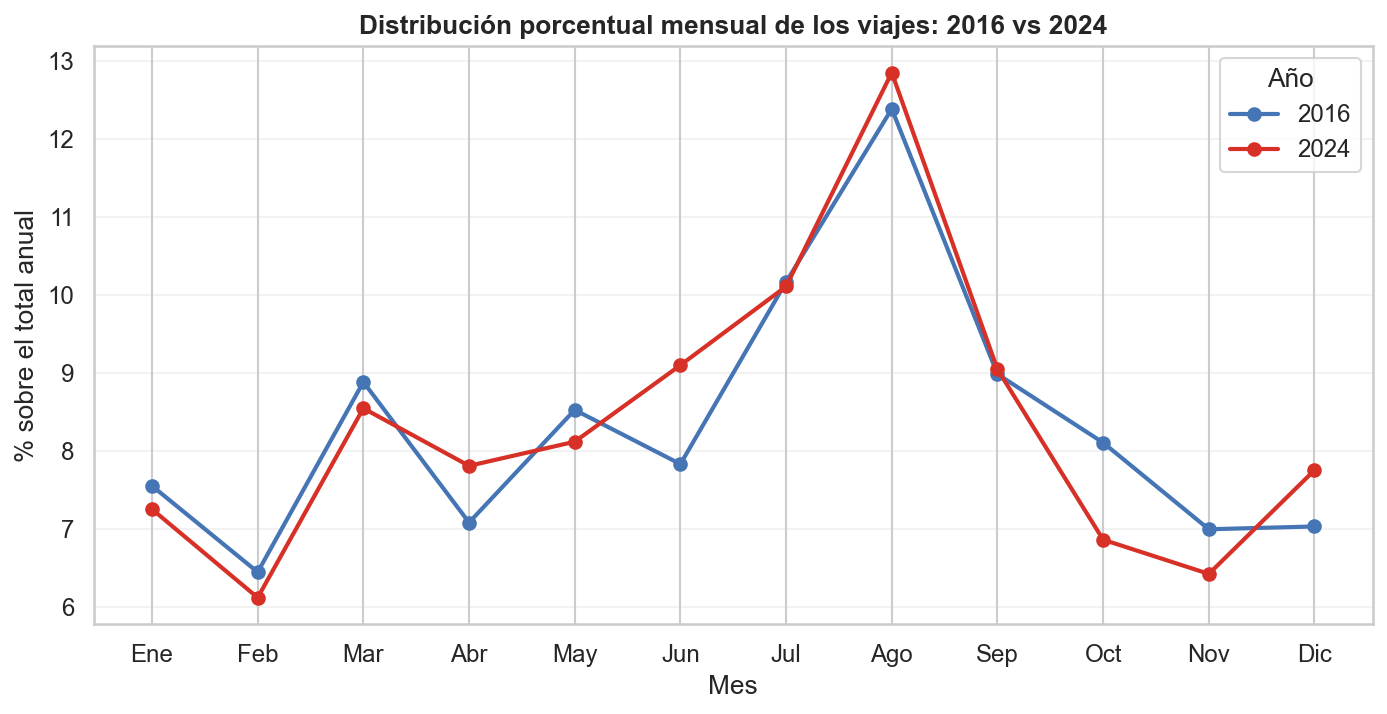

In [33]:
# Distribución porcentual mensual — 2016 vs 2024
comparacion_pct = comparacion_2016_2024.div(
    comparacion_2016_2024.sum(axis=0),
    axis=1
) * 100

fig, ax = plt.subplots(figsize=FIGSIZE_STD)

ax.plot(
    comparacion_pct.index,
    comparacion_pct[2016],
    marker="o",
    linewidth=2,
    color="#4575b4",
    label="2016"
)

ax.plot(
    comparacion_pct.index,
    comparacion_pct[2024],
    marker="o",
    linewidth=2,
    color="#d73027",
    label="2024"
)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])

ax.set_xlabel("Mes")
ax.set_ylabel("% sobre el total anual")
ax.set_title(
    "Distribución porcentual mensual de los viajes: 2016 vs 2024",
    fontweight="bold"
)

ax.legend(title="Año")
ax.grid(axis="y", alpha=0.25)

5. Análisis de gasto y duración

C:\Users\jimena\AppData\Local\Temp\ipykernel_10024\4244025050.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jimena\AppData\Local\Temp\ipykernel_10024\4244025050.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


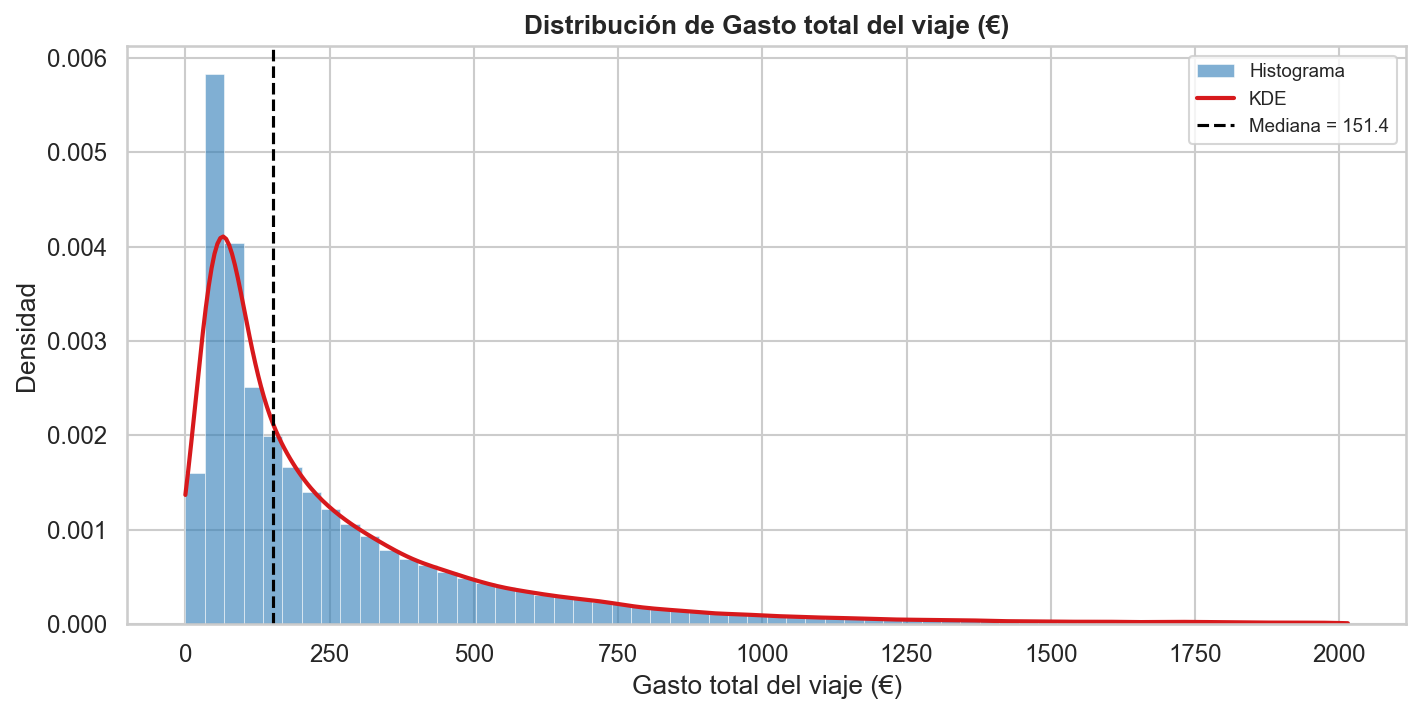

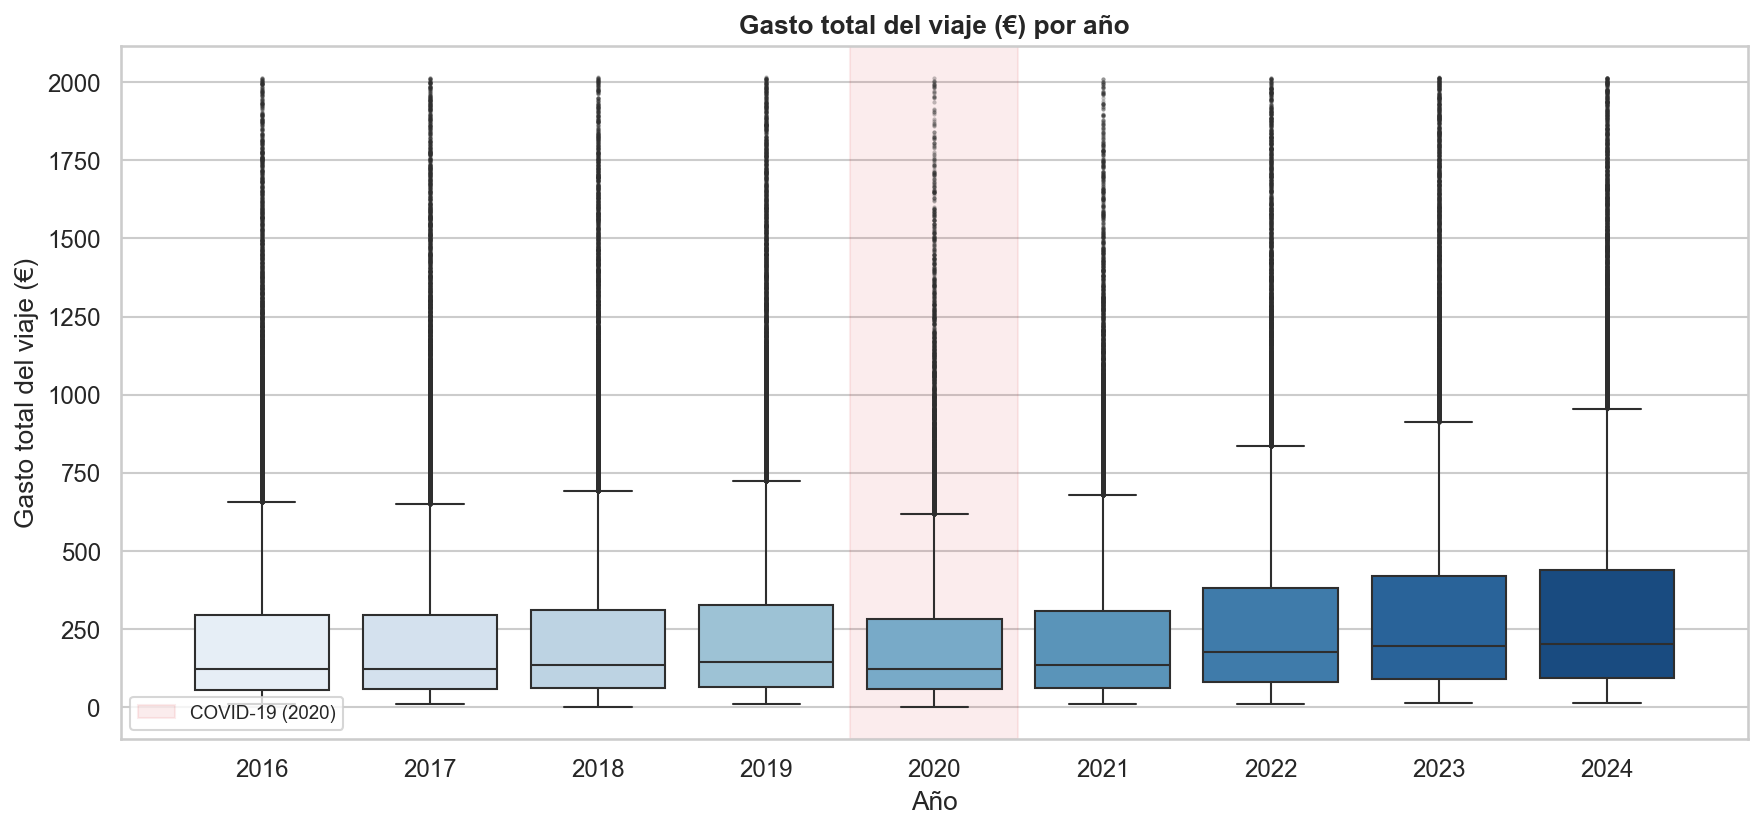

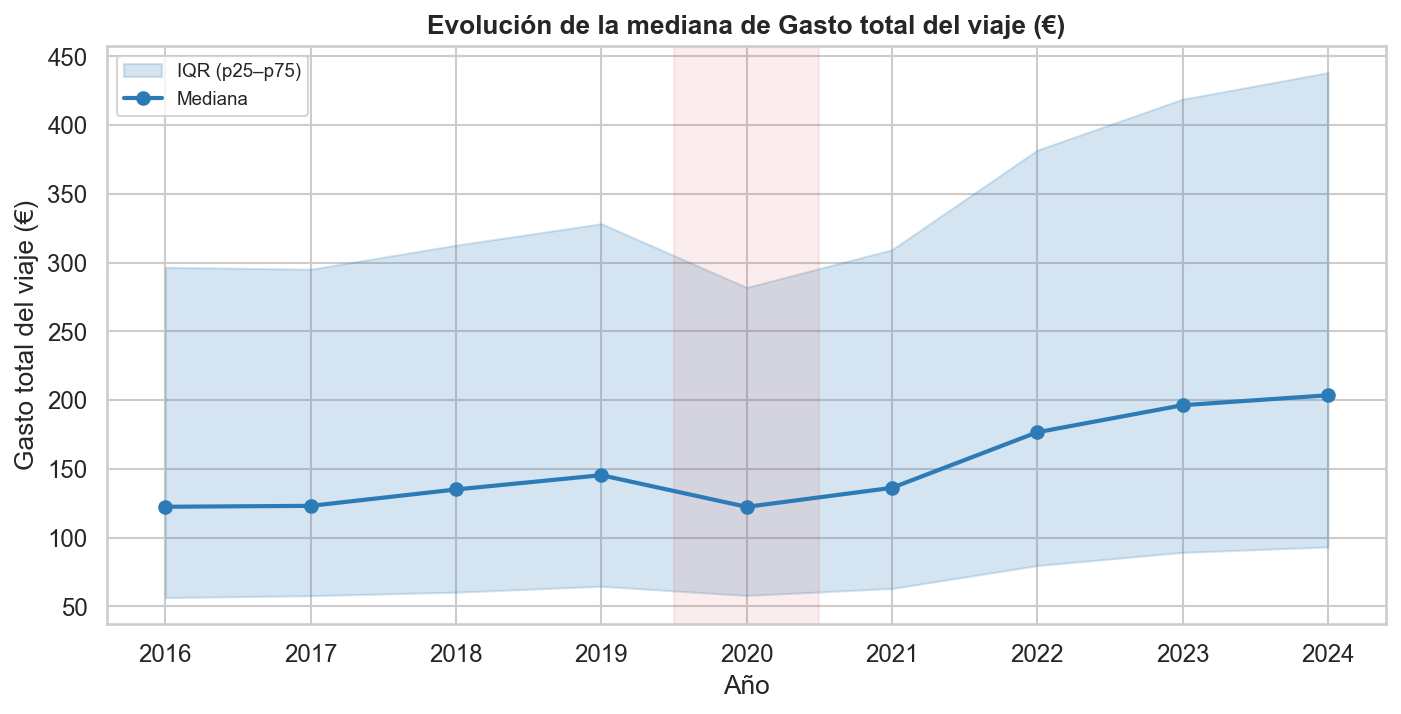

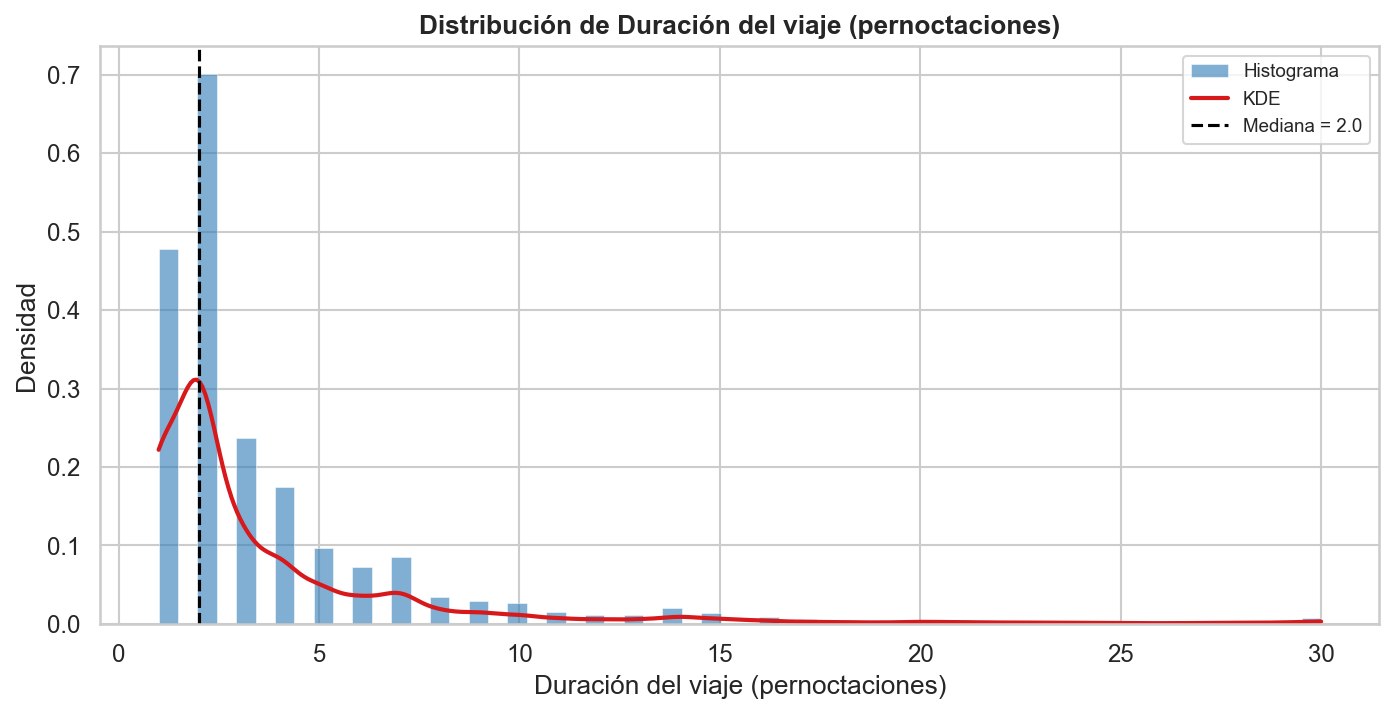

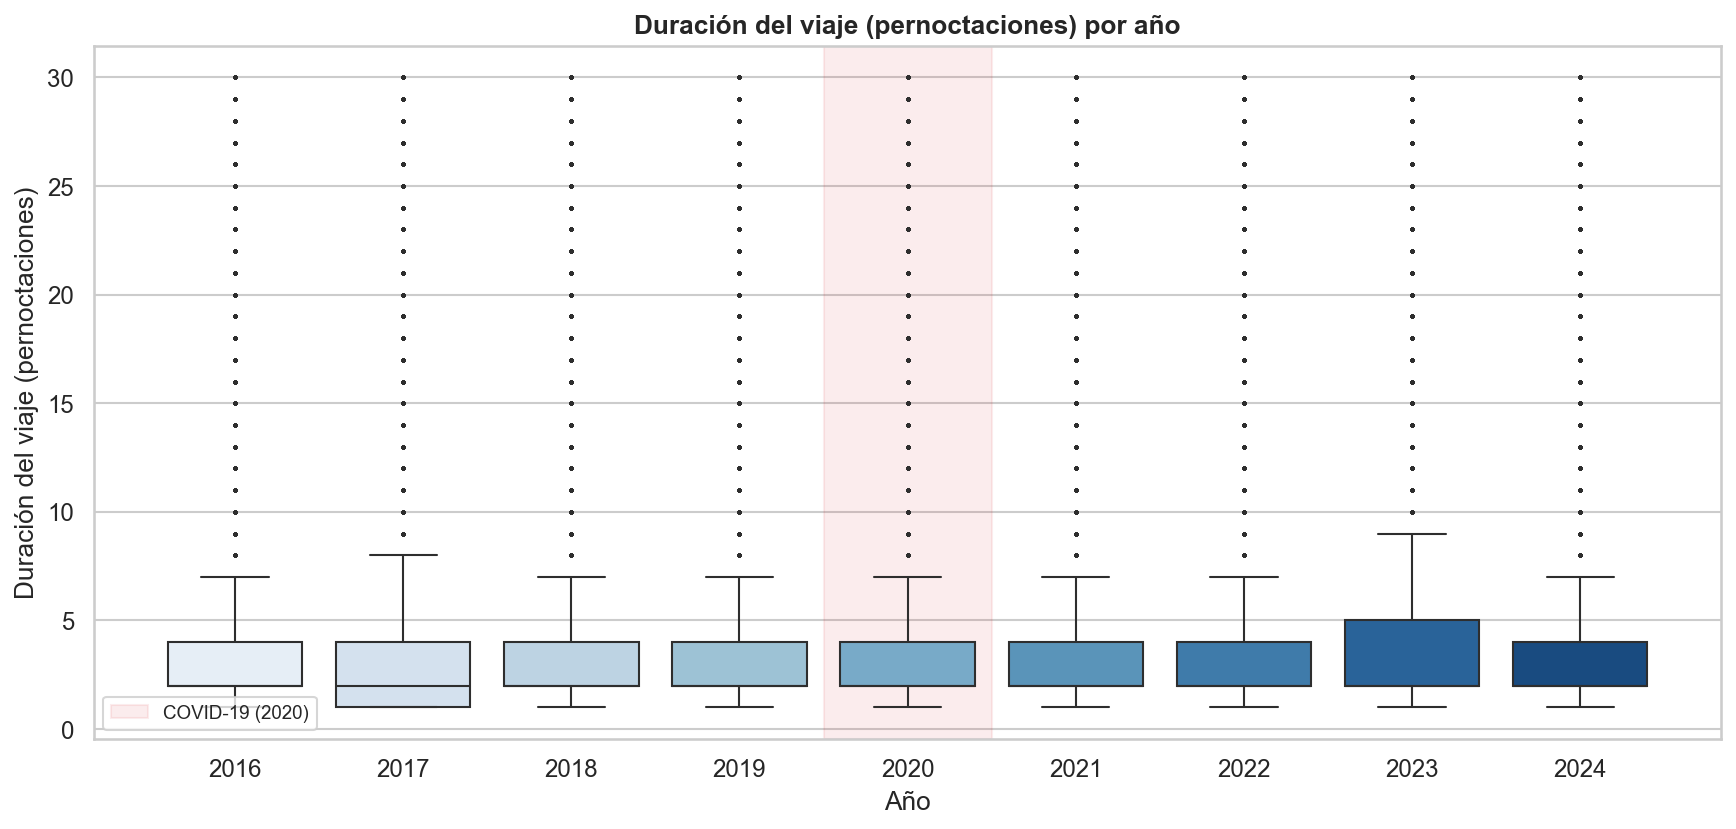

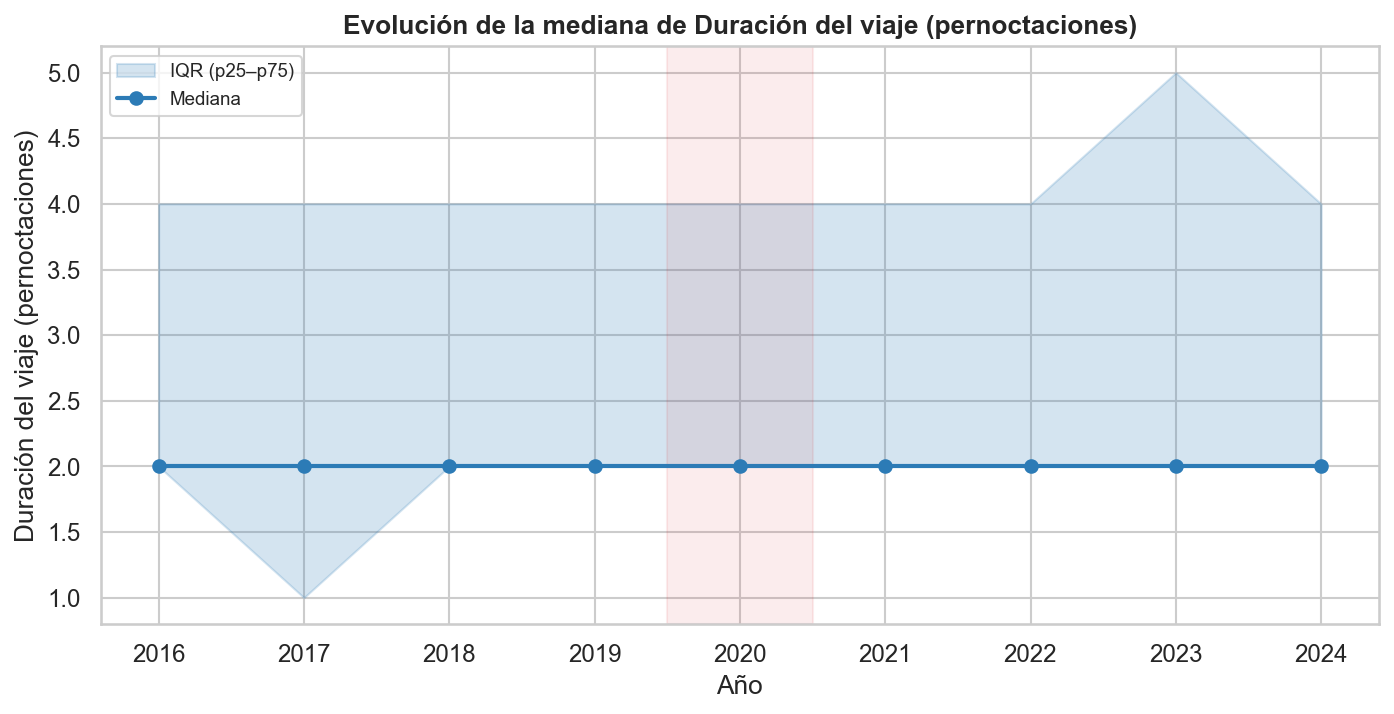

In [34]:
for var, label, fname_prefix in [
    (VAR_GASTO, "Gasto total del viaje (€)", "gasto"),
    (VAR_DURACION, "Duración del viaje (pernoctaciones)", "duracion"),
]:
    if var not in base.columns:
        print(f"   Variable {var} no encontrada, se omite.")
        continue

    serie = base[var].dropna()
    if len(serie) == 0:
        print(f"   Variable {var} vacía tras eliminar NA, se omite.")
        continue

    p99 = serie.quantile(0.99)
    serie_viz = serie[serie <= p99]

    # Histograma + KDE
    fig, ax = plt.subplots(figsize=FIGSIZE_STD)
    ax.hist(
        serie_viz,
        bins=60,
        density=True,
        color=COLOR_BASE,
        alpha=0.6,
        edgecolor="white",
        linewidth=0.4,
        label="Histograma"
    )

    sample_kde = serie_viz.sample(min(50_000, len(serie_viz)), random_state=RANDOM_STATE)
    if len(sample_kde) > 1 and sample_kde.nunique() > 1:
        kde_x = np.linspace(serie_viz.min(), serie_viz.max(), 400)
        kde = stats.gaussian_kde(sample_kde)
        ax.plot(kde_x, kde(kde_x), color=COLOR_ACCENT, linewidth=2, label="KDE")

    mediana = serie.median()
    ax.axvline(mediana, color="black", linewidth=1.5, linestyle="--", label=f"Mediana = {mediana:.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Densidad")
    ax.set_title(f"Distribución de {label}", fontweight="bold")
    ax.legend(fontsize=9)
   

    # Boxplot por año
    sub = base[[VAR_ANYO, var]].dropna()
    sub = sub[sub[var] <= p99]

    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
    sns.boxplot(
        data=sub,
        x=VAR_ANYO,
        y=var,
        palette="Blues",
        flierprops={"marker": ".", "markersize": 2, "alpha": 0.3},
        ax=ax
    )
    # posición 2020 en el eje categórico: 2016,17,18,19,20,... => índice 4
    ax.axvspan(3.5, 4.5, color=COLOR_ACCENT, alpha=0.08, label="COVID-19 (2020)")
    ax.set_xlabel("Año")
    ax.set_ylabel(label)
    ax.set_title(f"{label} por año", fontweight="bold")
    ax.legend(fontsize=9)
   

    # Mediana anual con banda IQR
    stats_anyo = sub.groupby(VAR_ANYO)[var].agg(
        mediana="median",
        q25=lambda x: x.quantile(.25),
        q75=lambda x: x.quantile(.75)
    )

    fig, ax = plt.subplots(figsize=FIGSIZE_STD)
    ax.fill_between(
        stats_anyo.index,
        stats_anyo["q25"],
        stats_anyo["q75"],
        alpha=0.2,
        color=COLOR_BASE,
        label="IQR (p25–p75)"
    )
    ax.plot(
        stats_anyo.index,
        stats_anyo["mediana"],
        "o-",
        color=COLOR_BASE,
        linewidth=2,
        markersize=6,
        label="Mediana"
    )
    ax.axvspan(2019.5, 2020.5, color=COLOR_ACCENT, alpha=0.08)
    ax.set_xlabel("Año")
    ax.set_ylabel(label)
    ax.set_title(f"Evolución de la mediana de {label}", fontweight="bold")
    ax.legend(fontsize=9)

6. Variables categóricas clave

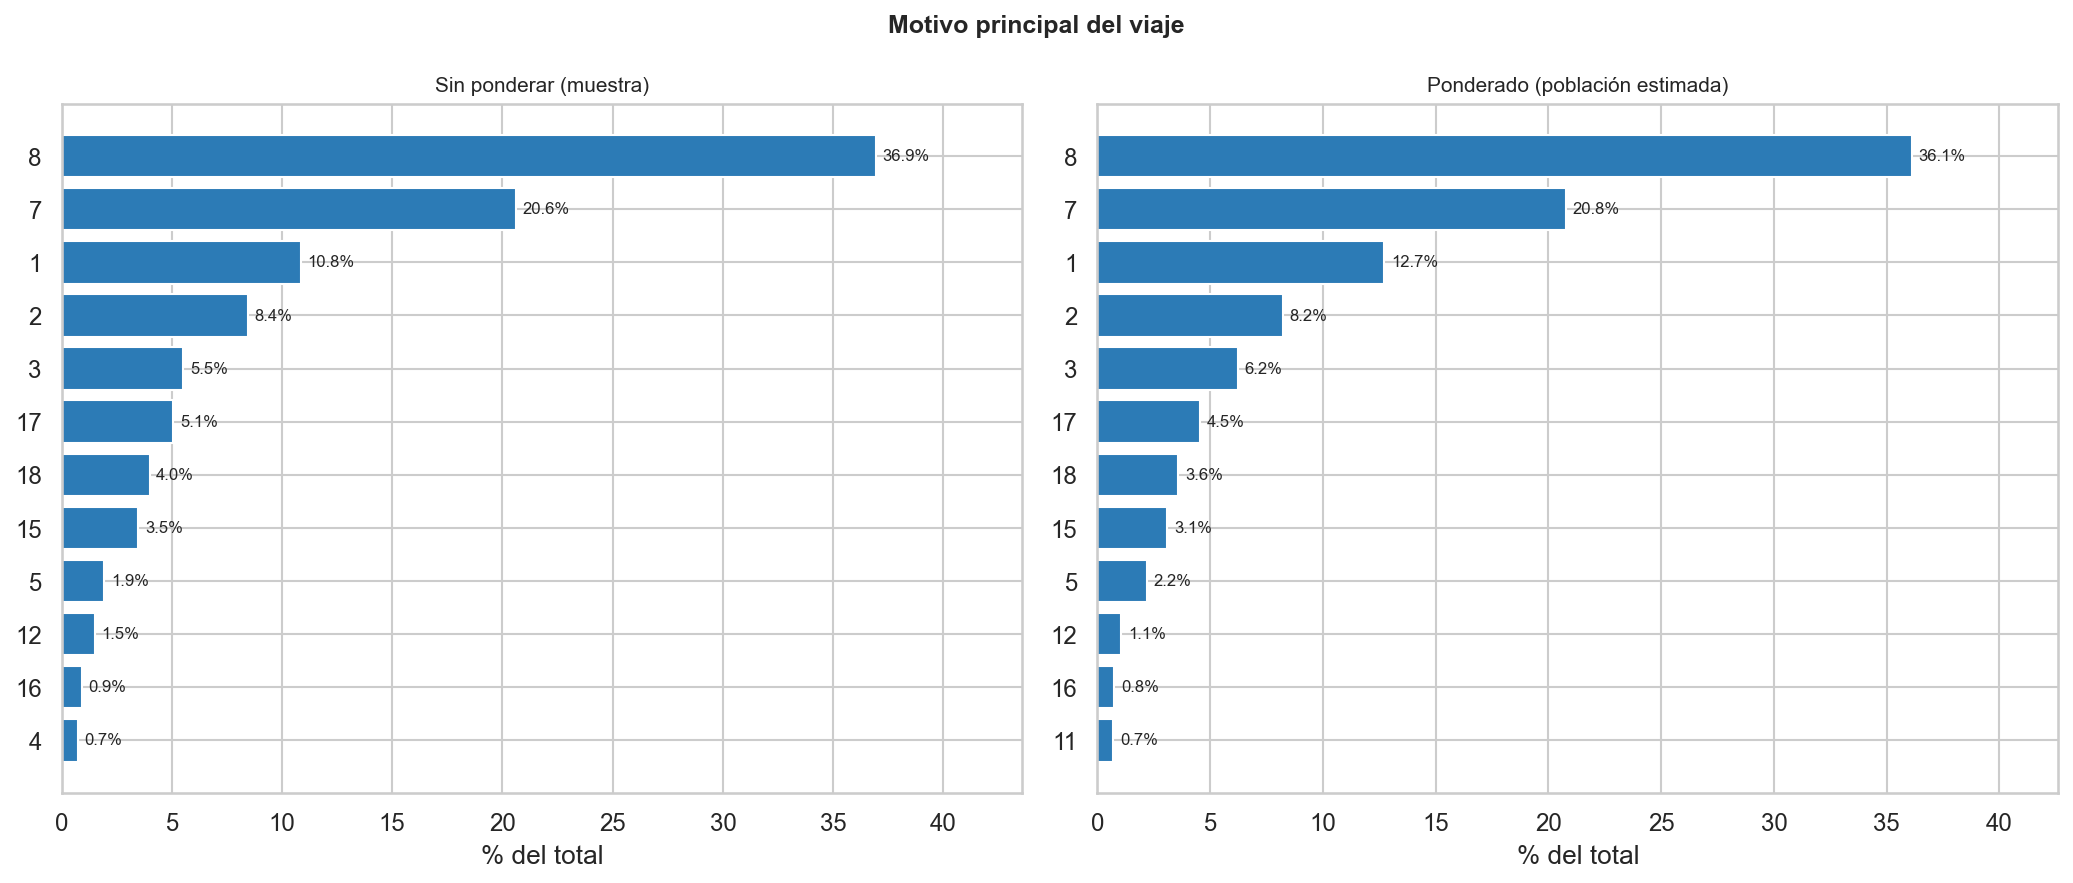

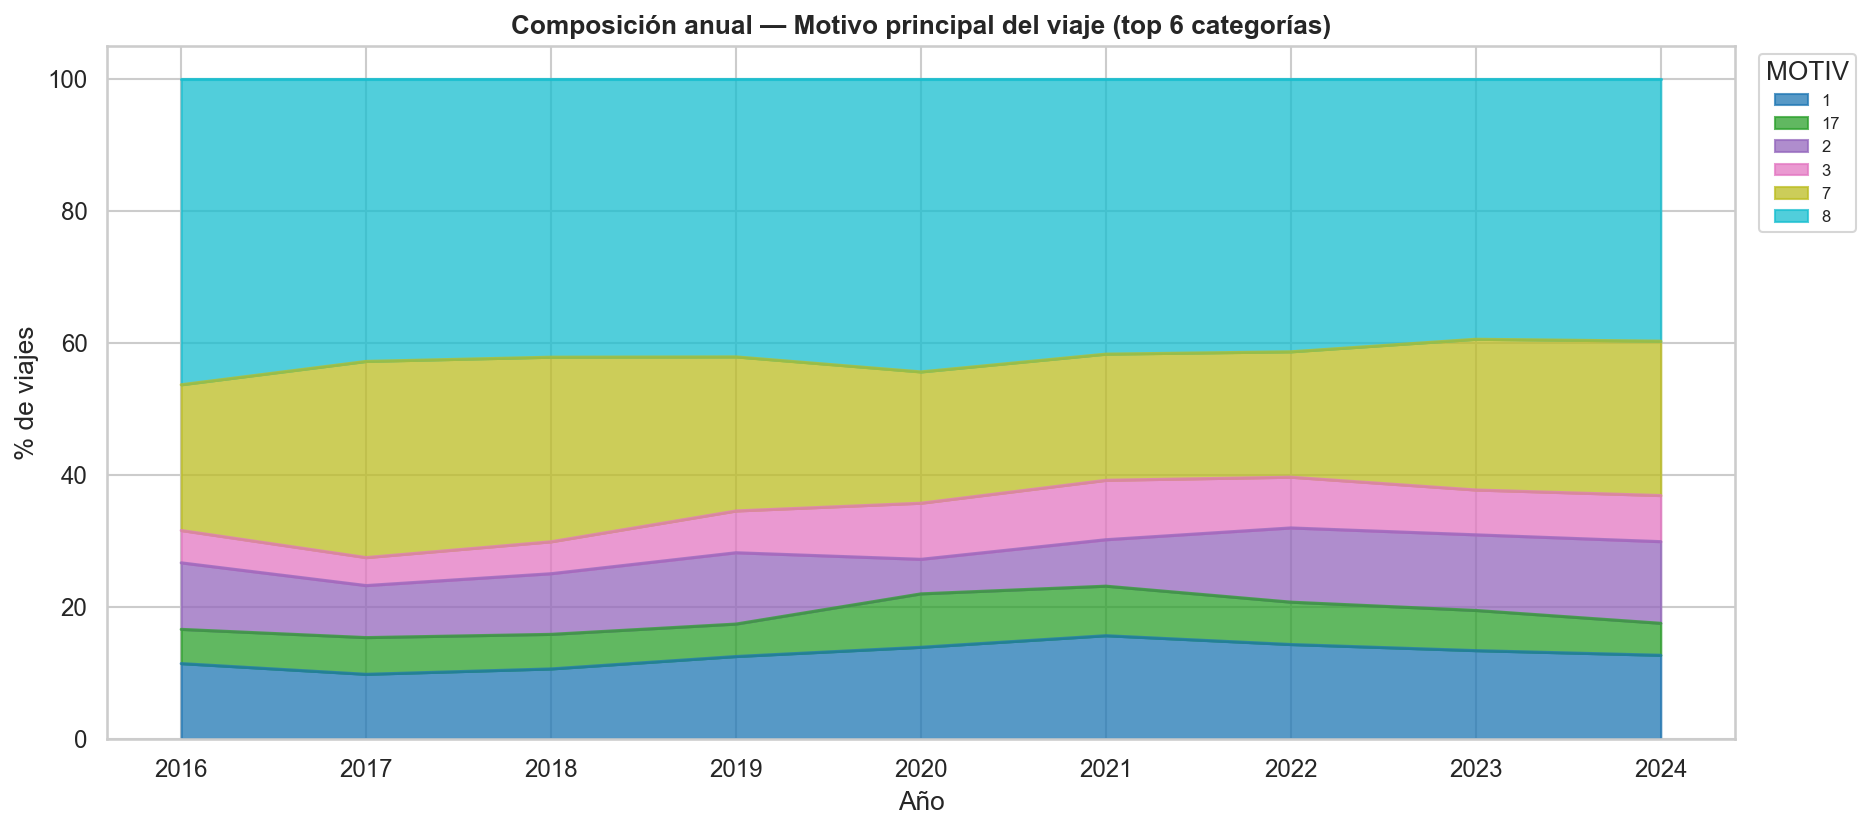

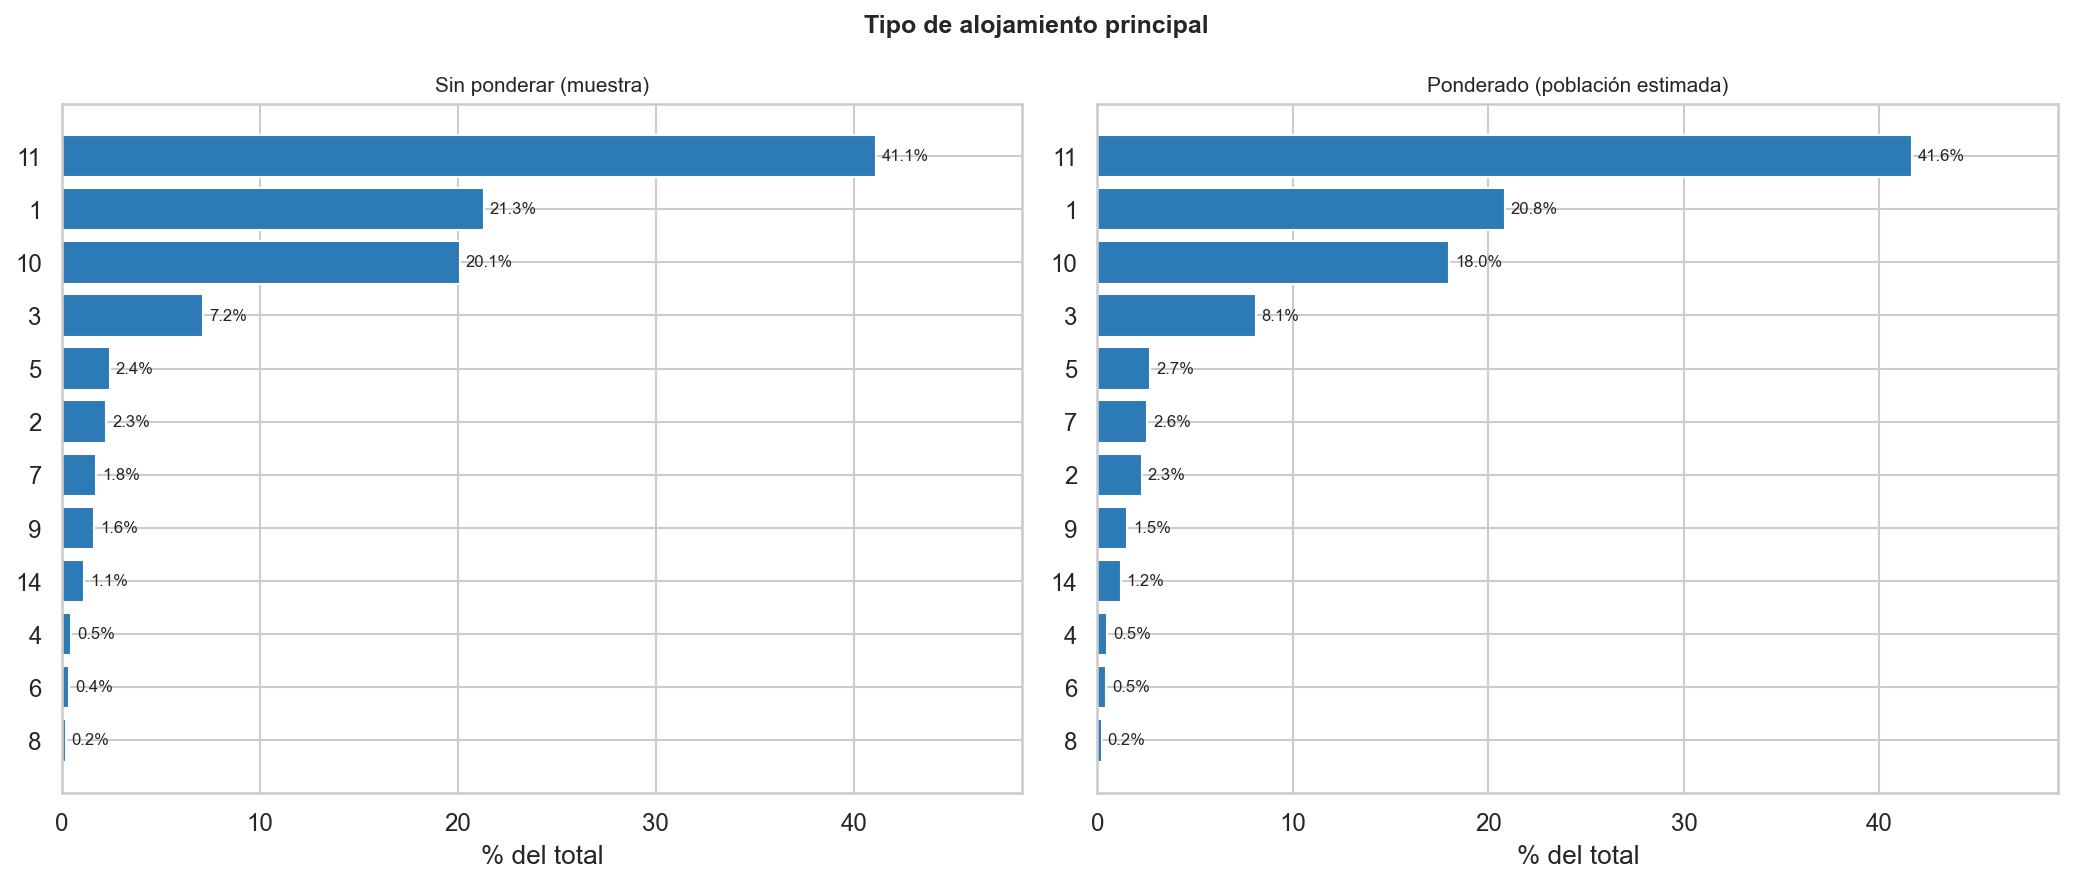

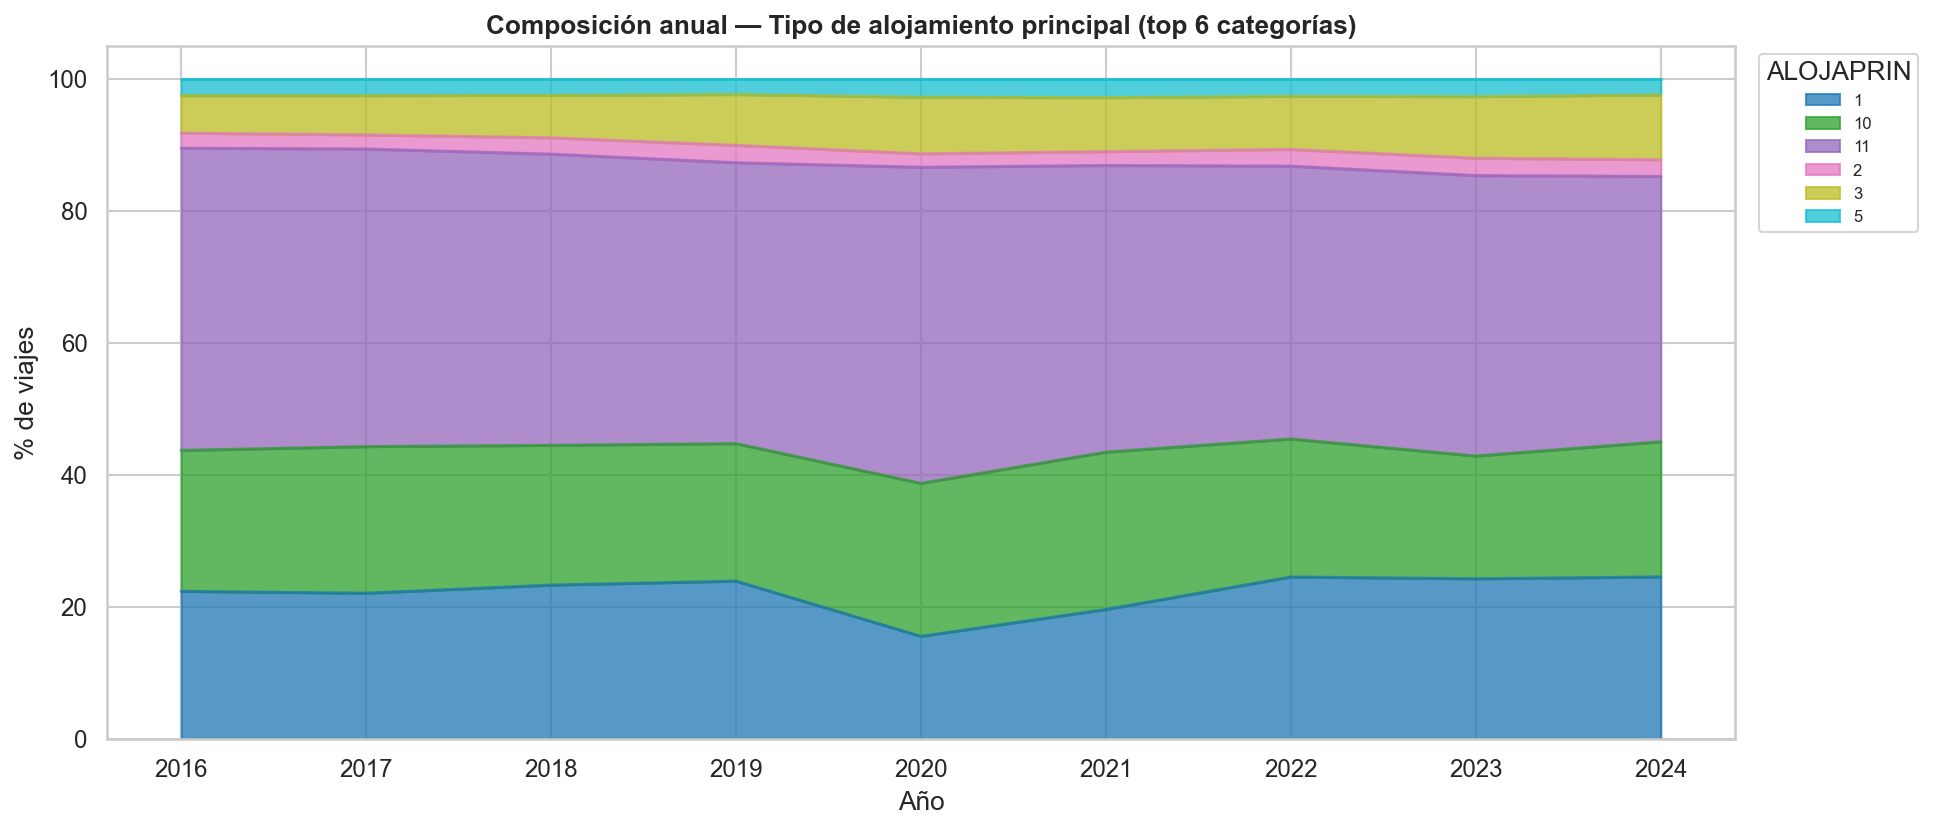

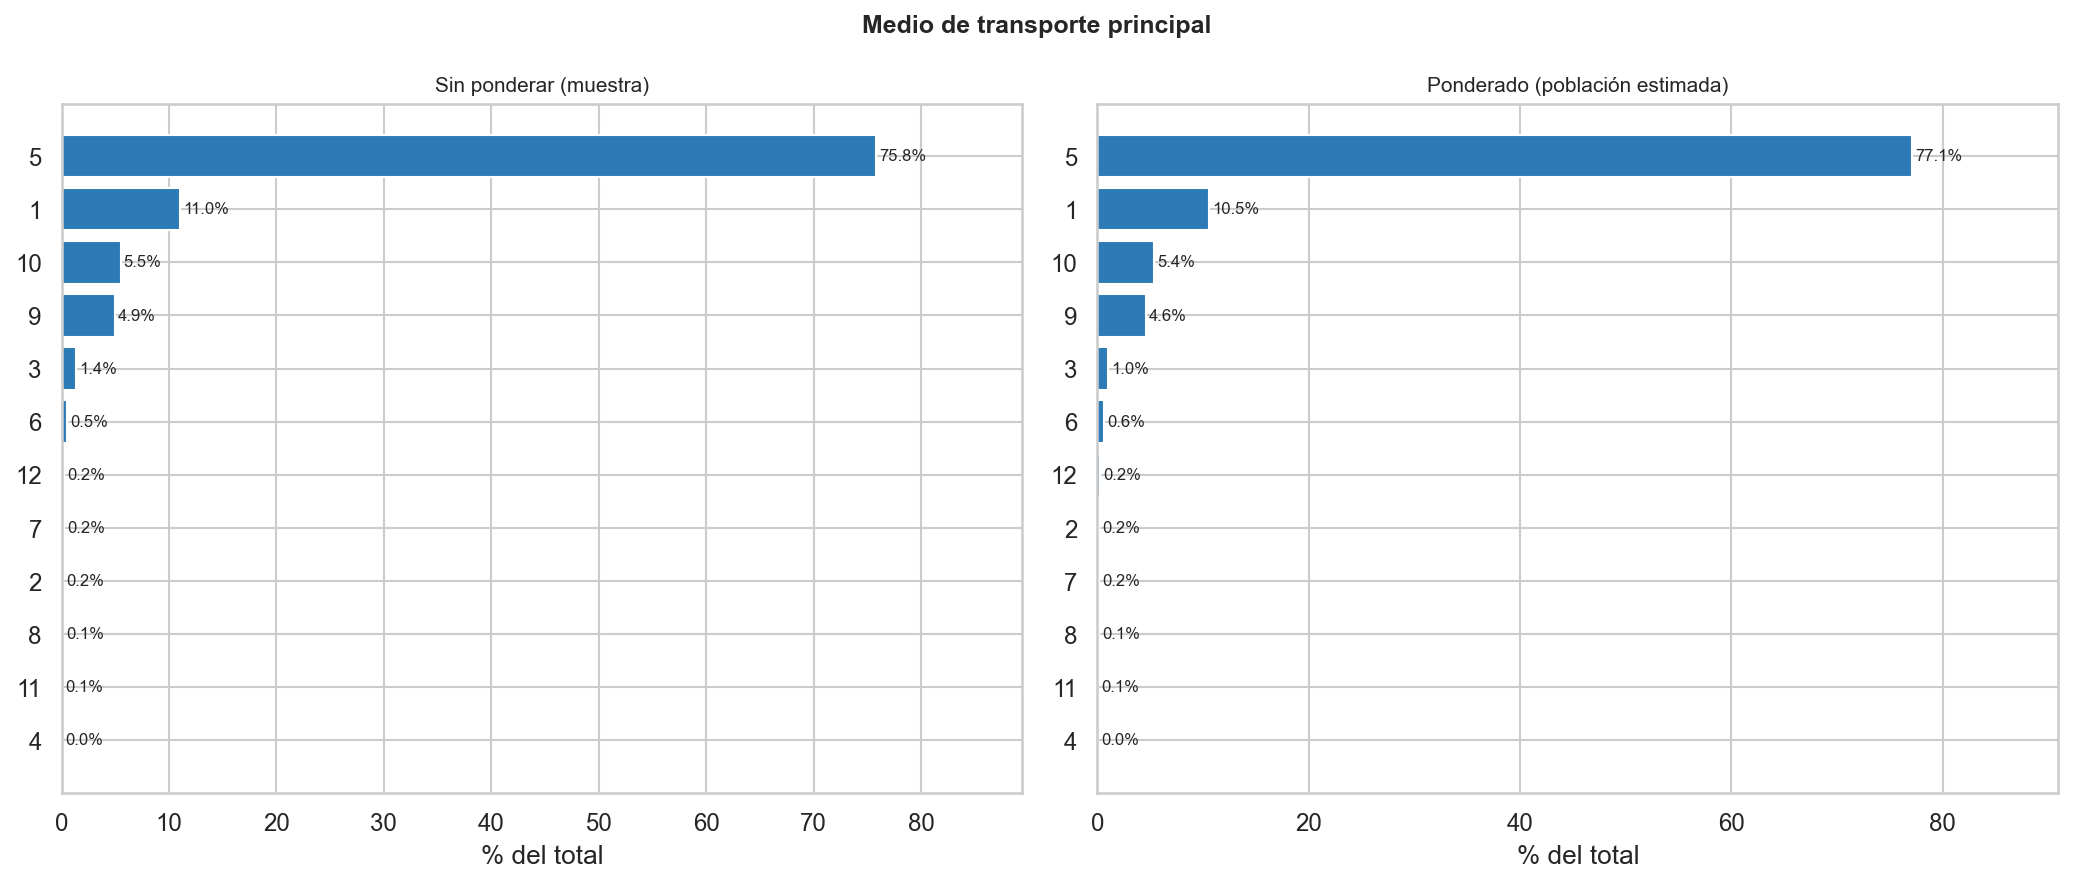

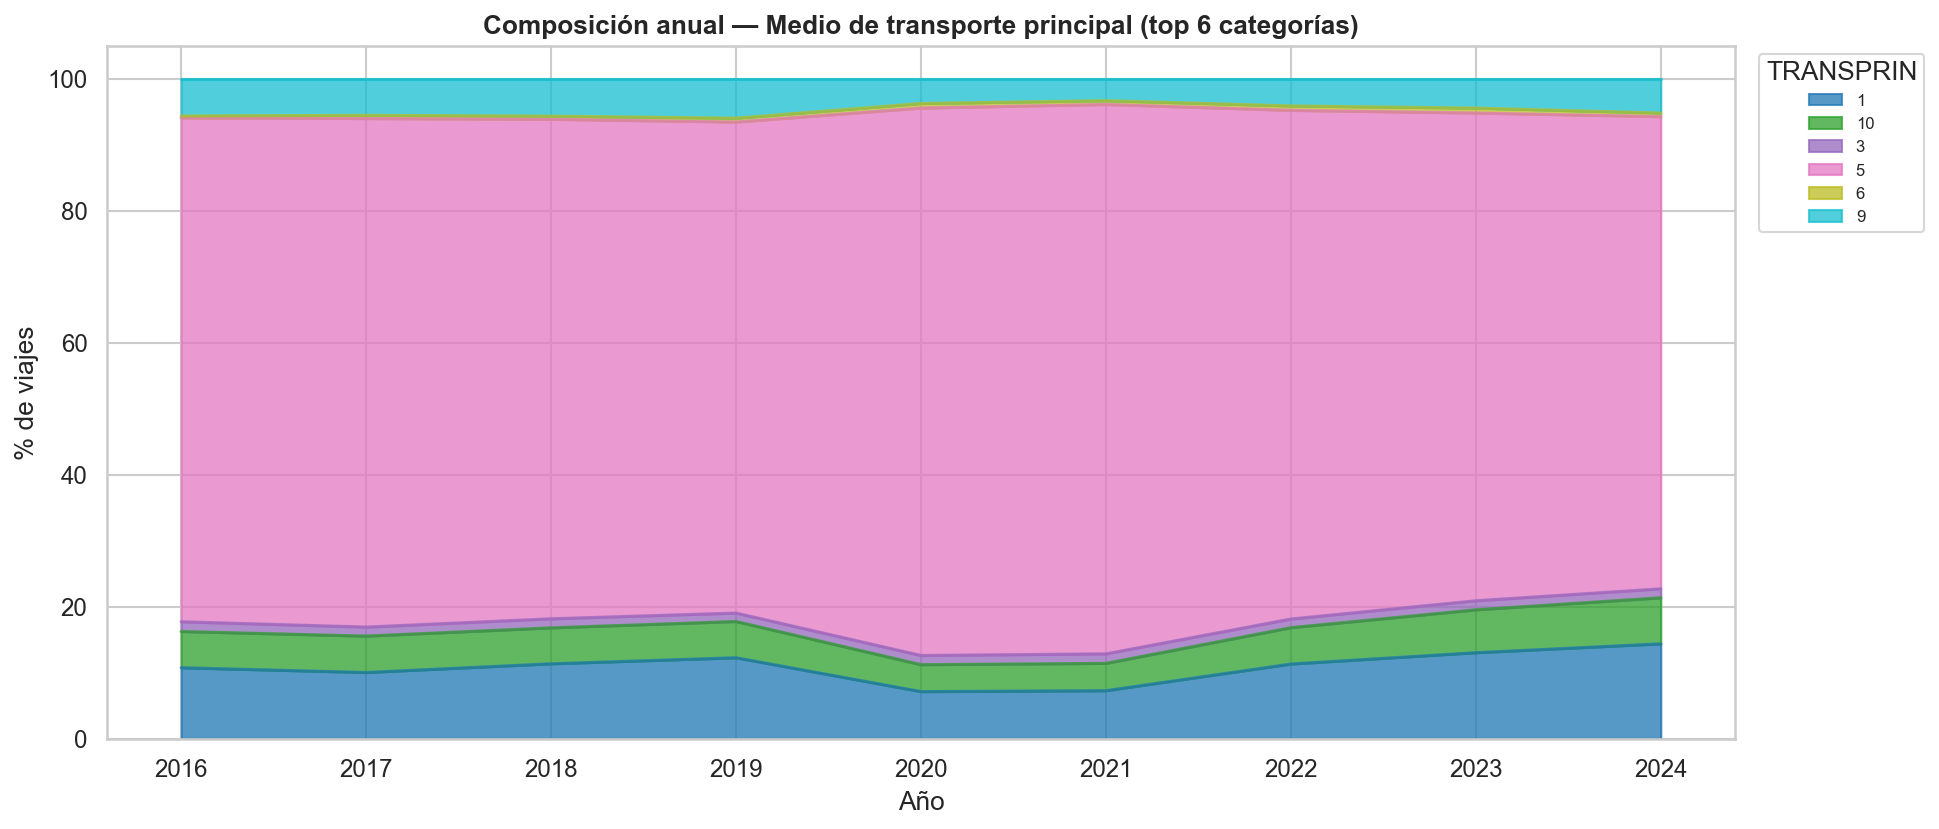

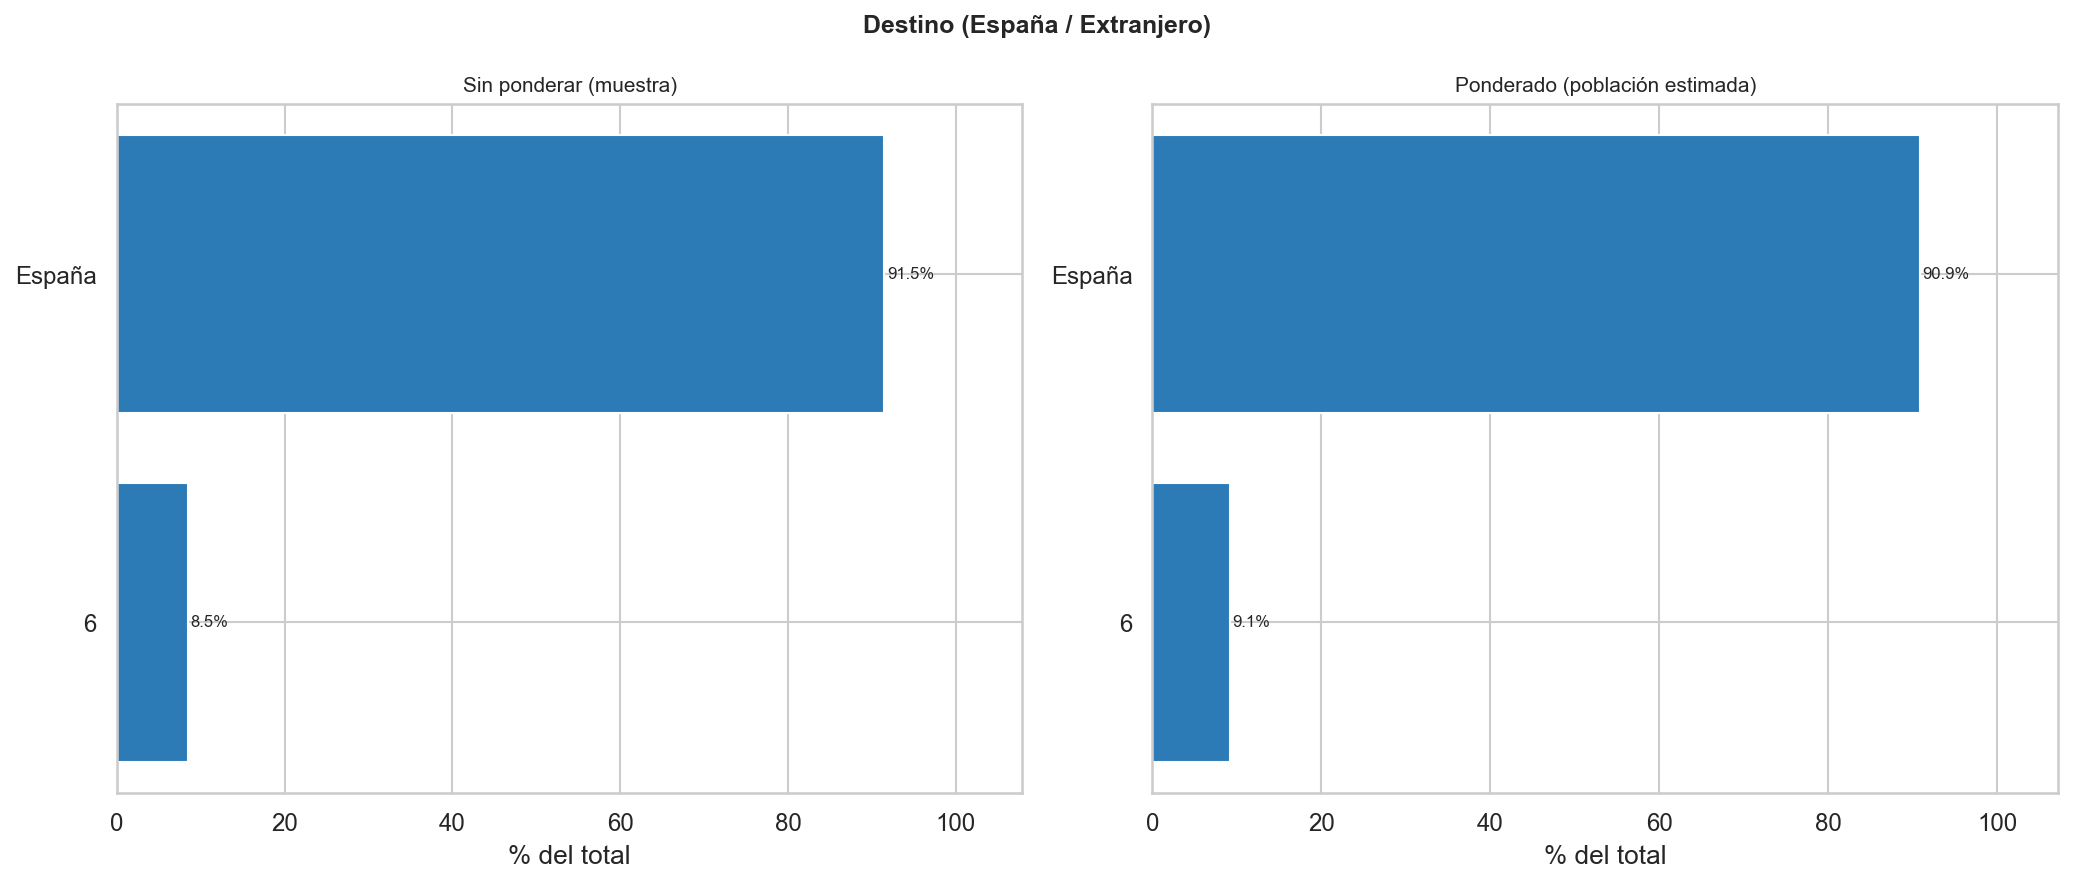

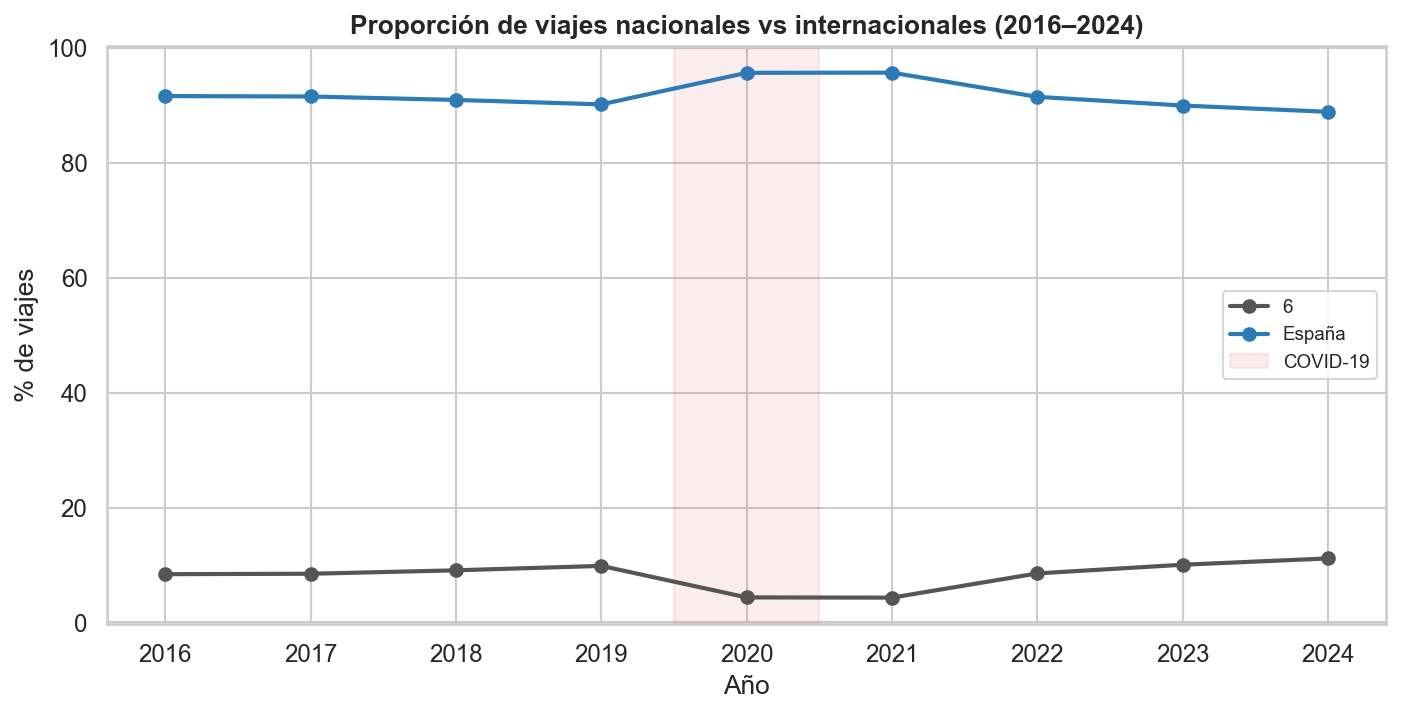

In [35]:
VARS_CAT = {
    VAR_MOTIVO: "Motivo principal del viaje",
    VAR_ALOJAMIENTO: "Tipo de alojamiento principal",
    VAR_TRANSPORTE: "Medio de transporte principal",
    VAR_DESTINO: "Destino (España / Extranjero)",
}

for col, titulo in VARS_CAT.items():
    if col not in base.columns:
        print(f"   Variable {col} no encontrada, se omite.")
        continue

    df_cat = base.copy()

    if col == VAR_DESTINO:
        df_cat[col] = df_cat[col].apply(etiqueta_destino)

    freq_sin = frecuencias_cat(df_cat, col, top_n=12)
    freq_con = frecuencias_cat(df_cat, col, peso=PESO_VIAJES, top_n=12)

    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

    for ax, df_plot, pct_col, subtitulo in [
        (axes[0], freq_sin, "pct", "Sin ponderar (muestra)"),
        (axes[1], freq_con, "pct_pond", "Ponderado (población estimada)"),
    ]:
        vals = df_plot[col].astype(str)
        pcts = df_plot[pct_col]

        bars = ax.barh(vals[::-1], pcts[::-1], color=COLOR_BASE, edgecolor="white")
        for bar, pct in zip(bars, pcts[::-1]):
            ax.text(
                bar.get_width() + 0.3,
                bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%",
                va="center",
                fontsize=8
            )

        ax.set_xlabel("% del total")
        ax.set_title(subtitulo, fontsize=10)
        ax.set_xlim(0, pcts.max() * 1.18 if len(pcts) > 0 else 1)

    fig.suptitle(titulo, fontweight="bold", fontsize=12)
    plt.tight_layout()
    

    # Composición anual para top categorías
    if col != VAR_DESTINO:
        top_cats = base[col].value_counts().head(6).index.tolist()
        sub_cat = base[base[col].isin(top_cats)].copy()
        sub_cat[col] = sub_cat[col].astype(str)

        pivot_cat = (
            sub_cat.groupby([VAR_ANYO, col])
            .size()
            .unstack(fill_value=0)
        )
        pivot_cat = pivot_cat.div(pivot_cat.sum(axis=1), axis=0) * 100

        fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
        pivot_cat.plot(kind="area", stacked=True, ax=ax, colormap="tab10", alpha=0.75)
        ax.set_xlabel("Año")
        ax.set_ylabel("% de viajes")
        ax.set_title(f"Composición anual — {titulo} (top 6 categorías)", fontweight="bold")
        ax.legend(title=col, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
  

# Destino España vs Extranjero a lo largo del tiempo
if VAR_DESTINO in base.columns:
    base_dest = base.copy()
    base_dest[VAR_DESTINO] = base_dest[VAR_DESTINO].apply(etiqueta_destino)

    dest_anyo = (
        base_dest.groupby([VAR_ANYO, VAR_DESTINO])
        .size()
        .unstack(fill_value=0)
    )
    dest_anyo = dest_anyo.div(dest_anyo.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=FIGSIZE_STD)
    colores = {
        "España": COLOR_BASE,
        "Extranjero": COLOR_ACCENT
    }

    for col_d in dest_anyo.columns:
        ax.plot(
            dest_anyo.index,
            dest_anyo[col_d],
            "o-",
            label=str(col_d),
            color=colores.get(col_d, "#555555"),
            linewidth=2
        )

    ax.axvspan(2019.5, 2020.5, color=COLOR_ACCENT, alpha=0.08, label="COVID-19")
    ax.set_xlabel("Año")
    ax.set_ylabel("% de viajes")
    ax.set_title("Proporción de viajes nacionales vs internacionales (2016–2024)", fontweight="bold")
    ax.legend(fontsize=9)

7. Análisis combinado: gasto y duración por categorías

C:\Users\jimena\AppData\Local\Temp\ipykernel_10024\2535284818.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\jimena\AppData\Local\Temp\ipykernel_10024\2535284818.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\jimena\AppData\Local\Temp\ipykernel_10024\2535284818.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\jimena\AppData\Local\Temp\ipykernel_10024\2535284818.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

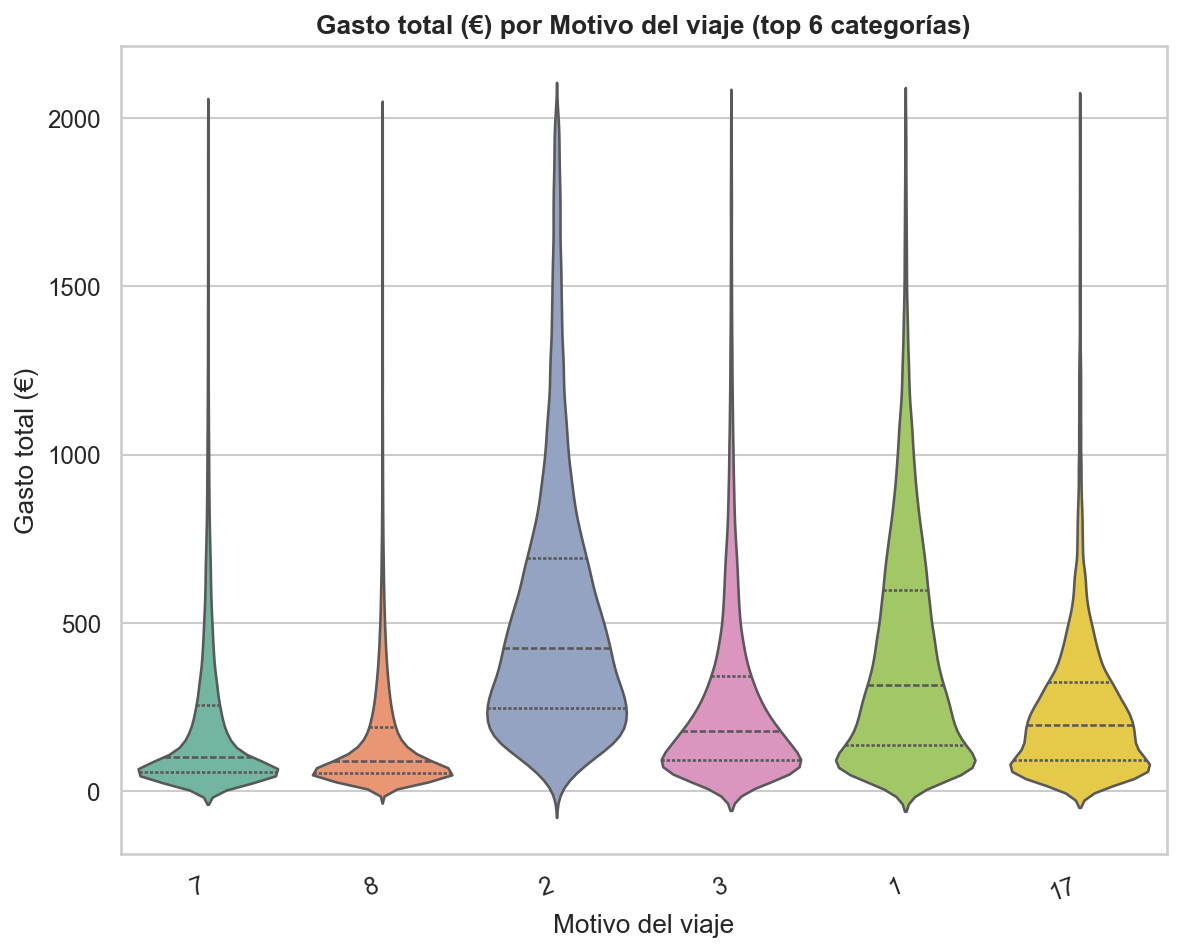

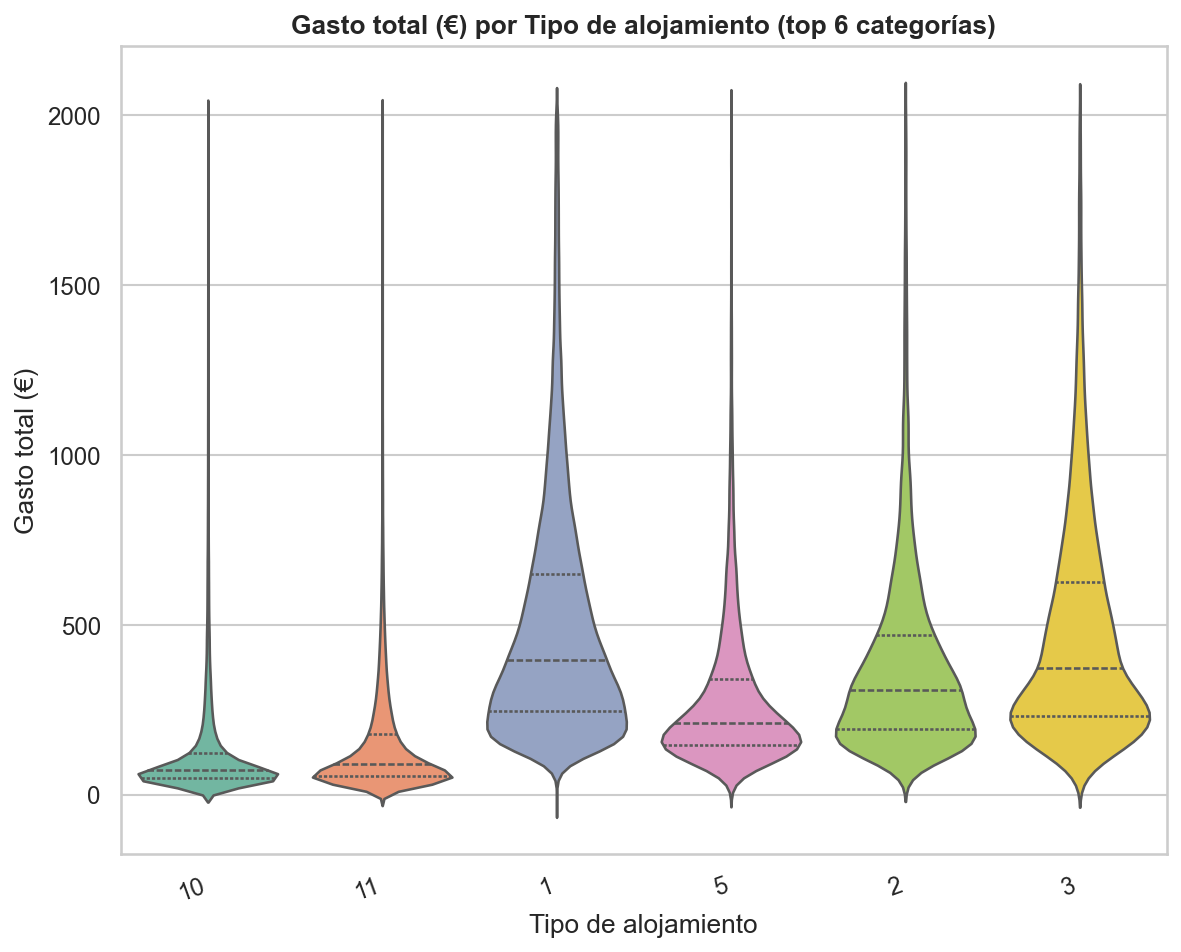

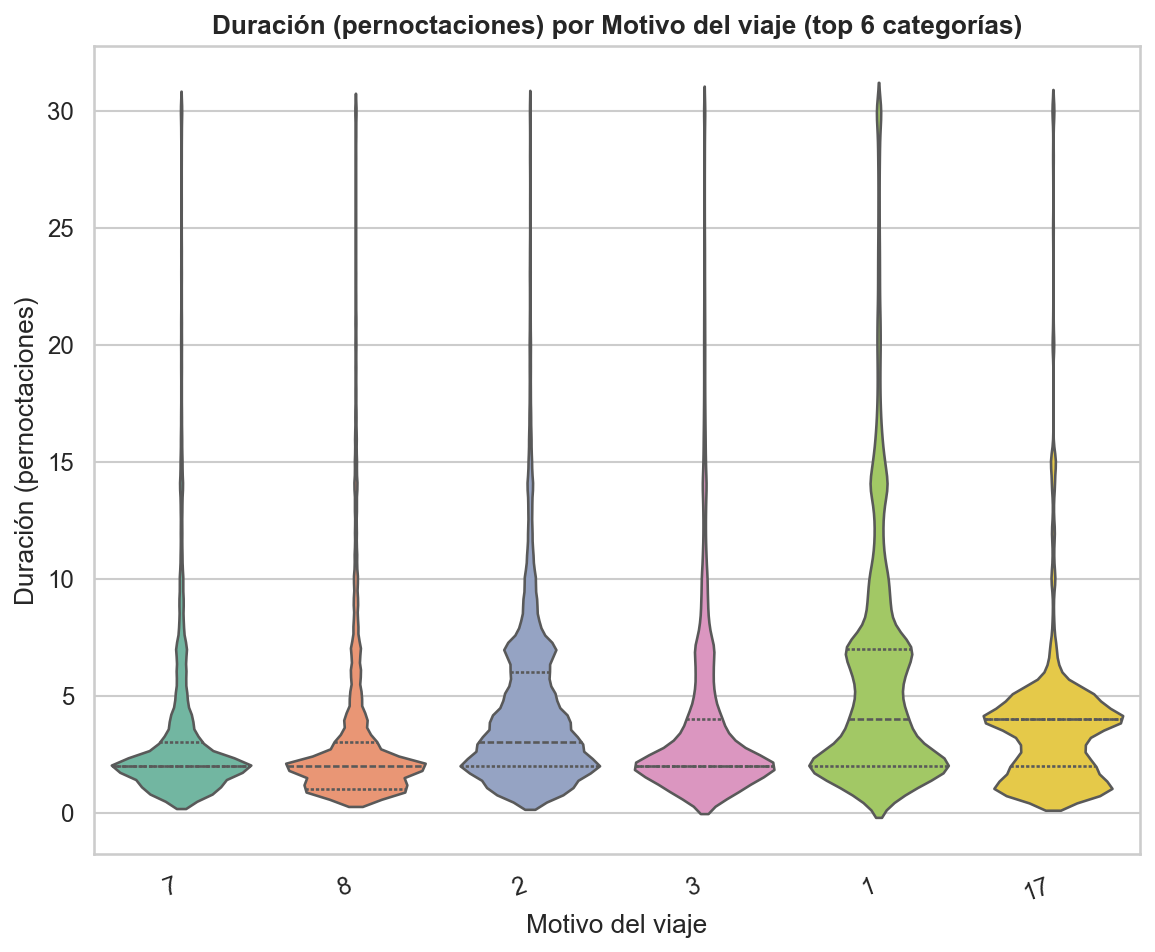

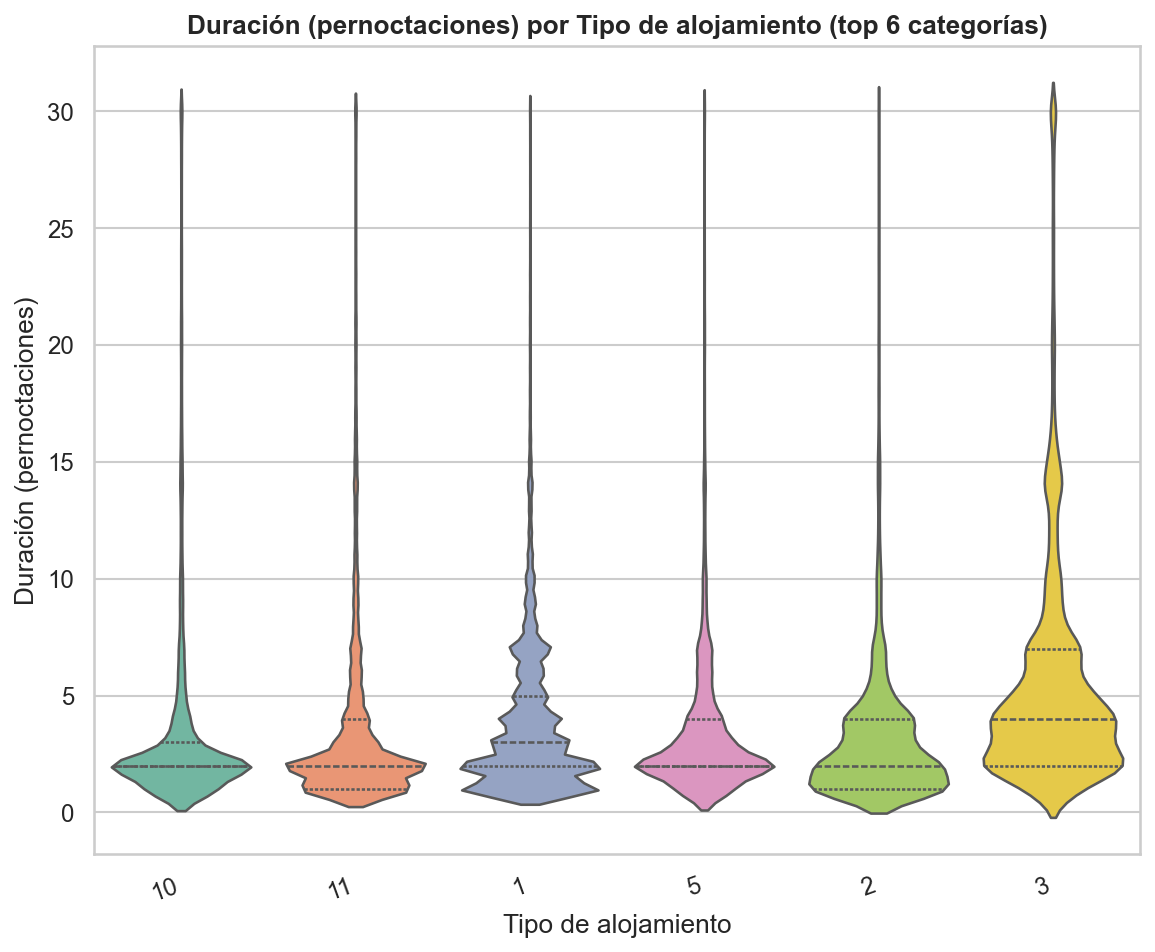

In [36]:
for var_num, label_num, fname_num in [
    (VAR_GASTO, "Gasto total (€)", "gasto"),
    (VAR_DURACION, "Duración (pernoctaciones)", "duracion"),
]:
    if var_num not in base.columns:
        continue

    if base[var_num].dropna().empty:
        continue

    p99 = base[var_num].quantile(0.99)

    for col_cat, titulo_cat in [
        (VAR_MOTIVO, "Motivo del viaje"),
        (VAR_ALOJAMIENTO, "Tipo de alojamiento"),
    ]:
        if col_cat not in base.columns:
            continue

        top_cats = base[col_cat].value_counts().head(6).index
        sub = base[base[col_cat].isin(top_cats) & base[var_num].notna()].copy()
        sub = sub[sub[var_num] <= p99]
        sub[col_cat] = sub[col_cat].astype(str)

        fig, ax = plt.subplots(figsize=FIGSIZE_SQ)
        sns.violinplot(
            data=sub,
            x=col_cat,
            y=var_num,
            palette="Set2",
            inner="quartile",
            ax=ax
        )
        ax.set_xlabel(titulo_cat)
        ax.set_ylabel(label_num)
        ax.set_title(f"{label_num} por {titulo_cat} (top 6 categorías)", fontweight="bold")
        plt.xticks(rotation=20, ha="right")

8. Análisis de valores perdidos

   Variables con >90% NA (probablemente condicionadas a paquete):
PPAL_TRANSP_PAQ    97.018915
ANT_PAQ            96.452419
RESERV_PAQ         96.452419
PPAL_ALOJA_PAQ     96.432641
PAQ_ACT            96.338467
PAQ_TRANSP         96.338467
PAQ_ALOJA          96.338467
PAQ_COMBEB         96.338467
AVE                94.503437
PAGO_ALOJA         92.207698
PAGO_MANUT         90.207908
PAGO_TRANS         90.207908


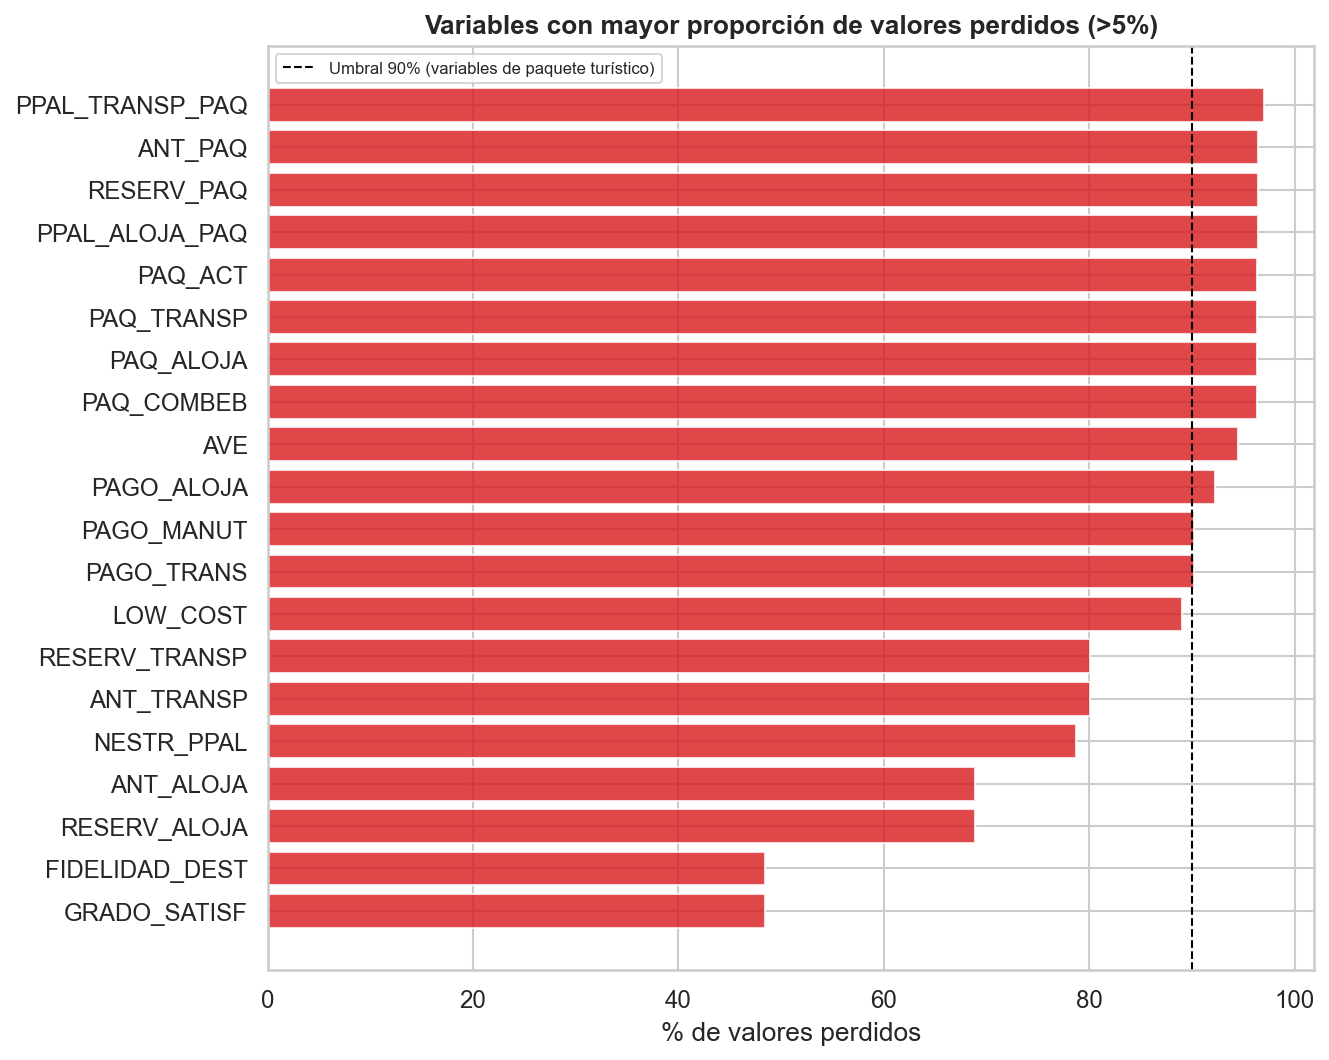

In [37]:
na_pct = (base.isna().mean() * 100).sort_values(ascending=False)
na_alta = na_pct[na_pct > 5].head(20)

if len(na_alta) > 0:
    fig, ax = plt.subplots(figsize=(9, max(4, len(na_alta) * 0.4)))
    ax.barh(na_alta.index[::-1], na_alta.values[::-1], color=COLOR_ACCENT, alpha=0.8)
    ax.axvline(90, color="black", linewidth=1, linestyle="--", label="Umbral 90% (variables de paquete turístico)")
    ax.set_xlabel("% de valores perdidos")
    ax.set_title("Variables con mayor proporción de valores perdidos (>5%)", fontweight="bold")
    ax.legend(fontsize=8)

    print("   Variables con >90% NA (probablemente condicionadas a paquete):")
    print(na_pct[na_pct > 90].to_string())

9. Correlaciones entre variables numéricas clave

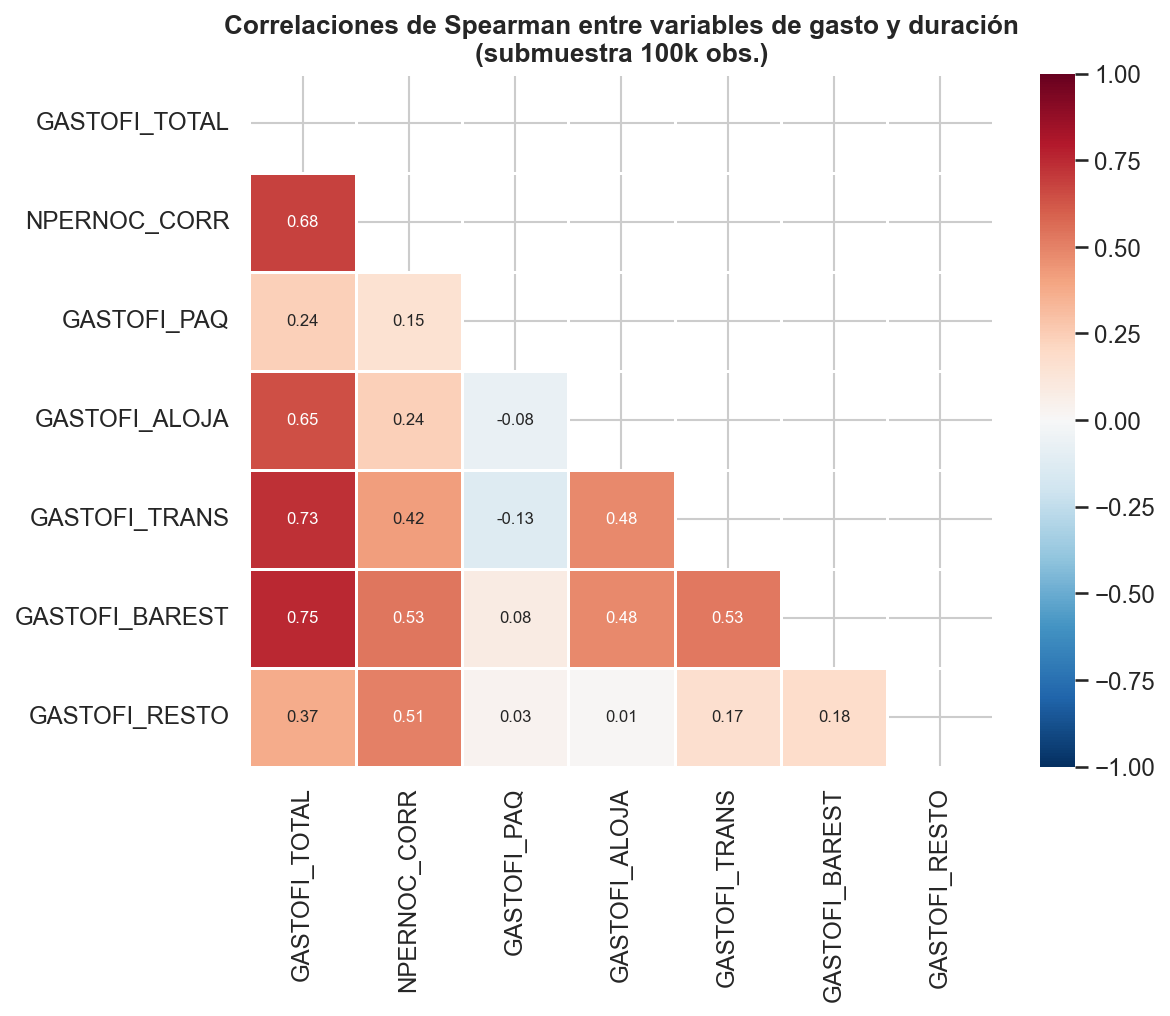

In [38]:
vars_corr_candidatas = [
    VAR_GASTO, VAR_DURACION,
    "GASTOFI_PAQ", "GASTOFI_ALOJA", "GASTOFI_TRANS",
    "GASTOFI_BAREST", "GASTOFI_RESTO",
]

# Convertimos estas columnas a numérico por seguridad
for col in vars_corr_candidatas:
    if col in muestra.columns:
        muestra[col] = pd.to_numeric(muestra[col], errors="coerce")

VARS_CORR = [v for v in vars_corr_candidatas if v in muestra.columns]

if len(VARS_CORR) >= 3:
    corr_matrix = muestra[VARS_CORR].corr(method="spearman")

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        annot_kws={"fontsize": 8},
        ax=ax
    )
    ax.set_title(
        "Correlaciones de Spearman entre variables de gasto y duración\n(submuestra 100k obs.)",
        fontweight="bold"
    )

In [39]:
print(base[VAR_GASTO].head(20))
print(base[VAR_GASTO].describe())

0       35.79
1       35.79
2      592.67
3       12.67
4       12.67
5       12.67
6       12.67
7       12.67
8     1165.38
9       54.96
10      54.96
11      35.07
12      35.07
13      57.09
14      41.27
15      41.27
16      41.27
17      41.27
18      41.27
19      47.43
Name: GASTOFI_TOTAL, dtype: float64
count    551108.000000
mean        288.207837
std         474.476695
min           0.000000
25%          67.740000
50%         151.380000
75%         348.500000
max      120697.880000
Name: GASTOFI_TOTAL, dtype: float64


# FAMD + UMAP

Configuración

In [40]:
!pip install umap-learn


[notice] A new release of pip available: 22.2.2 -> 26.1.1
[notice] To update, run: C:\Users\jimena\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [41]:
import sys
!{sys.executable} -m pip install prince

In [42]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.impute import SimpleImputer
import prince

In [43]:
RANDOM_STATE = 42
N_SAMPLE     = 100_000
TOP_N_CATS   = 12

OUTPUT_DIR = r"C:\Users\jimena\OneDrive\Documentos\4 CARRERA\TFG\figuras_famd"
os.makedirs(OUTPUT_DIR, exist_ok=True)


COL_ANYO    = "ANYO"
COL_MES     = "MES"
COL_GASTO   = "GASTOFI_TOTAL"
COL_DUR     = "NPERNOC_CORR"
COL_MOTIVO  = "MOTIV"
COL_ALOJ    = "ALOJAPRIN"
COL_TRANS   = "TRANSPRIN"
COL_DEST    = "DESTESP"
COL_PAQ     = "PAQUETE"      
COL_PESO    = "FACTORVI_TOT"

1. Creación de la copia para no trabajar directamente con la base

In [44]:

df = base.copy()

cols_requeridas = [COL_ANYO, COL_MES, COL_GASTO, COL_DUR,
                   COL_MOTIVO, COL_ALOJ, COL_TRANS, COL_DEST]
cols_faltantes = [c for c in cols_requeridas if c not in df.columns]
if cols_faltantes:
    raise ValueError(
        f"Las siguientes columnas no se encontraron en la base:\n{cols_faltantes}\n"
        f"Revisa los nombres en el bloque de CONFIGURACIÓN."
    )

col_paq  = COL_PAQ  if COL_PAQ  in df.columns else None
col_peso = COL_PESO if COL_PESO in df.columns else None

print("✓ Columnas verificadas.")
if col_paq  is None: print("  ⚠ PAQUETE no encontrada — se omitirá del modelo.")
if col_peso is None: print("  ⚠ FACTORVI_TOT no encontrada — muestreo aleatorio simple.")

✓ Columnas verificadas.


2. Selección de variables

In [45]:
vars_num = [COL_GASTO, COL_DUR]
vars_cat = [COL_ANYO, COL_MES, COL_MOTIVO, COL_ALOJ, COL_TRANS, COL_DEST]
if col_paq:
    vars_cat.append(col_paq)

variables_modelo = vars_num + vars_cat
print(f"\nVariables para FAMD: {variables_modelo}")

df_rd = df[variables_modelo].copy()


Variables para FAMD: ['GASTOFI_TOTAL', 'NPERNOC_CORR', 'ANYO', 'MES', 'MOTIV', 'ALOJAPRIN', 'TRANSPRIN', 'DESTESP', 'PAQUETE']


3. Filtros básicos

In [46]:
n_antes = len(df_rd)

df_rd = df_rd[df_rd[COL_DUR].notna() & (df_rd[COL_DUR] >= 1)]
print(f"\nFiltro duración ≥1: {n_antes - len(df_rd):,} filas eliminadas "
      f"({len(df_rd):,} restantes)")

n_antes = len(df_rd)

df_rd = df_rd[df_rd[COL_GASTO].isna() | (df_rd[COL_GASTO] >= 0)]
print(f"Filtro gasto ≥0:    {n_antes - len(df_rd):,} filas eliminadas "
      f"({len(df_rd):,} restantes)")


Filtro duración ≥1: 0 filas eliminadas (551,108 restantes)
Filtro gasto ≥0:    0 filas eliminadas (551,108 restantes)


4. Transformación log antes de imputar

In [47]:
df_rd[COL_GASTO] = np.log1p(df_rd[COL_GASTO])

5. Imputación

In [48]:
imp_num = SimpleImputer(strategy="median")
df_rd[vars_num] = imp_num.fit_transform(df_rd[vars_num])

imp_cat = SimpleImputer(strategy="most_frequent")
df_rd[vars_cat] = imp_cat.fit_transform(df_rd[vars_cat])

6. Submuestra

In [49]:
if len(df_rd) > N_SAMPLE:
    df_rd = df_rd.sample(N_SAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"\nSubmuestra aleatoria simple: {len(df_rd):,} obs.")
else:
    df_rd = df_rd.reset_index(drop=True)
    print(f"\nNo se extrae submuestra: {len(df_rd):,} obs.")


Submuestra aleatoria simple: 100,000 obs.


7. Agrupación de categorías raras

In [50]:
def agrupar_raras(s, top_n=TOP_N_CATS):
    """
    Agrupa en 'Otros' las categorías que no están entre las top_n más frecuentes.
    Los NaN se convierten en 'Missing'.
    """
    s = s.astype("object").fillna("Missing")
    top = s.value_counts(dropna=False).head(top_n).index
    s_agrupada = np.where(s.isin(top), s.astype(str), "Otros")
    return pd.Series(s_agrupada, index=s.index)

for c in vars_cat:
    df_rd[c] = agrupar_raras(df_rd[c], top_n=TOP_N_CATS)
    df_rd[c] = df_rd[c].astype("category")

print("\nResumen de categorías tras la agrupación:")
for c in vars_cat:
    n_cat = df_rd[c].nunique(dropna=False)
    print(f"\n{c}: {n_cat} categorías finales")
    print(df_rd[c].value_counts(dropna=False).head(15).to_string())


Resumen de categorías tras la agrupación:

ANYO: 9 categorías finales
ANYO
2018.0    13612
2017.0    13527
2019.0    12744
2016.0    12566
2024.0    11057
2023.0    10793
2022.0     9955
2021.0     9304
2020.0     6442

MES: 12 categorías finales
MES
8.0     13084
7.0     10747
9.0      9141
6.0      8332
10.0     7941
4.0      7916
5.0      7562
12.0     7513
1.0      7326
3.0      6988
2.0      6779
11.0     6671

MOTIV: 13 categorías finales
MOTIV
8.0      36351
7.0      20233
1.0      10575
2.0       8294
3.0       5583
17.0      4856
18.0      3888
15.0      3345
5.0       1888
Otros     1831
12.0      1515
16.0       887
4.0        754

ALOJAPRIN: 13 categorías finales
ALOJAPRIN
11.0     41003
1.0      21213
10.0     20019
3.0       7134
5.0       2472
2.0       2255
7.0       1816
9.0       1715
14.0      1183
4.0        443
6.0        423
8.0        211
Otros      113

TRANSPRIN: 12 categorías finales
TRANSPRIN
5.0     75834
1.0     10851
10.0     5554
9.0      4990
3.0      1

In [51]:
resumen_categorias = pd.DataFrame({
    "variable": vars_cat,
    "n_categorias_finales": [df_rd[c].nunique(dropna=False) for c in vars_cat]
})
print("\nNúmero de categorías finales por variable:")
print(resumen_categorias.to_string(index=False))


Número de categorías finales por variable:
 variable  n_categorias_finales
     ANYO                     9
      MES                    12
    MOTIV                    13
ALOJAPRIN                    13
TRANSPRIN                    12
  DESTESP                     2
  PAQUETE                     3


8. FAMD

In [52]:
n_comp = 10

famd = prince.FAMD(
    n_components=n_comp,
    n_iter=10,          
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=RANDOM_STATE,
)
famd.fit(df_rd)

coords_famd = famd.row_coordinates(df_rd).copy()
coords_famd.columns = [f"Dim{i+1}" for i in range(coords_famd.shape[1])]

# Varianza explicada
eig = np.array(famd.eigenvalues_, dtype=float)
var_exp  = eig / eig.sum()
var_acum = np.cumsum(var_exp)

print("\nResumen dimensiones FAMD:")
tabla_dim = pd.DataFrame({
    "Dimensión":       np.arange(1, len(eig) + 1),
    "Autovalor":       eig.round(4),
    "Var. explicada":  (var_exp * 100).round(2),
    "Var. acumulada":  (var_acum * 100).round(2),
})
print(tabla_dim.to_string(index=False))


Resumen dimensiones FAMD:
 Dimensión  Autovalor  Var. explicada  Var. acumulada
         1     8.9107           16.82           16.82
         2     6.5489           12.36           29.18
         3     5.7296           10.81           39.99
         4     5.4769           10.34           50.33
         5     5.0203            9.48           59.80
         6     4.5179            8.53           68.33
         7     4.4234            8.35           76.68
         8     4.2874            8.09           84.77
         9     4.1054            7.75           92.52
        10     3.9628            7.48          100.00


9. Screen plot

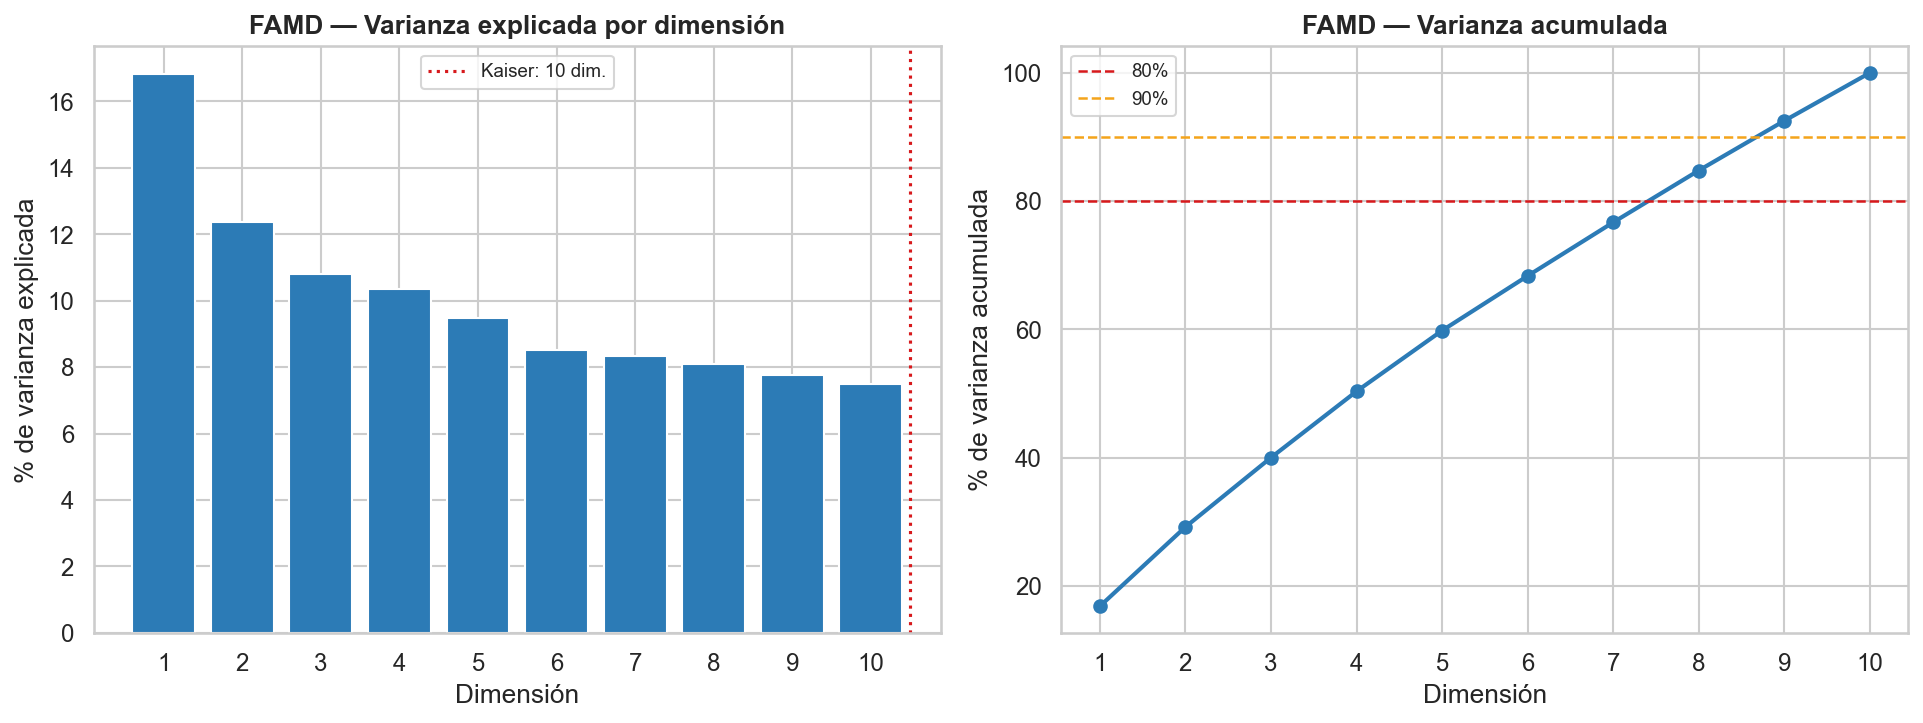

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: varianza explicada por dimensión
axes[0].bar(range(1, len(var_exp) + 1), var_exp * 100,
            color="#2c7bb6", edgecolor="white")
axes[0].set_xlabel("Dimensión")
axes[0].set_ylabel("% de varianza explicada")
axes[0].set_title("FAMD — Varianza explicada por dimensión", fontweight="bold")
axes[0].set_xticks(range(1, len(var_exp) + 1))

# Panel derecho: varianza acumulada con umbrales
axes[1].plot(range(1, len(var_acum) + 1), var_acum * 100,
             "o-", color="#2c7bb6", linewidth=2, markersize=6)
axes[1].axhline(80, color="#d7191c", linewidth=1.2, linestyle="--", label="80%")
axes[1].axhline(90, color="#f4a41b", linewidth=1.2, linestyle="--", label="90%")
axes[1].set_xlabel("Dimensión")
axes[1].set_ylabel("% de varianza acumulada")
axes[1].set_title("FAMD — Varianza acumulada", fontweight="bold")
axes[1].set_xticks(range(1, len(var_acum) + 1))
axes[1].legend(fontsize=9)

n_kaiser = (eig >= 1).sum()
axes[0].axvline(n_kaiser + 0.5, color="#d7191c", linewidth=1.5,
                linestyle=":", label=f"Kaiser: {n_kaiser} dim.")
axes[0].legend(fontsize=9)

plt.tight_layout()
ruta = os.path.join(OUTPUT_DIR, "fig_famd_screeplot.png")

plt.show()

10. Contribuciones de variables


Correlación de variables numéricas con las dimensiones FAMD:

Dim1:
GASTOFI_TOTAL    0.687
NPERNOC_CORR     0.151


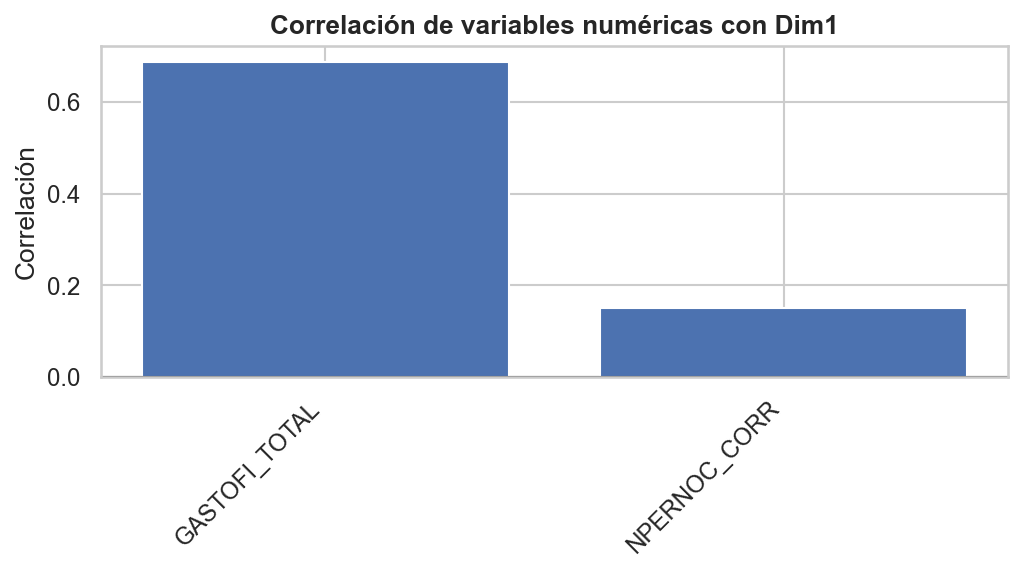


Dim2:
GASTOFI_TOTAL   -0.268
NPERNOC_CORR    -0.027


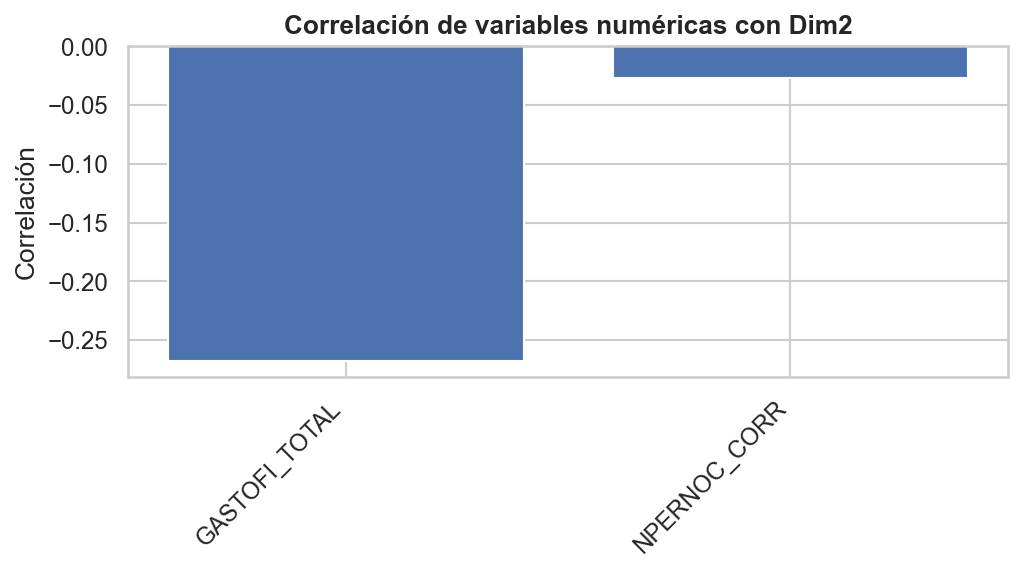



==================== Dim1 ====================

Variable categórica: ANYO
         mean  count
ANYO                
2020.0 -1.066   6442
2021.0 -0.715   9304
2024.0  0.605  11057
2023.0  0.468  10793
2019.0  0.249  12744
2017.0 -0.232  13527
2022.0  0.204   9955
2016.0 -0.039  12566
2018.0  0.015  13612


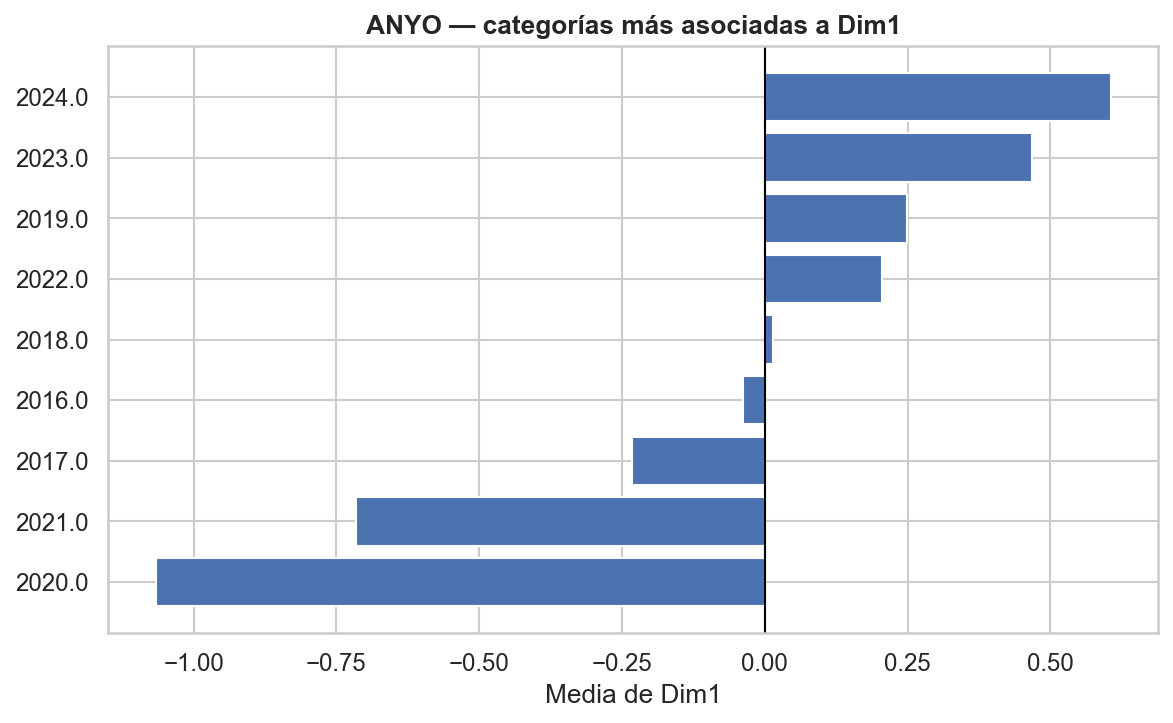


Variable categórica: MES
       mean  count
MES               
1.0  -0.589   7326
2.0  -0.259   6779
10.0  0.196   7941
4.0   0.182   7916
11.0  0.147   6671
8.0   0.142  13084
9.0   0.125   9141
12.0 -0.102   7513
5.0   0.049   7562
6.0  -0.037   8332


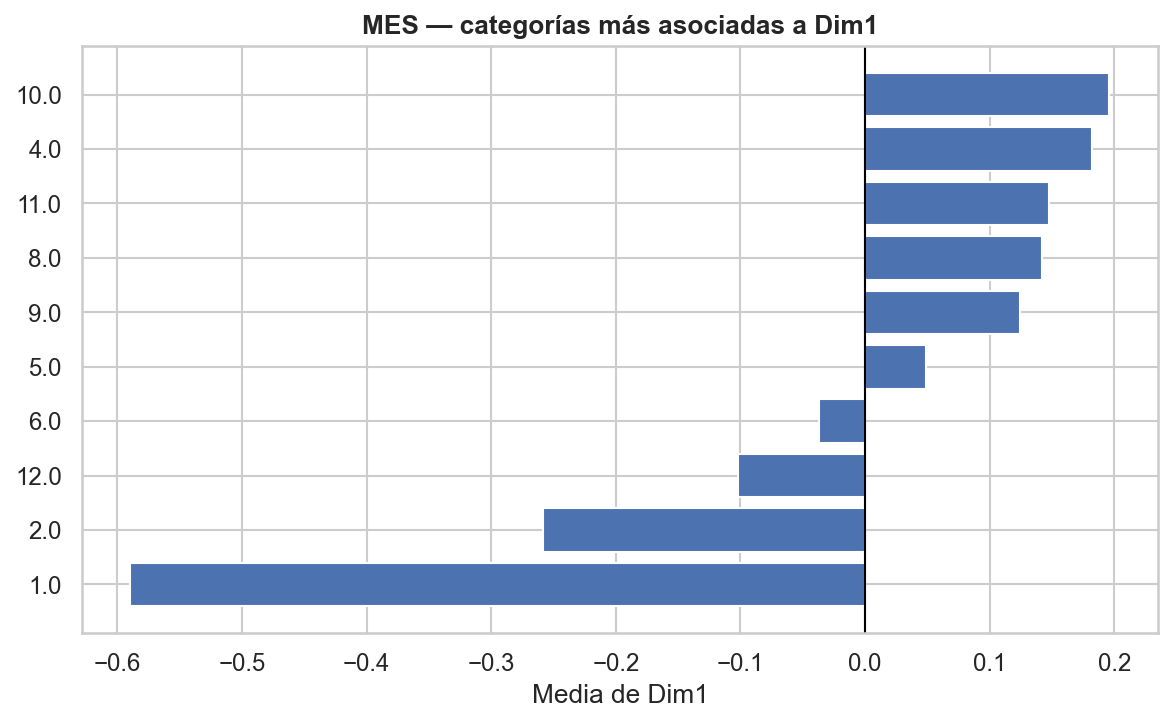


Variable categórica: MOTIV
        mean  count
MOTIV              
2.0    5.234   8294
16.0   4.128    887
18.0   2.989   3888
Otros  1.853   1831
8.0   -1.403  36351
5.0    1.331   1888
15.0  -1.119   3345
4.0    1.047    754
12.0  -0.784   1515
7.0   -0.652  20233


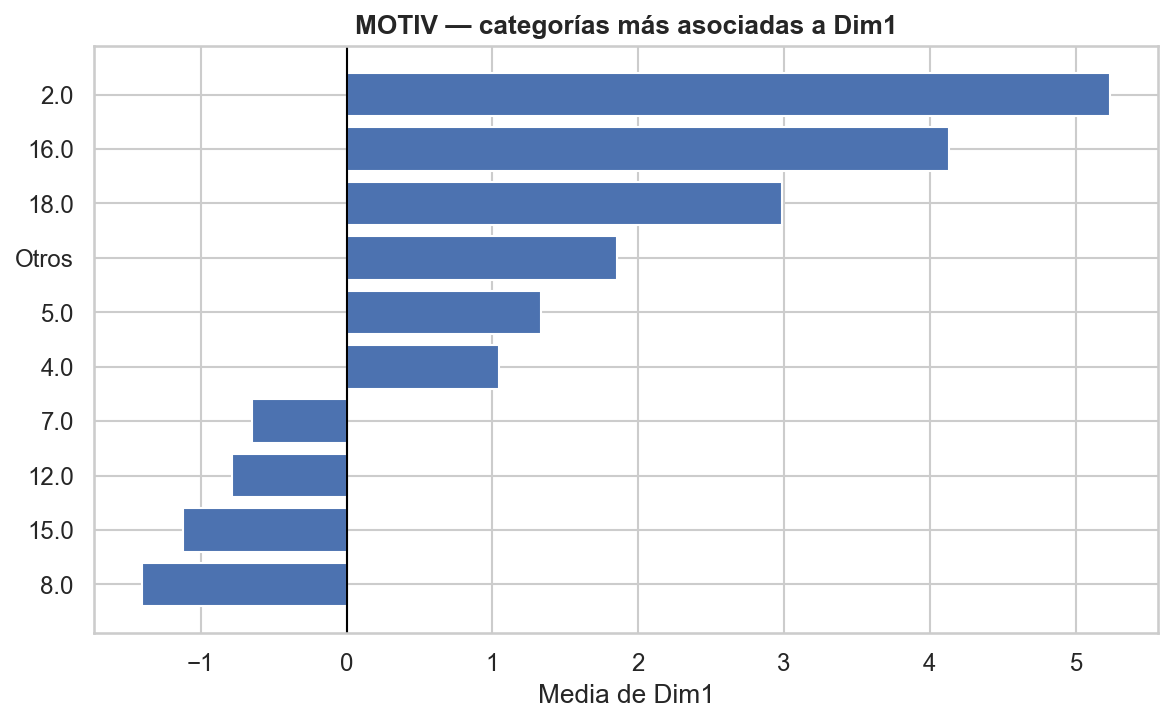


Variable categórica: ALOJAPRIN
             mean  count
ALOJAPRIN               
8.0        27.942    211
1.0         3.310  21213
6.0         2.251    423
10.0       -1.691  20019
2.0         1.478   2255
11.0       -1.347  41003
4.0         1.245    443
3.0         1.228   7134
Otros       0.773    113
9.0        -0.238   1715


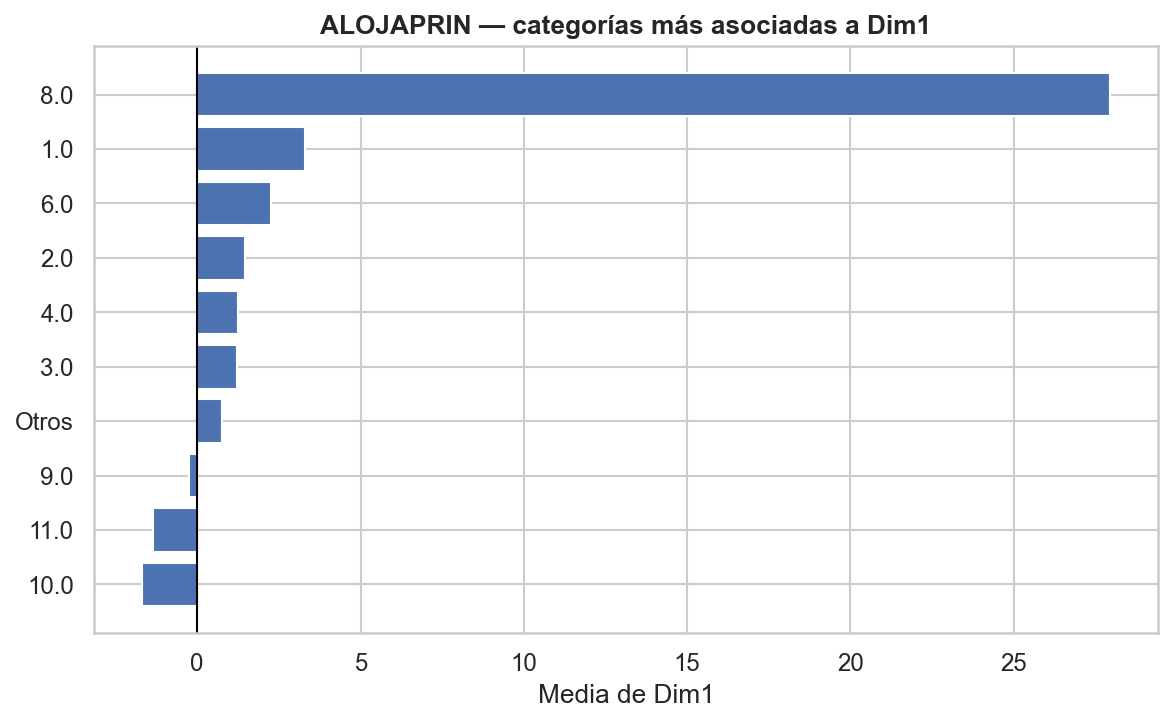


Variable categórica: TRANSPRIN
             mean  count
TRANSPRIN               
2.0        29.570    172
1.0         5.119  10851
6.0         1.954    540
7.0         1.794    203
9.0         1.388   4990
11.0        1.042     65
5.0        -0.934  75834
12.0       -0.709    242
8.0        -0.626    164
4.0         0.519     49


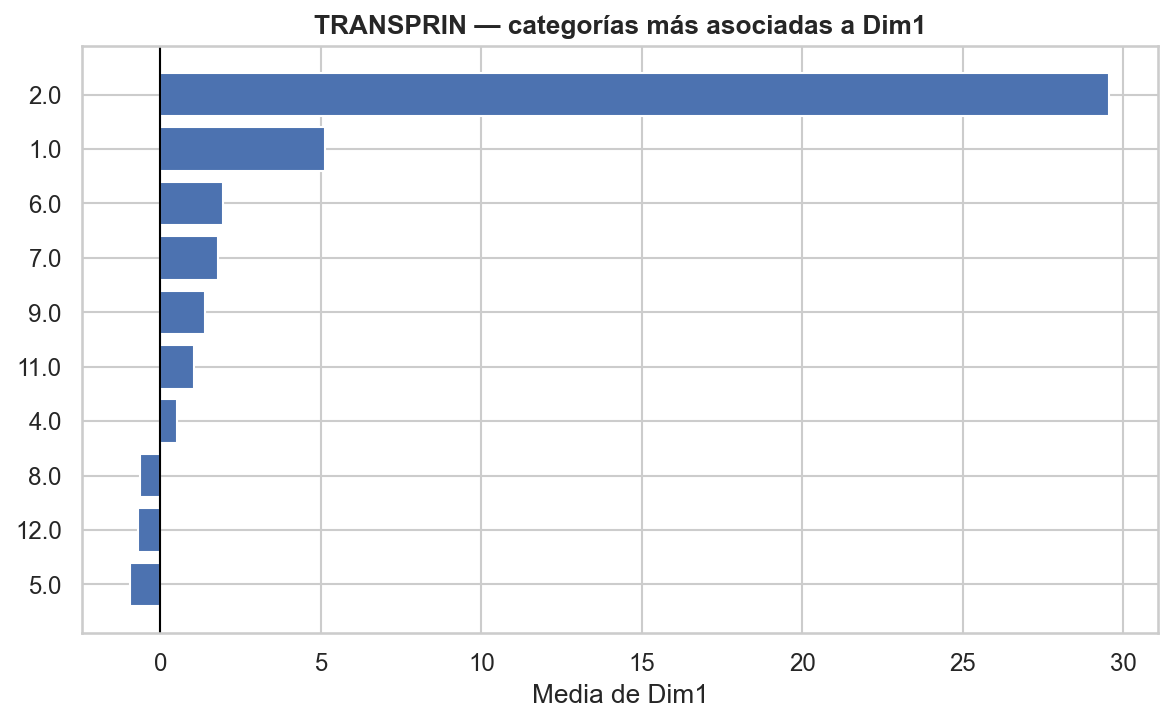


Variable categórica: DESTESP
          mean  count
DESTESP              
6.0      6.336   8526
1.0     -0.591  91474


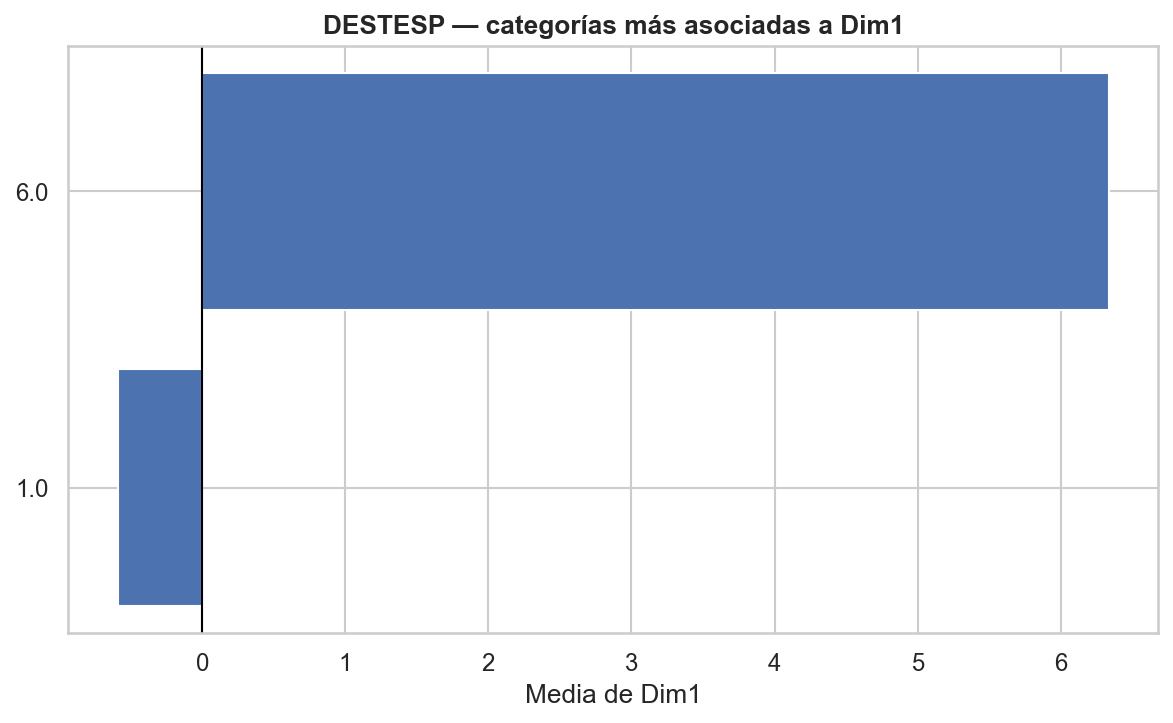


Variable categórica: PAQUETE
          mean  count
PAQUETE              
10.0     8.817   3665
80.0     5.504    313
60.0    -0.354  96022


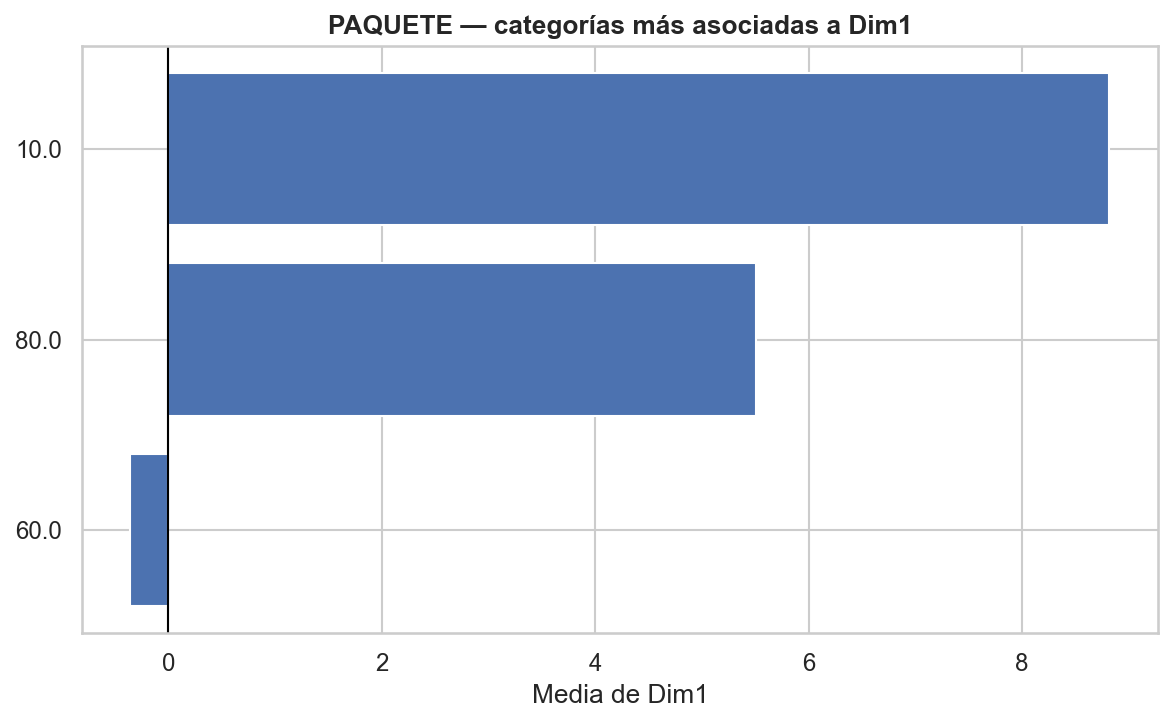



==================== Dim2 ====================

Variable categórica: ANYO
         mean  count
ANYO                
2024.0 -0.283  11057
2023.0 -0.262  10793
2020.0  0.260   6442
2017.0  0.164  13527
2021.0  0.104   9304
2016.0  0.103  12566
2018.0  0.095  13612
2019.0 -0.070  12744
2022.0 -0.060   9955


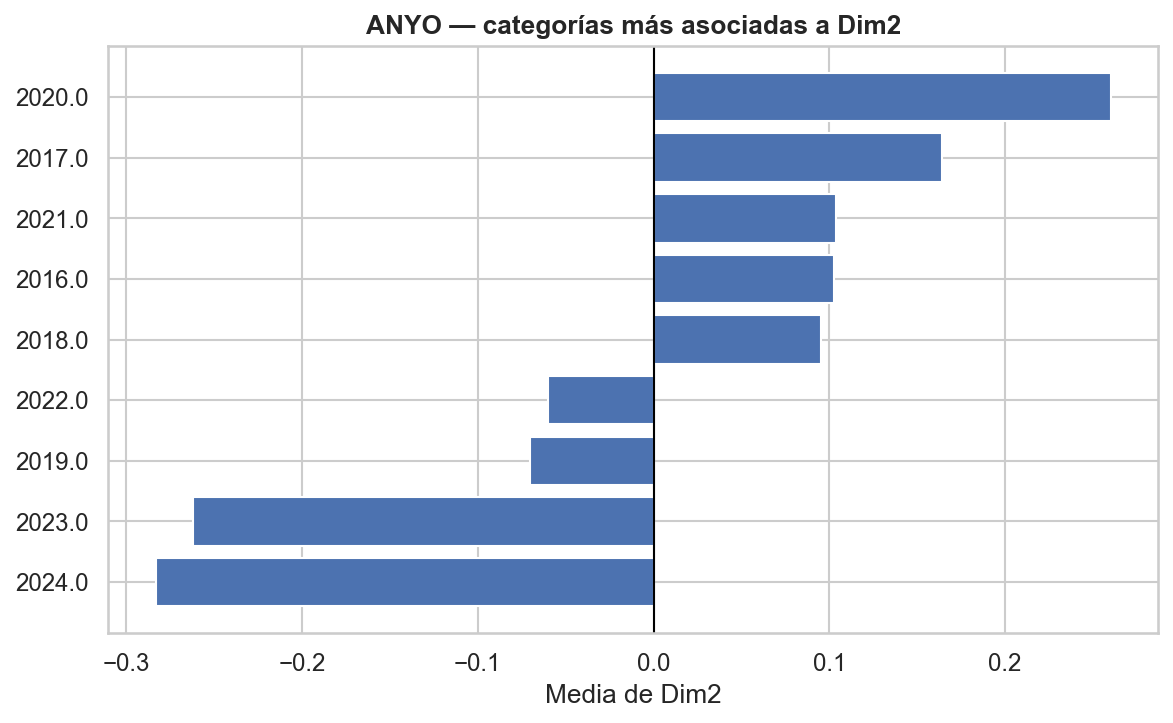


Variable categórica: MES
       mean  count
MES               
11.0 -0.207   6671
4.0  -0.118   7916
1.0   0.117   7326
12.0 -0.116   7513
7.0   0.113  10747
3.0  -0.110   6988
9.0   0.072   9141
8.0   0.068  13084
10.0 -0.055   7941
5.0   0.047   7562


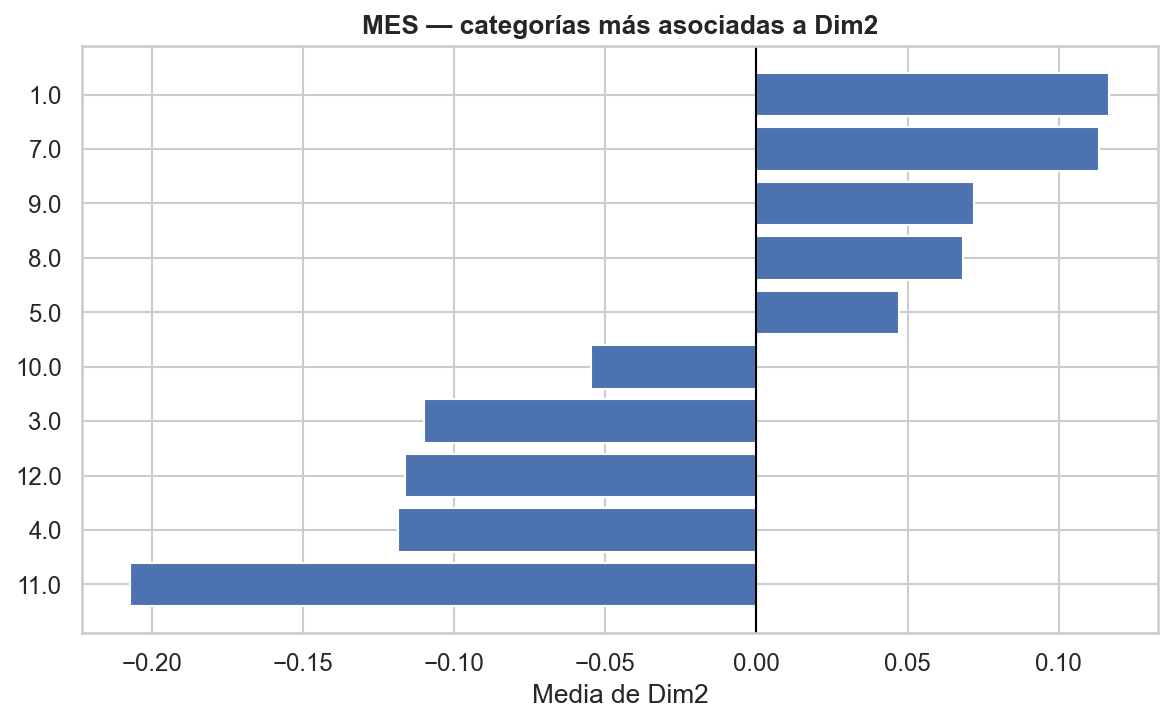


Variable categórica: MOTIV
        mean  count
MOTIV              
16.0  -3.417    887
18.0  -2.681   3888
4.0   -1.287    754
Otros -1.202   1831
2.0   -1.091   8294
5.0   -1.041   1888
7.0    0.783  20233
17.0  -0.662   4856
12.0  -0.618   1515
15.0   0.606   3345


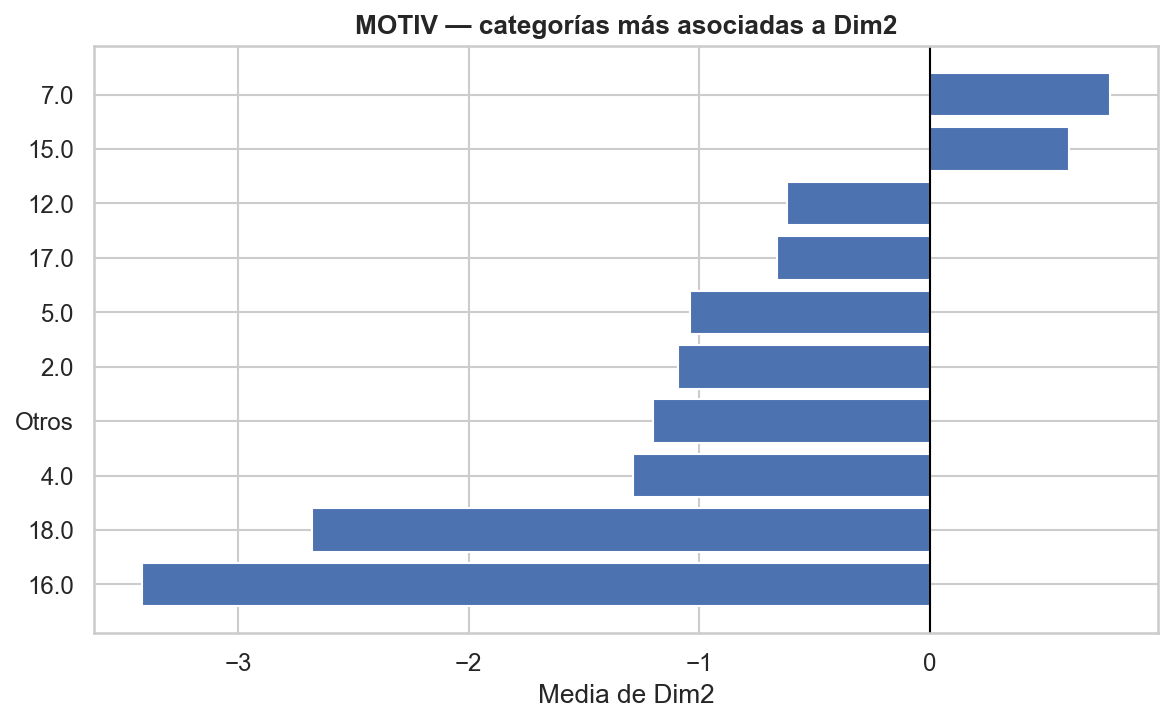


Variable categórica: ALOJAPRIN
             mean  count
ALOJAPRIN               
8.0        46.760    211
1.0        -1.666  21213
4.0        -1.529    443
2.0        -1.230   2255
3.0        -1.077   7134
6.0        -0.987    423
10.0        0.944  20019
9.0        -0.832   1715
Otros      -0.618    113
11.0        0.489  41003


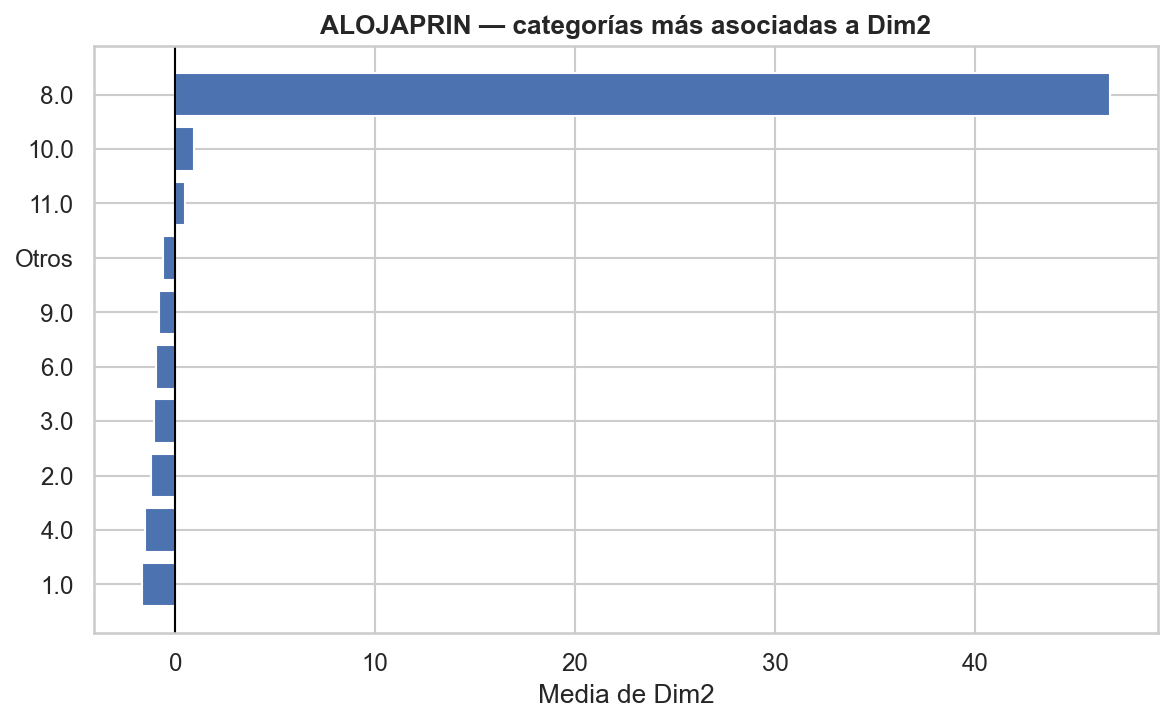


Variable categórica: TRANSPRIN
             mean  count
TRANSPRIN               
2.0        52.098    172
1.0        -2.224  10851
6.0        -2.199    540
4.0        -1.120     49
12.0       -1.115    242
7.0        -0.943    203
10.0       -0.816   5554
3.0        -0.508   1336
5.0         0.295  75834
11.0       -0.228     65


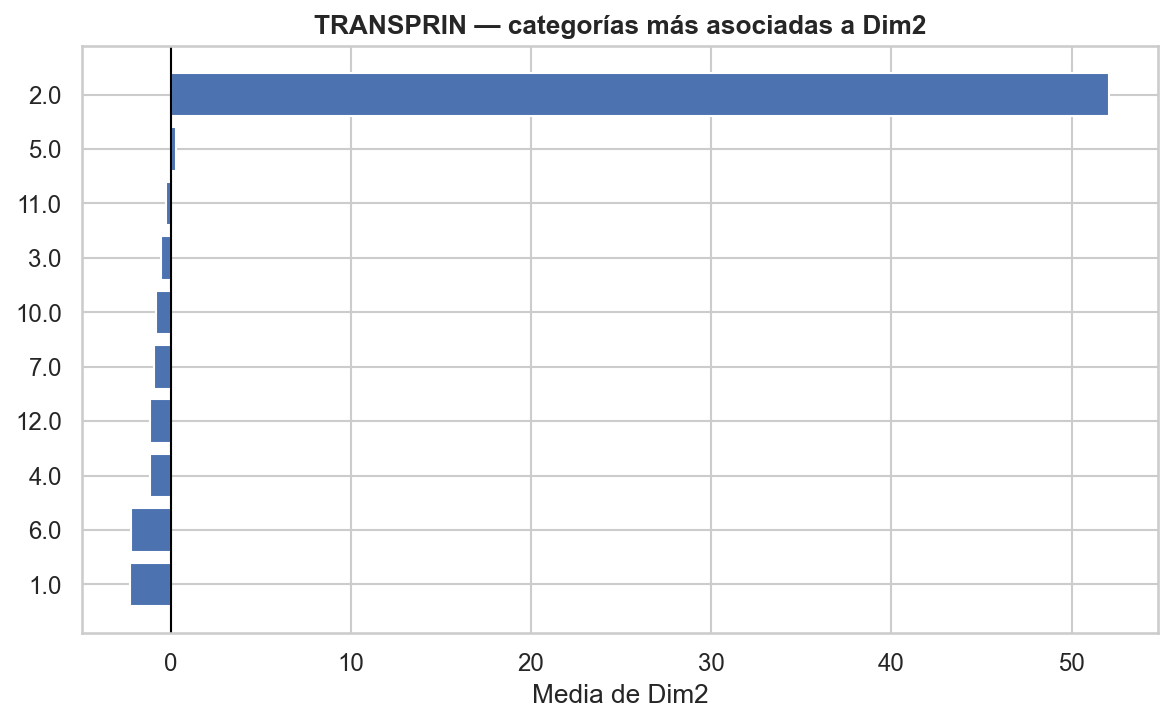


Variable categórica: DESTESP
          mean  count
DESTESP              
6.0     -1.082   8526
1.0      0.101  91474


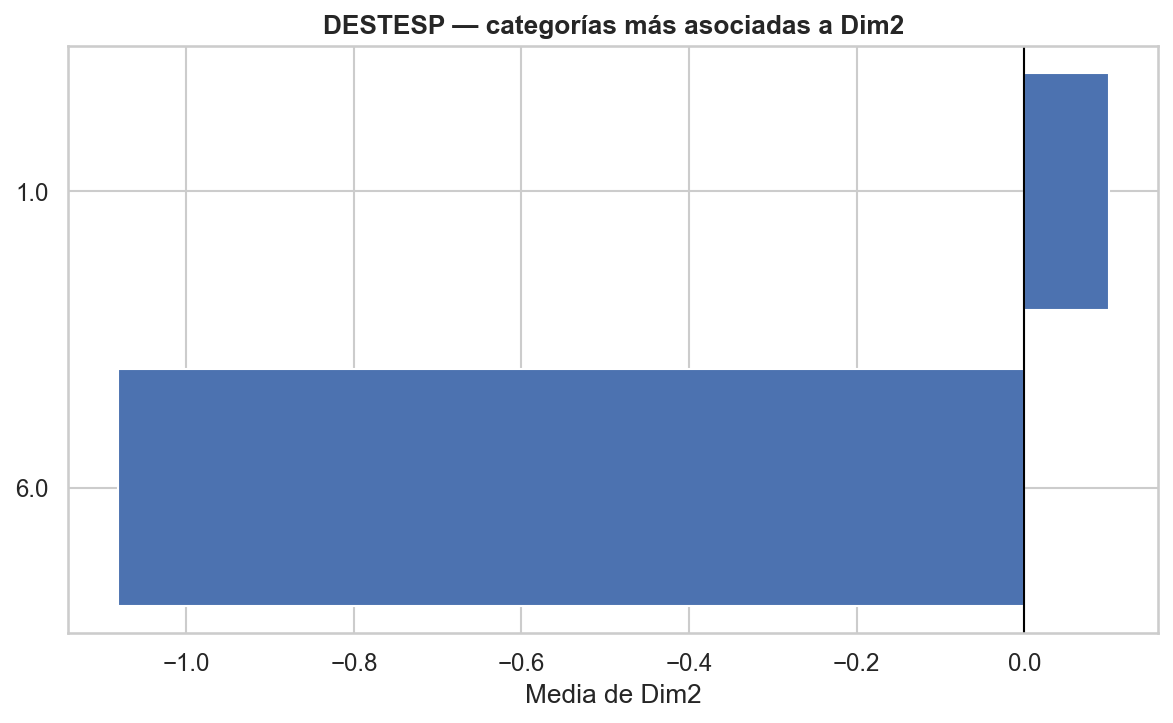


Variable categórica: PAQUETE
          mean  count
PAQUETE              
80.0    -4.402    313
10.0     1.736   3665
60.0    -0.052  96022


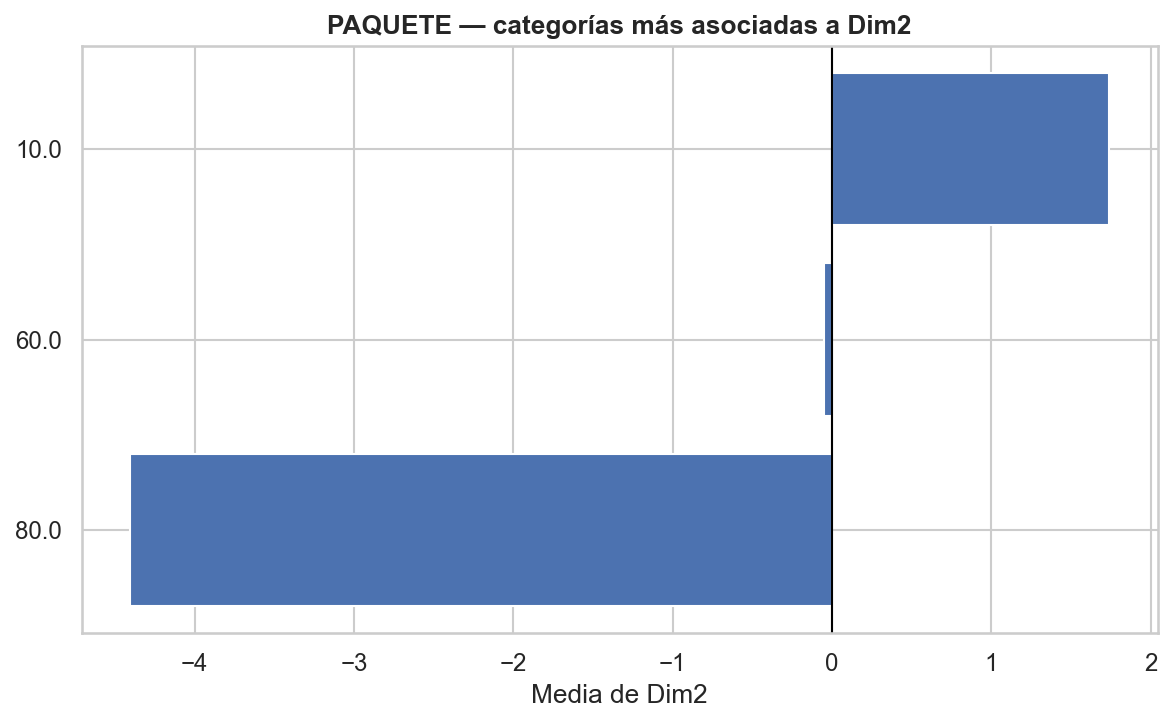

In [54]:
df_famd_plot = pd.concat(
    [df_rd.reset_index(drop=True), coords_famd.reset_index(drop=True)],
    axis=1
)

# Variables numéricas: correlación con cada dimensión
print("\nCorrelación de variables numéricas con las dimensiones FAMD:")
corrs_num = df_famd_plot[vars_num + [f"Dim{i+1}" for i in range(coords_famd.shape[1])]].corr()

for dim_nombre in ["Dim1", "Dim2"]:
    corr_dim = corrs_num.loc[vars_num, dim_nombre].sort_values(key=np.abs, ascending=False)
    print(f"\n{dim_nombre}:")
    print(corr_dim.round(3).to_string())

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(corr_dim.index, corr_dim.values, edgecolor="white")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Correlación de variables numéricas con {dim_nombre}", fontweight="bold")
    ax.set_ylabel("Correlación")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    ruta = os.path.join(OUTPUT_DIR, f"fig_famd_corr_num_{dim_nombre.lower()}.png")

    plt.show()

# Variables categóricas: medias de la dimensión por categoría 
for dim_nombre in ["Dim1", "Dim2"]:
    print(f"\n\n==================== {dim_nombre} ====================")

    for c in vars_cat:
        tabla_cat = (
            df_famd_plot
            .groupby(c, observed=False)[dim_nombre]
            .agg(["mean", "count"])
            .sort_values("mean", key=np.abs, ascending=False)
        )

        print(f"\nVariable categórica: {c}")
        print(tabla_cat.head(10).round(3).to_string())

        # gráfico con categorías más extremas
        top_tabla = tabla_cat.head(10).sort_values("mean")
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.barh(top_tabla.index.astype(str), top_tabla["mean"].values, edgecolor="white")
        ax.axvline(0, color="black", linewidth=1)
        ax.set_title(f"{c} — categorías más asociadas a {dim_nombre}", fontweight="bold")
        ax.set_xlabel(f"Media de {dim_nombre}")
        plt.tight_layout()
        ruta = os.path.join(OUTPUT_DIR, f"fig_famd_cat_{c.lower()}_{dim_nombre.lower()}.png")
    
        plt.show()

11. Plot FAMD en 2D

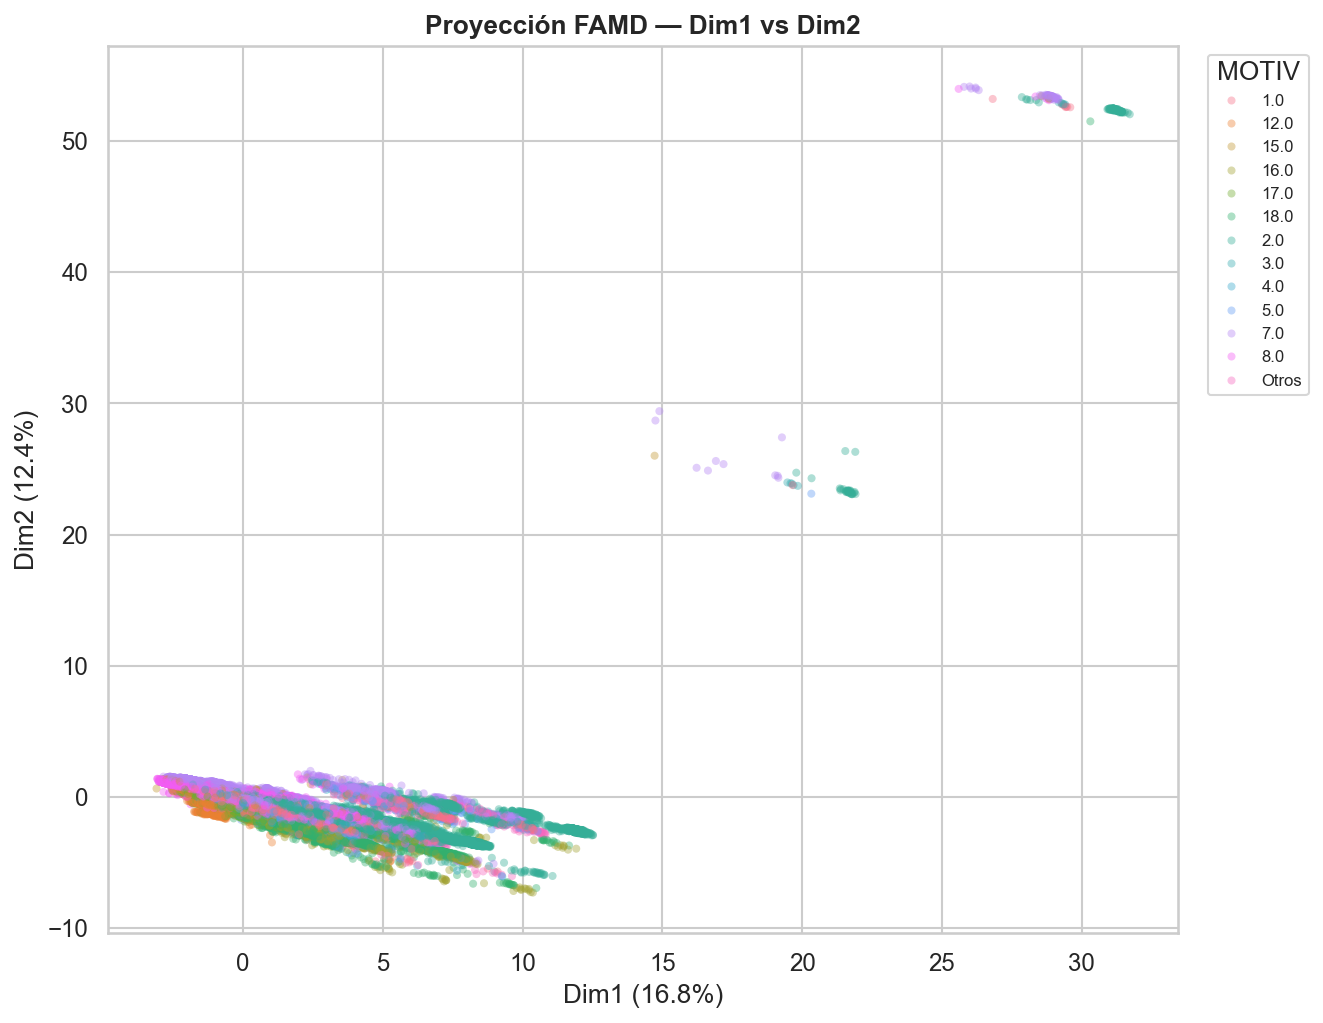

In [55]:
hue_var = COL_MOTIVO if COL_MOTIVO in df_famd_plot.columns else COL_ALOJ

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=df_famd_plot,
    x="Dim1", y="Dim2",
    hue=hue_var,
    alpha=0.4, s=15, linewidth=0,
    ax=ax,
)
ax.set_xlabel(f"Dim1 ({var_exp[0]:.1%})")
ax.set_ylabel(f"Dim2 ({var_exp[1]:.1%})")
ax.set_title("Proyección FAMD — Dim1 vs Dim2", fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left",
          title=hue_var, fontsize=8)
plt.tight_layout()
ruta = os.path.join(OUTPUT_DIR, "fig_famd_scatter_dim1_dim2.png")

plt.show()

12. UMAP sobre coordenadas FAMD

In [56]:
import sys
!{sys.executable} -m pip uninstall -y torch torchvision torchaudio
!{sys.executable} -m pip install --upgrade --force-reinstall umap-learn

  Using cached umap_learn-0.5.12-py3-none-any.whl.metadata (24 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached numba-0.65.1-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached llvmlite-0.47.0-cp313-cp313-win_amd64.whl.metadata (5.1 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
Using cached umap_learn-0.5.12-py3-none-any.whl (91 kB)
Using cached numba-0.65.1-cp313-cp313-win_amd64.whl (2.8 MB)
Using cached llvmlite-0.47.0-cp313-cp313-win_amd64.whl (38.1 MB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------- ----------------------------- 3.1/12.3 MB 4

error: uninstall-no-record-file

× Cannot uninstall numpy None
╰─> The package's contents are unknown: no RECORD file was found for numpy.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps numpy==2.3.3


In [57]:
import umap
print("UMAP cargado correctamente")

UMAP cargado correctamente



UMAP — input: 5 dimensiones FAMD | n_neighbors=30 | min_dist=0.10


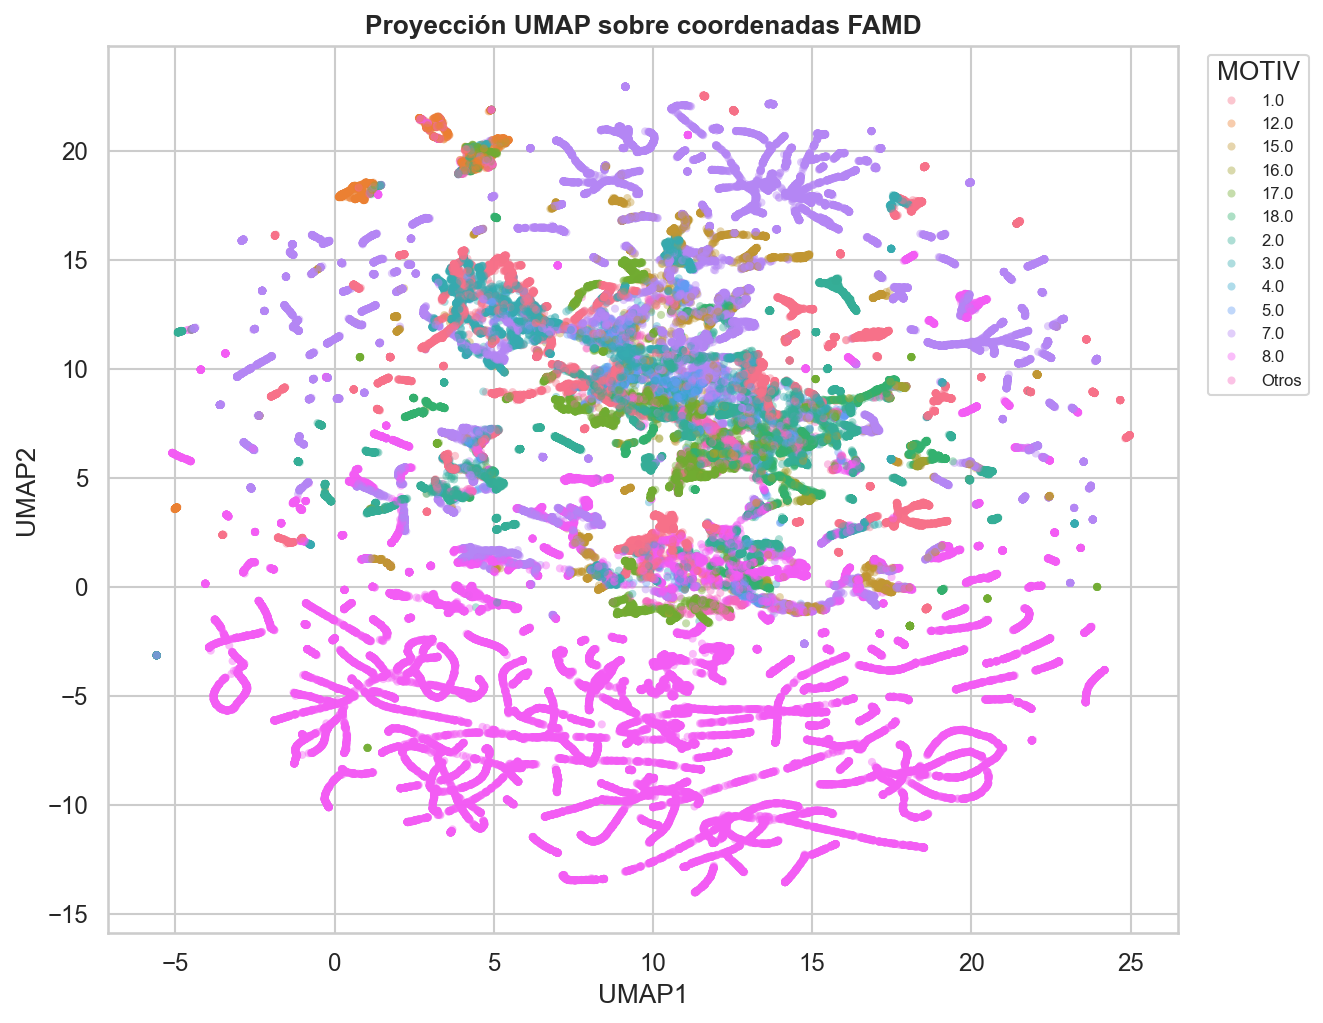

In [58]:
n_dims_umap = min(5, coords_famd.shape[1])
print(f"\nUMAP — input: {n_dims_umap} dimensiones FAMD | "
      f"n_neighbors=30 | min_dist=0.10")

umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.10,
    n_components=2,
    metric="euclidean",
    random_state=RANDOM_STATE,
)
emb = umap_model.fit_transform(coords_famd.iloc[:, :n_dims_umap])

df_famd_plot["UMAP1"] = emb[:, 0]
df_famd_plot["UMAP2"] = emb[:, 1]

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=df_famd_plot,
    x="UMAP1", y="UMAP2",
    hue=hue_var,
    alpha=0.4, s=15, linewidth=0,
    ax=ax,
)
ax.set_title("Proyección UMAP sobre coordenadas FAMD", fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left",
          title=hue_var, fontsize=8)
plt.tight_layout()
ruta = os.path.join(OUTPUT_DIR, "fig_umap_scatter.png")

plt.show()

13. Objeto final para clustering

In [59]:
reducido = df_famd_plot.copy()

print(f"\n✓ Objeto 'reducido' listo para clustering: {reducido.shape}")
print(f"  Columnas disponibles: {reducido.columns.tolist()}")


✓ Objeto 'reducido' listo para clustering: (100000, 21)
  Columnas disponibles: ['GASTOFI_TOTAL', 'NPERNOC_CORR', 'ANYO', 'MES', 'MOTIV', 'ALOJAPRIN', 'TRANSPRIN', 'DESTESP', 'PAQUETE', 'Dim1', 'Dim2', 'Dim3', 'Dim4', 'Dim5', 'Dim6', 'Dim7', 'Dim8', 'Dim9', 'Dim10', 'UMAP1', 'UMAP2']


# CLUSTERING

In [60]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [61]:
RANDOM_STATE = 42
OUTPUT_DIR   = r".\figuras_clustering"
os.makedirs(OUTPUT_DIR, exist_ok=True)

COLOR_BASE   = "#2c7bb6"
COLOR_ACCENT = "#d7191c"

# Dimensiones FAMD para clustering
cluster_vars = ["Dim1", "Dim2", "Dim3", "Dim4", "Dim5"]

# Variables para perfilado — PAQUETE solo se incluye si existe
vars_num = ["GASTOFI_TOTAL", "NPERNOC_CORR"]
vars_cat_base = ["ANYO", "MES", "MOTIV", "ALOJAPRIN", "TRANSPRIN", "DESTESP"]

# CAMBIO: PAQUETE se añade condicionalmente para evitar fallos silenciosos
vars_cat = [c for c in vars_cat_base + ["PAQUETE"] if c in reducido.columns]

# Verificación de columnas necesarias
cols_necesarias = cluster_vars + vars_num + vars_cat + ["UMAP1", "UMAP2"]
faltan = [c for c in cols_necesarias if c not in reducido.columns]
if faltan:
    raise ValueError(f"Faltan columnas en 'reducido': {faltan}")

X_cluster = reducido[cluster_vars].copy()
print(f"Shape de X_cluster: {X_cluster.shape}")

Shape de X_cluster: (100000, 5)


1. Selección de clusters

  k=2 | inercia=2,533,724 | silueta=0.8874
  k=3 | inercia=1,929,301 | silueta=0.3464
  k=4 | inercia=1,499,007 | silueta=0.3349
  k=5 | inercia=1,084,036 | silueta=0.3685
  k=6 | inercia=786,300 | silueta=0.4245
  k=7 | inercia=676,989 | silueta=0.4221
  k=8 | inercia=615,465 | silueta=0.4251

K propuesto por máxima silueta: 2


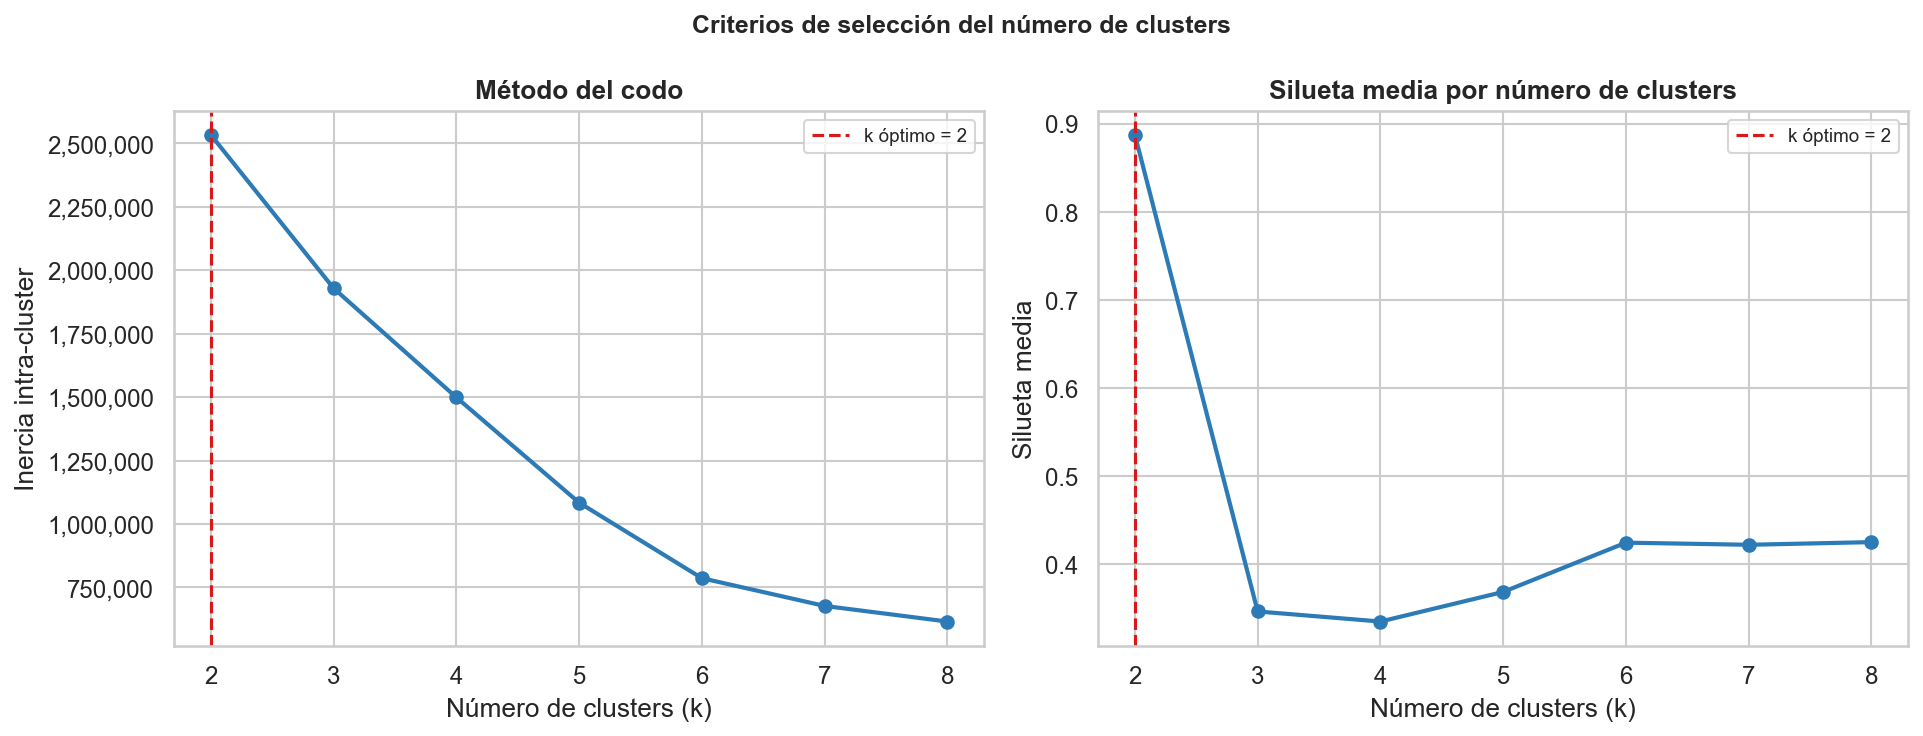

In [62]:
rango_k      = range(2, 9)
resultados_k = []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
    labels = km.fit_predict(X_cluster)
    resultados_k.append({
        "k":             k,
        "inercia":       km.inertia_,
        "silueta_media": silhouette_score(X_cluster, labels,
                                          sample_size=20_000,
                                          random_state=RANDOM_STATE),
    })
    print(f"  k={k} | inercia={km.inertia_:,.0f} | "
          f"silueta={resultados_k[-1]['silueta_media']:.4f}")

resultados_k = pd.DataFrame(resultados_k)

k_opt = int(resultados_k.loc[resultados_k["silueta_media"].idxmax(), "k"])
print(f"\nK propuesto por máxima silueta: {k_opt}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(resultados_k["k"], resultados_k["inercia"],
             "o-", color=COLOR_BASE, linewidth=2, markersize=6)
axes[0].axvline(k_opt, color=COLOR_ACCENT, linewidth=1.5,
                linestyle="--", label=f"k óptimo = {k_opt}")
axes[0].set_title("Método del codo", fontweight="bold")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia intra-cluster")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
)
axes[0].legend(fontsize=9)

axes[1].plot(resultados_k["k"], resultados_k["silueta_media"],
             "o-", color=COLOR_BASE, linewidth=2, markersize=6)
axes[1].axvline(k_opt, color=COLOR_ACCENT, linewidth=1.5,
                linestyle="--", label=f"k óptimo = {k_opt}")
axes[1].set_title("Silueta media por número de clusters", fontweight="bold")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silueta media")
axes[1].legend(fontsize=9)

plt.suptitle("Criterios de selección del número de clusters",
             fontweight="bold", fontsize=12)
plt.tight_layout()

2. K-means

In [63]:
kmeans_final = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=25)
reducido["cluster_kmeans"] = kmeans_final.fit_predict(X_cluster)

orden = (reducido["cluster_kmeans"]
         .value_counts()
         .sort_values(ascending=False)
         .index)
mapa_orden = {v: i for i, v in enumerate(orden)}
reducido["cluster_kmeans"] = reducido["cluster_kmeans"].map(mapa_orden)

# Recalcular silueta con asignaciones reordenadas
sil_final = silhouette_score(X_cluster, reducido["cluster_kmeans"],
                             sample_size=20_000, random_state=RANDOM_STATE)

print("\nTamaño de los clusters:")
print(reducido["cluster_kmeans"].value_counts().sort_index().to_string())
print(f"\nSilueta media final (K-means, k={k_opt}): {sil_final:.4f}")


Tamaño de los clusters:
cluster_kmeans
0    99784
1      216

Silueta media final (K-means, k=2): 0.8874


3. Scatter FAMD y UMAP

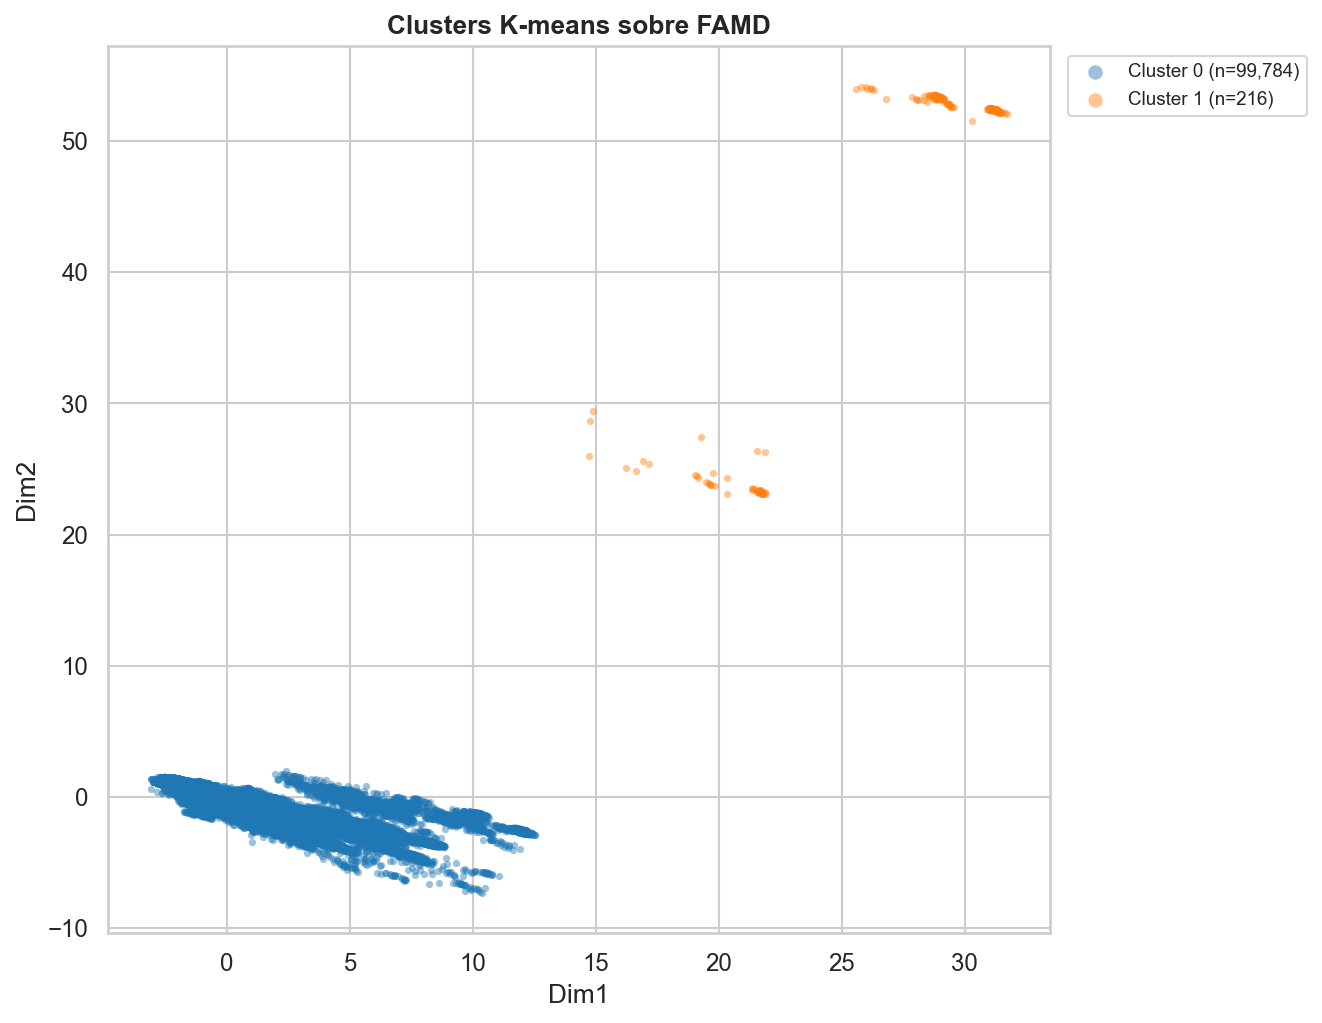

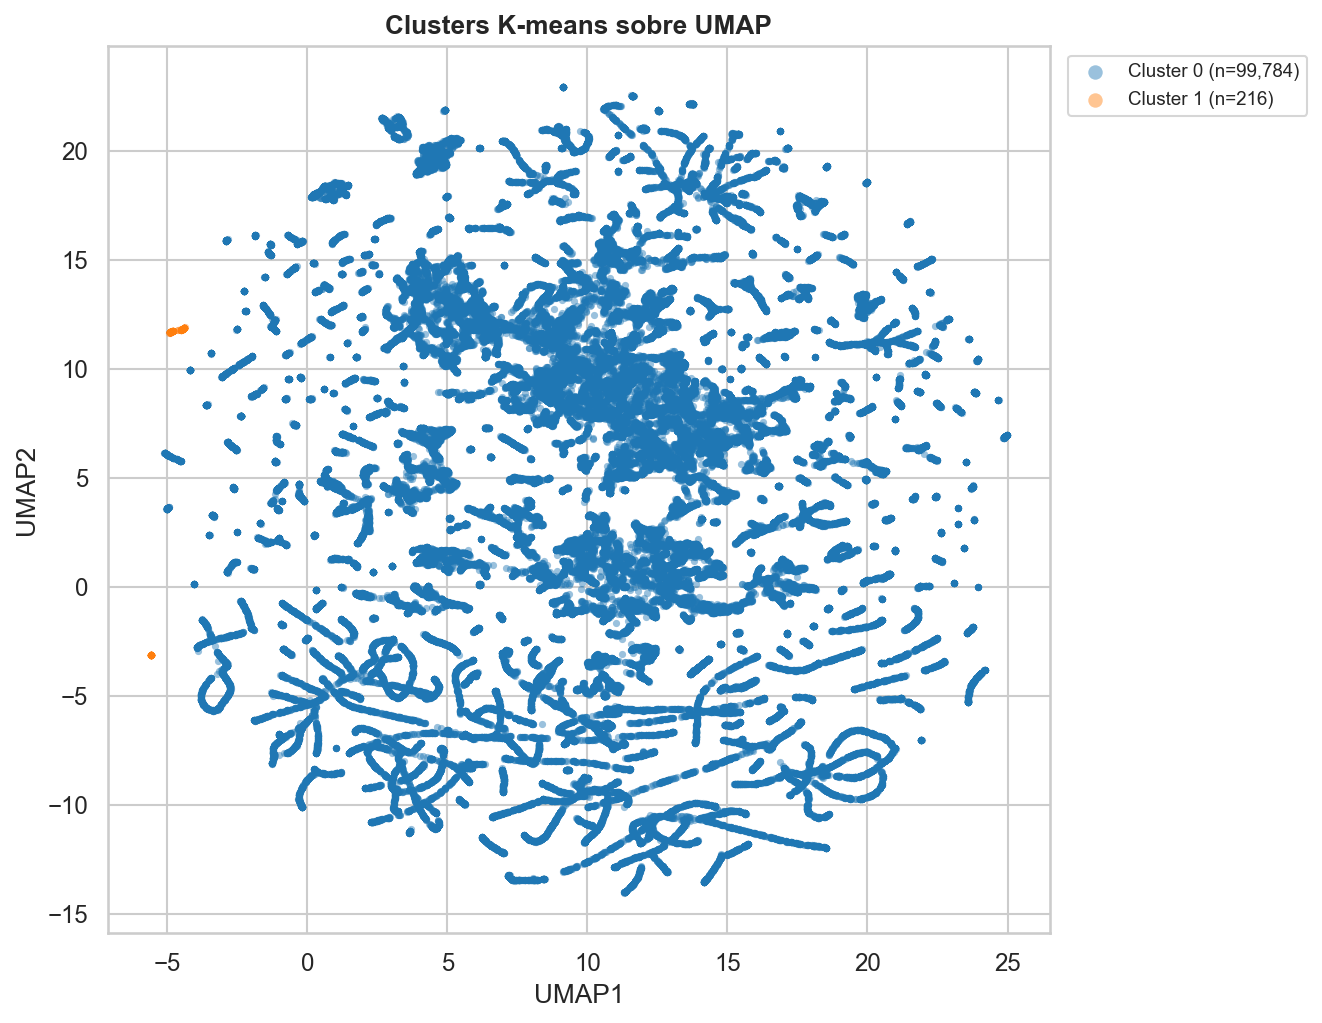

In [64]:
palette_clusters = sns.color_palette("tab10", n_colors=k_opt)

for espacio, x_col, y_col, titulo, fname in [
    ("FAMD",  "Dim1",  "Dim2",  "Clusters K-means sobre FAMD",
     "fig_clusters_kmeans_famd.png"),
    ("UMAP",  "UMAP1", "UMAP2", "Clusters K-means sobre UMAP",
     "fig_clusters_kmeans_umap.png"),
]:
    fig, ax = plt.subplots(figsize=(9, 7))
    for cl in sorted(reducido["cluster_kmeans"].unique()):
        sub = reducido[reducido["cluster_kmeans"] == cl]
        ax.scatter(sub[x_col], sub[y_col],
                   color=palette_clusters[cl],
                   s=12, alpha=0.45, linewidths=0,
                   label=f"Cluster {cl} (n={len(sub):,})")
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.legend(markerscale=2, fontsize=9,
              bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()

4. Perfilado numérico

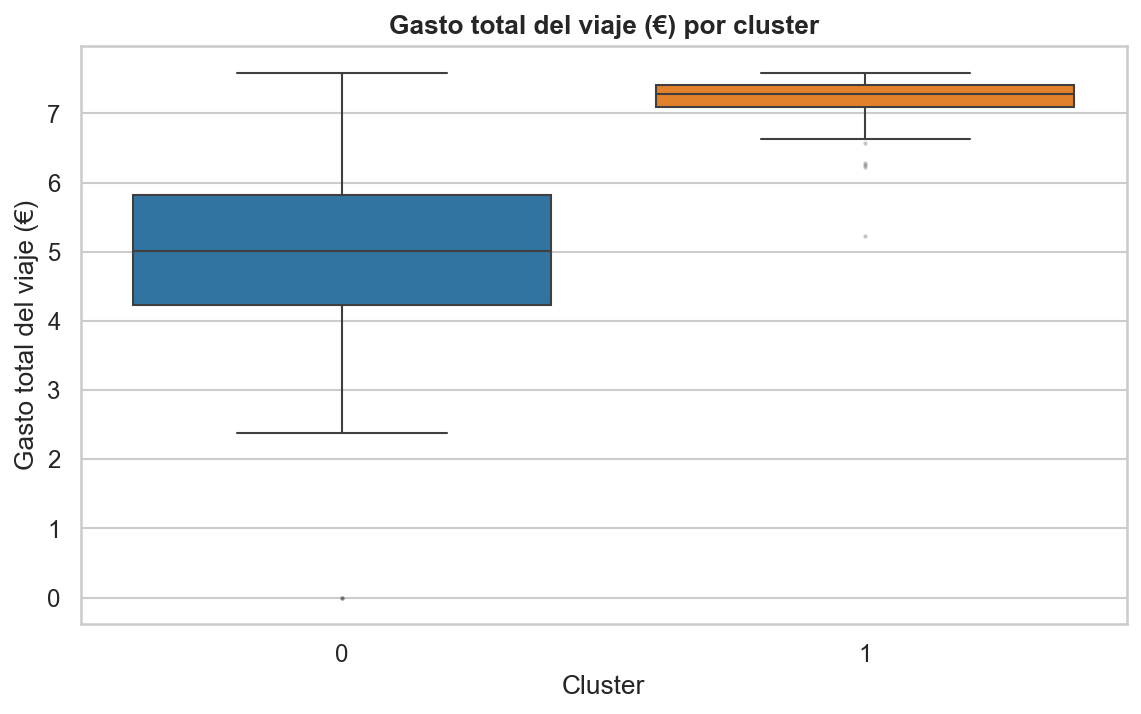

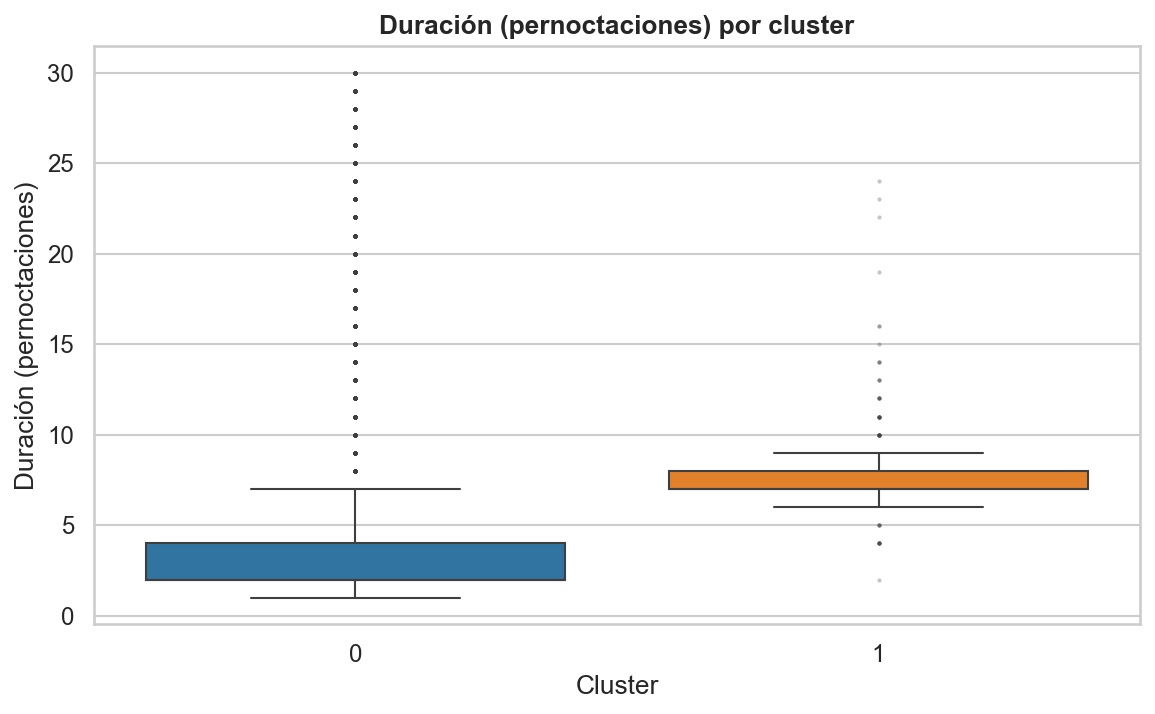

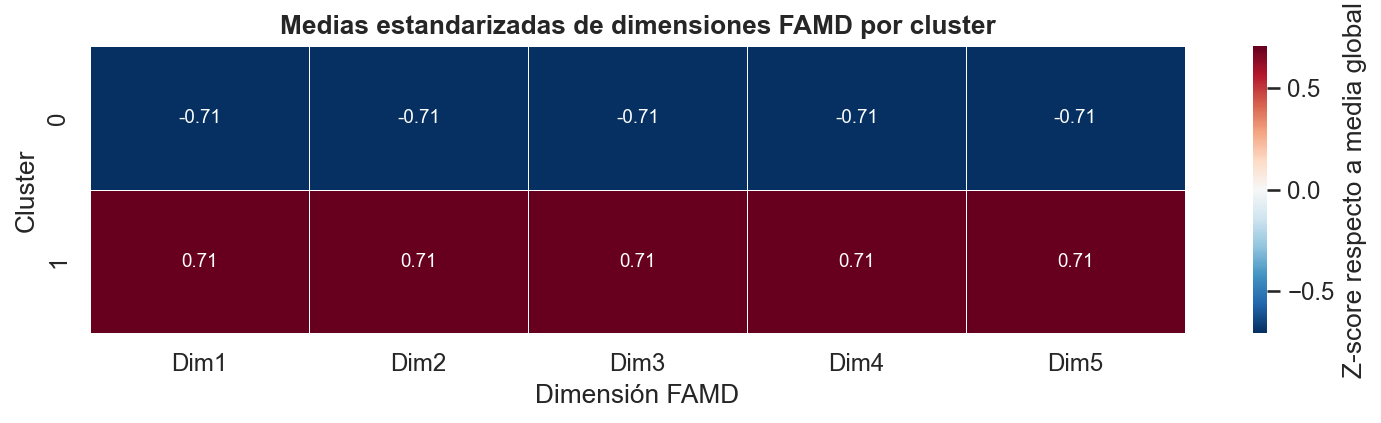

In [65]:
# Boxplots separados por variable numérica
for var, label in [(vars_num[0], "Gasto total del viaje (€)"),
                   (vars_num[1], "Duración (pernoctaciones)")]:
    if var not in reducido.columns:
        continue
    p99 = reducido[var].quantile(0.99)
    sub = reducido[reducido[var] <= p99]

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(data=sub, x="cluster_kmeans", y=var,
                palette=palette_clusters,
                flierprops={"marker": ".", "markersize": 2, "alpha": 0.3},
                ax=ax)
    ax.set_title(f"{label} por cluster", fontweight="bold")
    ax.set_xlabel("Cluster")
    ax.set_ylabel(label)
   

# Heatmap de medias estandarizadas (Z-score) de las dimensiones FAMD
medias_dims = reducido.groupby("cluster_kmeans")[cluster_vars].mean()
medias_dims_z = (medias_dims - medias_dims.mean()) / medias_dims.std()

fig, ax = plt.subplots(figsize=(10, max(3, k_opt * 0.8)))
sns.heatmap(medias_dims_z,
            annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.4, annot_kws={"fontsize": 9},
            cbar_kws={"label": "Z-score respecto a media global"},
            ax=ax)
ax.set_title("Medias estandarizadas de dimensiones FAMD por cluster",
             fontweight="bold")
ax.set_xlabel("Dimensión FAMD")
ax.set_ylabel("Cluster")
plt.tight_layout()

5. Perfilado categórico


Moda de variables categóricas por cluster:
     ANYO  MES MOTIV ALOJAPRIN TRANSPRIN DESTESP PAQUETE
0  2018.0  8.0   8.0      11.0       5.0     1.0    60.0
1  2022.0  8.0   2.0       8.0       2.0     6.0    10.0


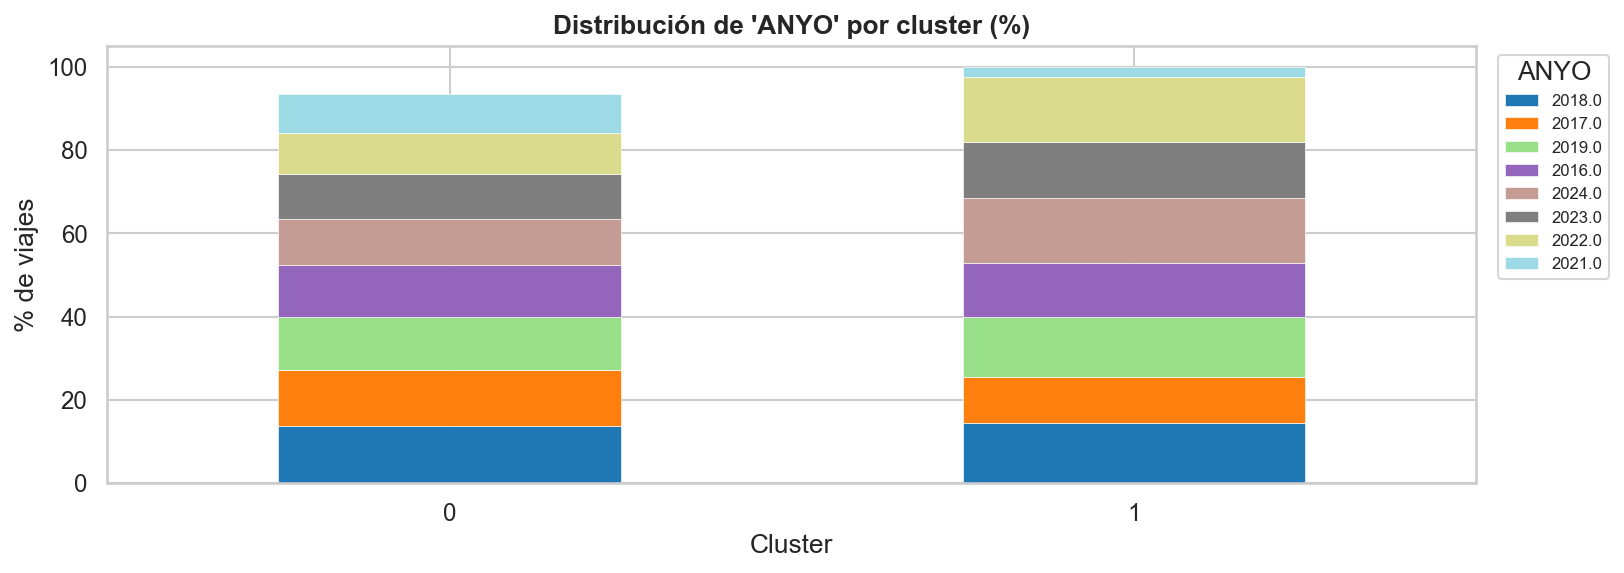

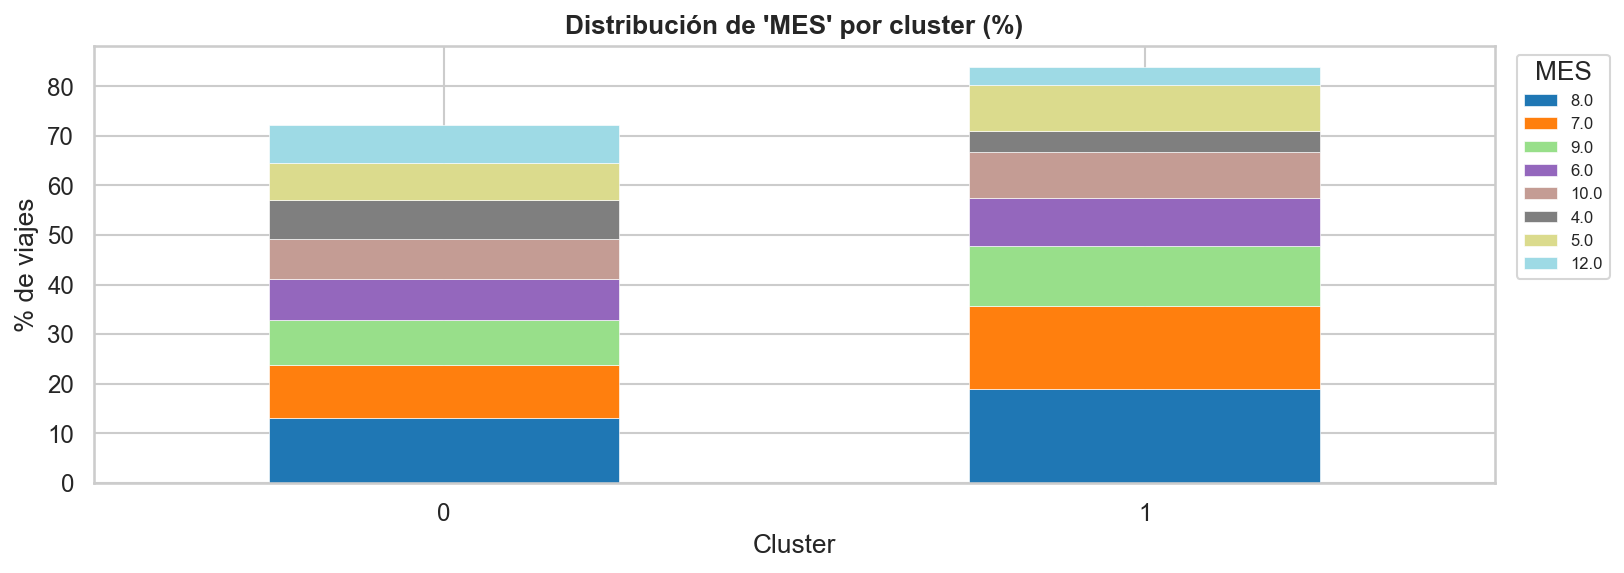

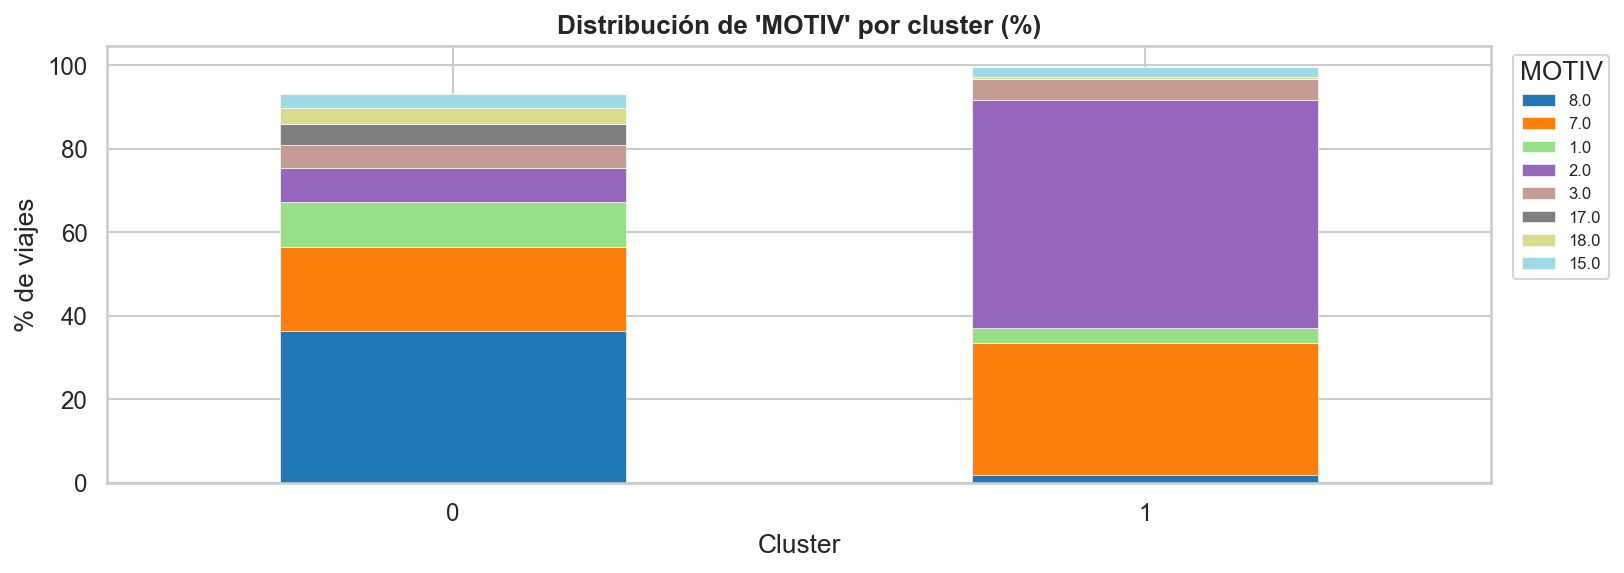

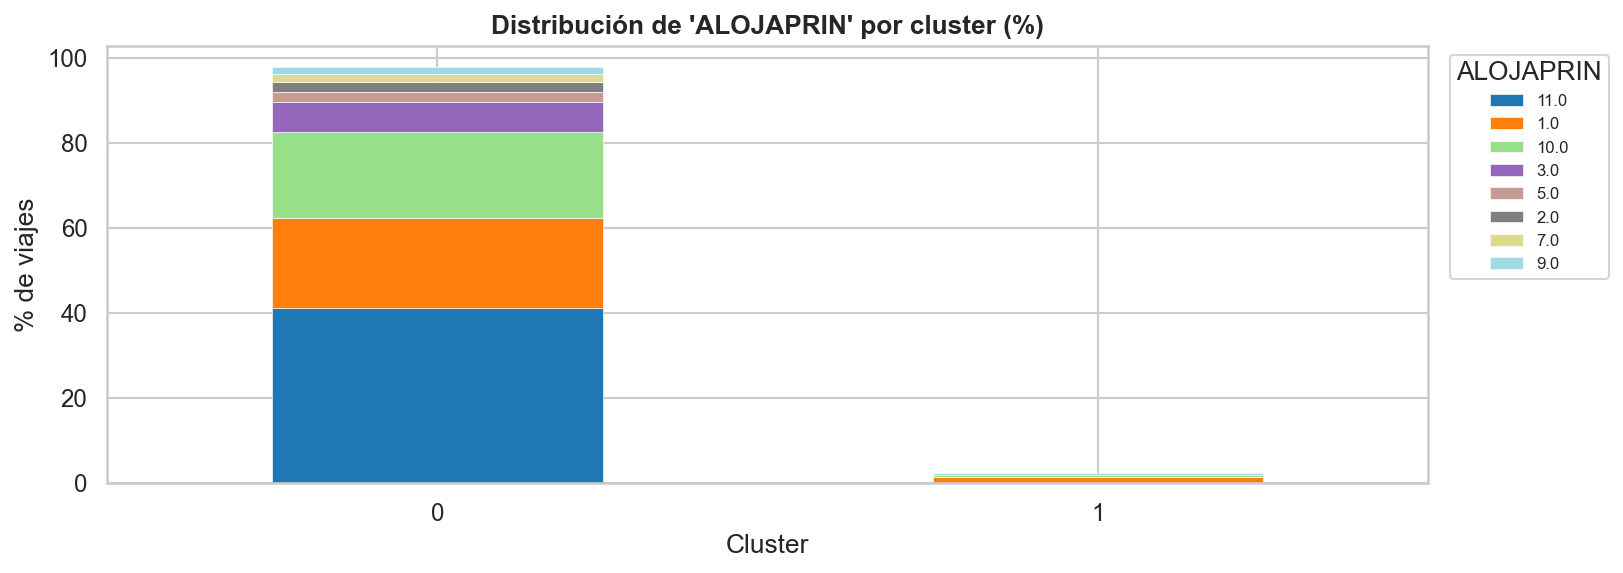

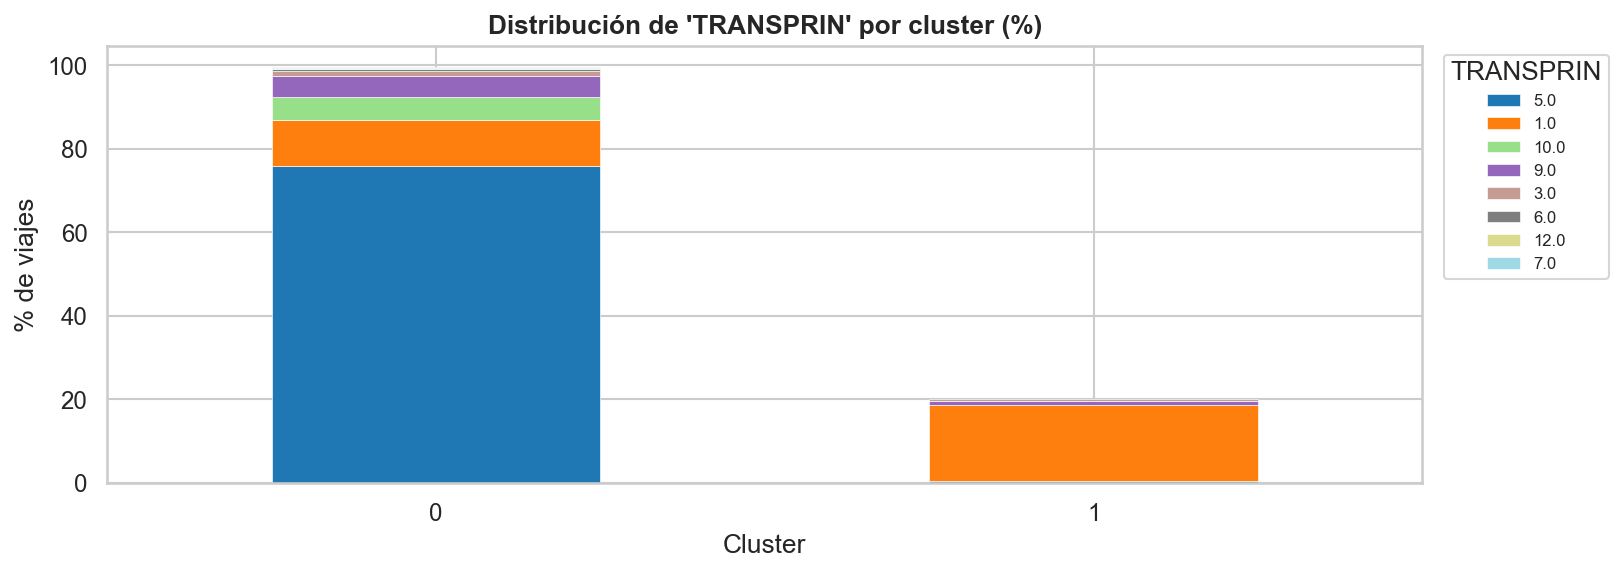

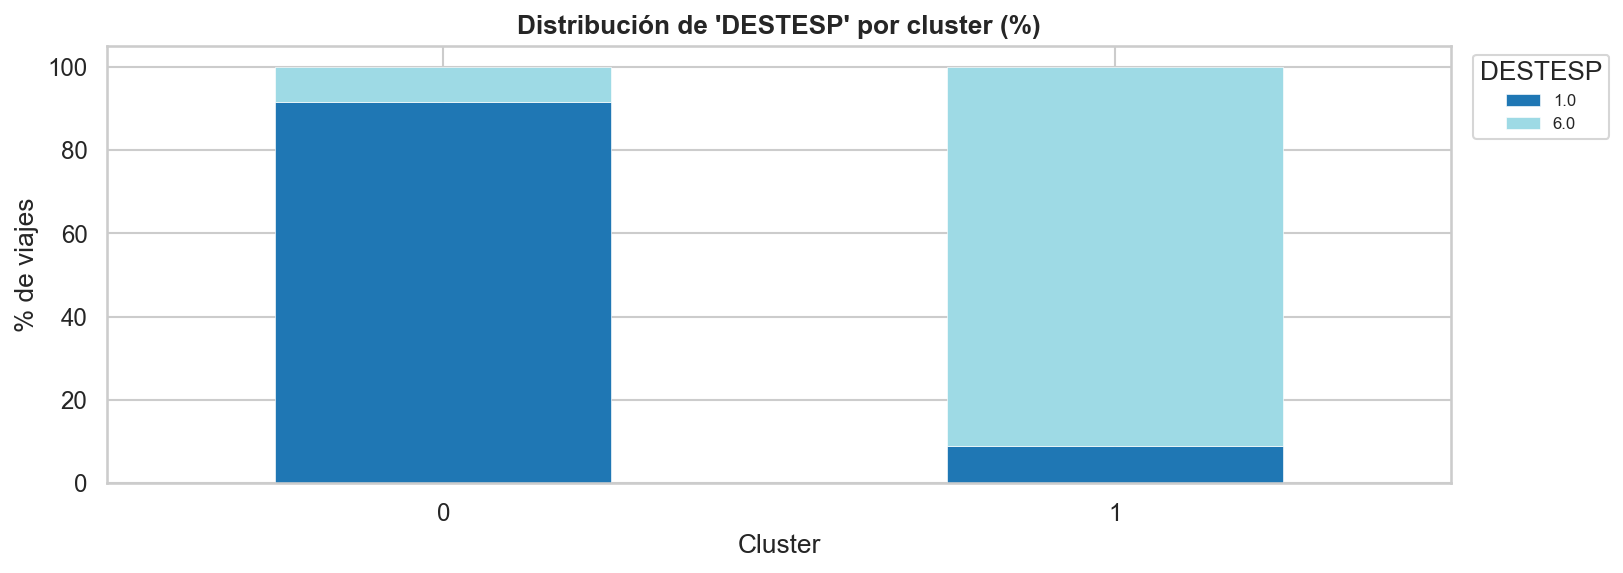

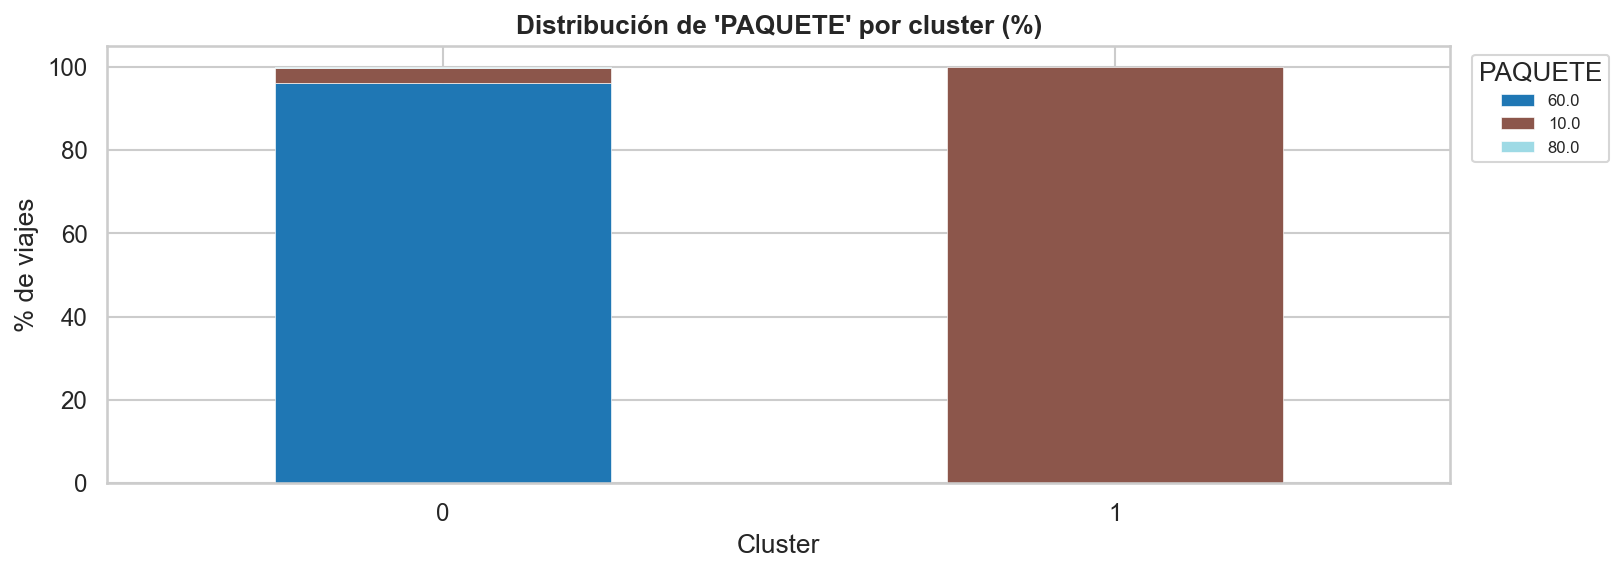

In [66]:
for c in vars_cat:
    if c not in reducido.columns:
        continue

    tabla = (pd.crosstab(reducido["cluster_kmeans"], reducido[c],
                         normalize="index") * 100).round(1)

    # Solo top categorías 
    top_cats = reducido[c].value_counts().head(8).index
    tabla    = tabla[[col for col in top_cats if col in tabla.columns]]

    fig, ax = plt.subplots(figsize=(11, 4))
    tabla.plot(kind="bar", stacked=True, ax=ax,
               colormap="tab20", edgecolor="white", linewidth=0.3)
    ax.set_title(f"Distribución de '{c}' por cluster (%)",
                 fontweight="bold")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("% de viajes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title=c, bbox_to_anchor=(1.01, 1),
              loc="upper left", fontsize=8)
    plt.tight_layout()


# Tabla resumen de modas
moda_resumen = pd.DataFrame(index=sorted(reducido["cluster_kmeans"].unique()))
for c in vars_cat:
    if c in reducido.columns:
        moda_resumen[c] = (reducido.groupby("cluster_kmeans")[c]
                           .agg(lambda x: x.mode().iloc[0]
                                if not x.mode().empty else np.nan))
print("\nModa de variables categóricas por cluster:")
print(moda_resumen.to_string())

6. Centroides

In [67]:
centroides = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=cluster_vars,
).round(3)
centroides.index = mapa_orden.values()  
centroides.index.name = "cluster"
print("\nCentroides en el espacio FAMD:")
print(centroides.to_string())


Centroides en el espacio FAMD:
           Dim1    Dim2   Dim3   Dim4   Dim5
cluster                                     
0        -0.060  -0.100 -0.003 -0.006 -0.007
1        27.723  46.317  1.455  2.686  3.277



ANÁLISIS DE SENSIBILIDAD K-MEANS | k = 2

Tamaño de los clusters:
cluster_kmeans_k2
0    99784
1      216

Peso relativo de los clusters (%):
cluster_kmeans_k2
0    99.784
1     0.216

Silueta media (K-means, k=2): 0.8874

Centroides en el espacio FAMD:
           Dim1    Dim2   Dim3   Dim4   Dim5
cluster                                     
0        -0.060  -0.100 -0.003 -0.006 -0.007
1        27.723  46.317  1.455  2.686  3.277

ANÁLISIS DE SENSIBILIDAD K-MEANS | k = 3

Tamaño de los clusters:
cluster_kmeans_k3
0    81486
1    18298
2      216

Peso relativo de los clusters (%):
cluster_kmeans_k3
0    81.486
1    18.298
2     0.216

Silueta media (K-means, k=3): 0.3464

Centroides en el espacio FAMD:
           Dim1    Dim2   Dim3   Dim4   Dim5
cluster                                     
0        -1.121   0.346 -0.100  0.060  0.129
1         4.676  -2.093  0.428 -0.300 -0.614
2        27.723  46.317  1.455  2.686  3.277

ANÁLISIS DE SENSIBILIDAD K-MEANS | k = 4

Tamaño de los clust

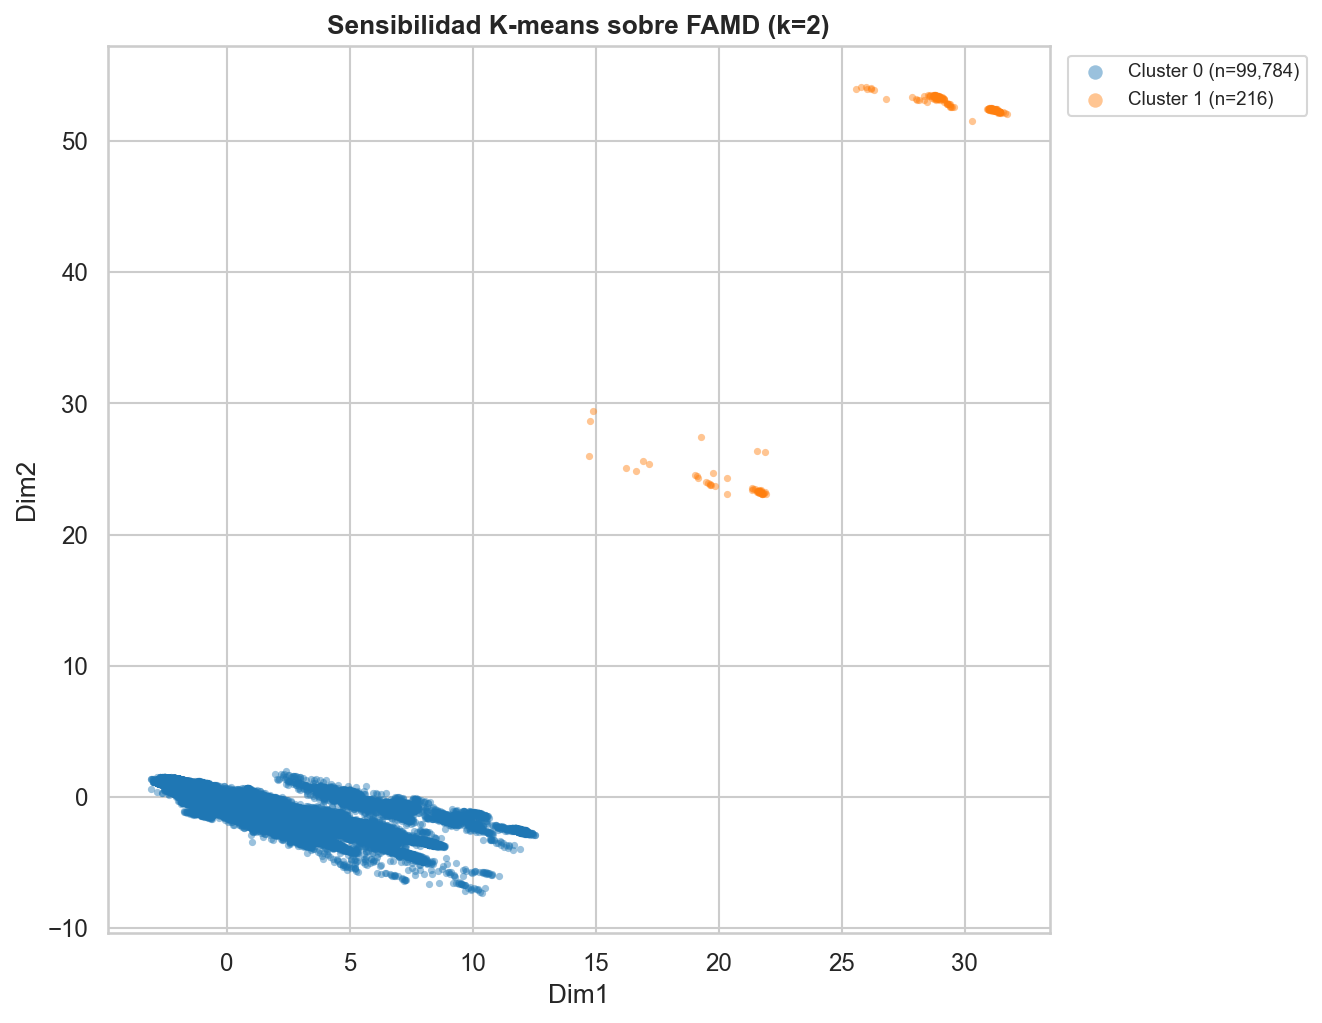

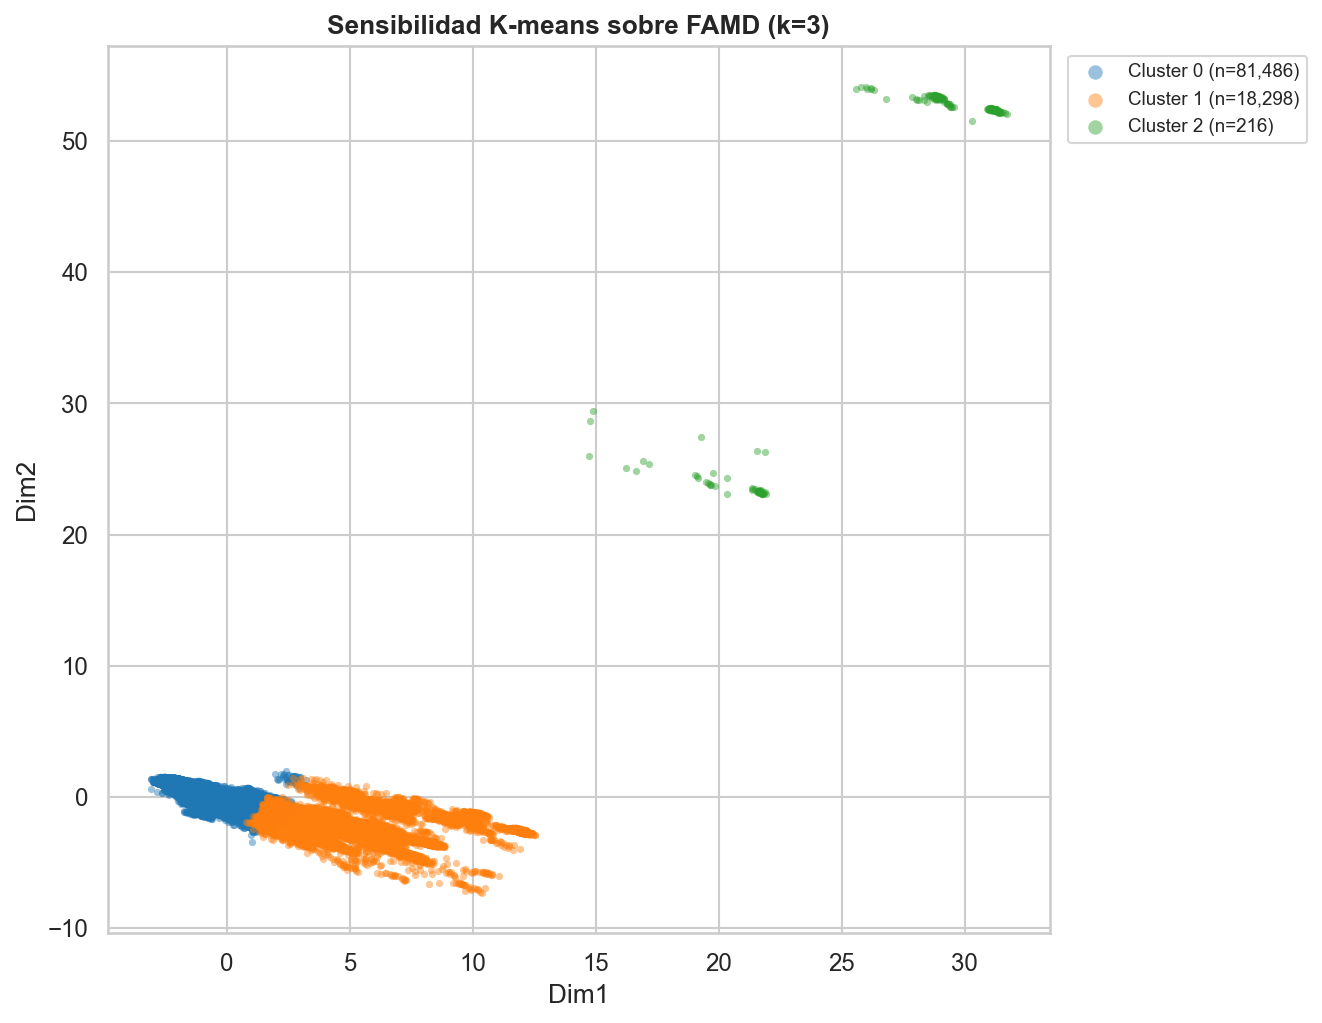

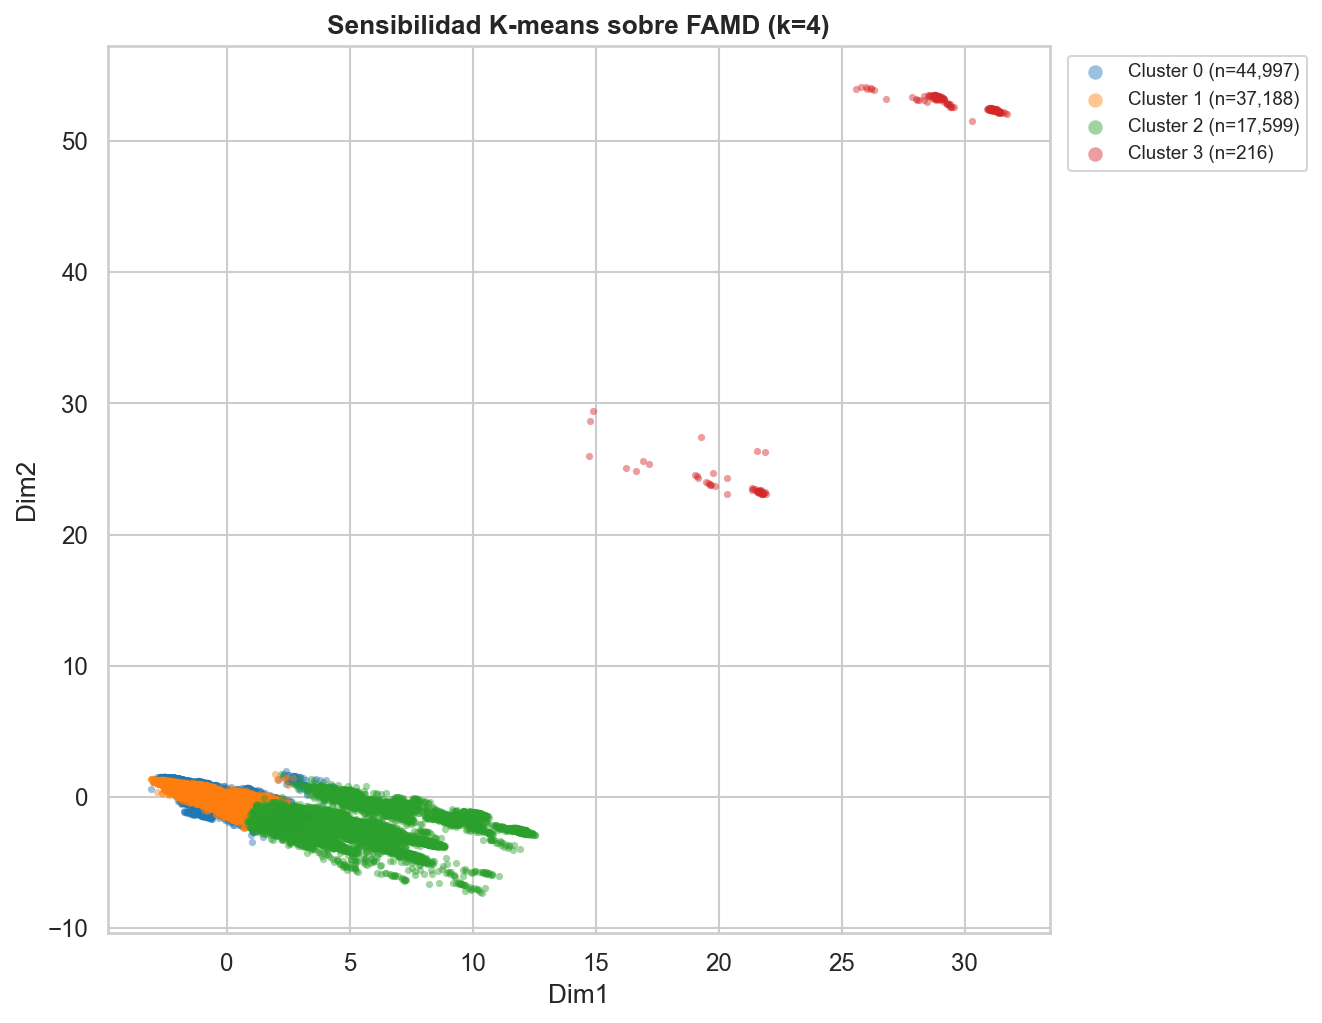

In [68]:
ks_sensibilidad = [2, 3, 4]
resultados_sensibilidad = []
centroides_sensibilidad = {}

for k_test in ks_sensibilidad:
    print("\n" + "="*70)
    print(f"ANÁLISIS DE SENSIBILIDAD K-MEANS | k = {k_test}")
    print("="*70)

    km = KMeans(
        n_clusters=k_test,
        random_state=RANDOM_STATE,
        n_init=25
    )

    labels_raw = km.fit_predict(X_cluster)

    # Reordenar clusters por tamaño descendente:
    labels_series = pd.Series(labels_raw, index=reducido.index, name=f"cluster_kmeans_k{k_test}")

    orden = (
        labels_series
        .value_counts()
        .sort_values(ascending=False)
        .index
    )

    mapa_orden = {v: i for i, v in enumerate(orden)}
    labels_ord = labels_series.map(mapa_orden)

    reducido[f"cluster_kmeans_k{k_test}"] = labels_ord

    # Tamaños absolutos y porcentajes
    conteos = labels_ord.value_counts().sort_index()
    porcentajes = (conteos / len(labels_ord) * 100).round(3)

    # Silueta
    sil = silhouette_score(
        X_cluster,
        labels_ord,
        sample_size=20_000,
        random_state=RANDOM_STATE
    )

    print("\nTamaño de los clusters:")
    print(conteos.to_string())

    print("\nPeso relativo de los clusters (%):")
    print(porcentajes.to_string())

    print(f"\nSilueta media (K-means, k={k_test}): {sil:.4f}")

    # Guardar resultados resumen
    for cl in conteos.index:
        resultados_sensibilidad.append({
            "k": k_test,
            "cluster": cl,
            "n_observaciones": int(conteos.loc[cl]),
            "porcentaje": float(porcentajes.loc[cl]),
            "silueta_media": sil
        })

    # Centroides reordenados
    centroides = pd.DataFrame(
        km.cluster_centers_,
        columns=cluster_vars
    )

    centroides = centroides.rename(index=mapa_orden).sort_index().round(3)
    centroides.index.name = "cluster"

    centroides_sensibilidad[k_test] = centroides

    print("\nCentroides en el espacio FAMD:")
    print(centroides.to_string())

    # Scatter FAMD para cada k
    palette_clusters = sns.color_palette("tab10", n_colors=k_test)

    fig, ax = plt.subplots(figsize=(9, 7))

    for cl in sorted(labels_ord.unique()):
        sub = reducido[reducido[f"cluster_kmeans_k{k_test}"] == cl]
        ax.scatter(
            sub["Dim1"],
            sub["Dim2"],
            color=palette_clusters[cl],
            s=12,
            alpha=0.45,
            linewidths=0,
            label=f"Cluster {cl} (n={len(sub):,})"
        )

    ax.set_title(
        f"Sensibilidad K-means sobre FAMD (k={k_test})",
        fontweight="bold"
    )
    ax.set_xlabel("Dim1")
    ax.set_ylabel("Dim2")
    ax.legend(
        markerscale=2,
        fontsize=9,
        bbox_to_anchor=(1.01, 1),
        loc="upper left"
    )

    plt.tight_layout()
    #guardar(fig, f"fig_sensibilidad_kmeans_famd_k{k_test}.png")


# Tabla resumen final
resultados_sensibilidad = pd.DataFrame(resultados_sensibilidad)

tabla_sensibilidad = (
    resultados_sensibilidad
    .pivot_table(
        index="k",
        columns="cluster",
        values="porcentaje"
    )
    .round(3)
)

print("\n" + "="*70)
print("RESUMEN DE SENSIBILIDAD: PESO RELATIVO DE CLUSTERS (%)")
print("="*70)
print(tabla_sensibilidad.to_string())

tabla_silueta = (
    resultados_sensibilidad
    .groupby("k")["silueta_media"]
    .first()
    .round(4)
)

print("\n" + "="*70)
print("RESUMEN DE SENSIBILIDAD: SILUETA MEDIA")
print("="*70)
print(tabla_silueta.to_string())

7. Validación jerárquica (Ward)


Silueta jerárquico (Ward, submuestra, k=2): 0.3081


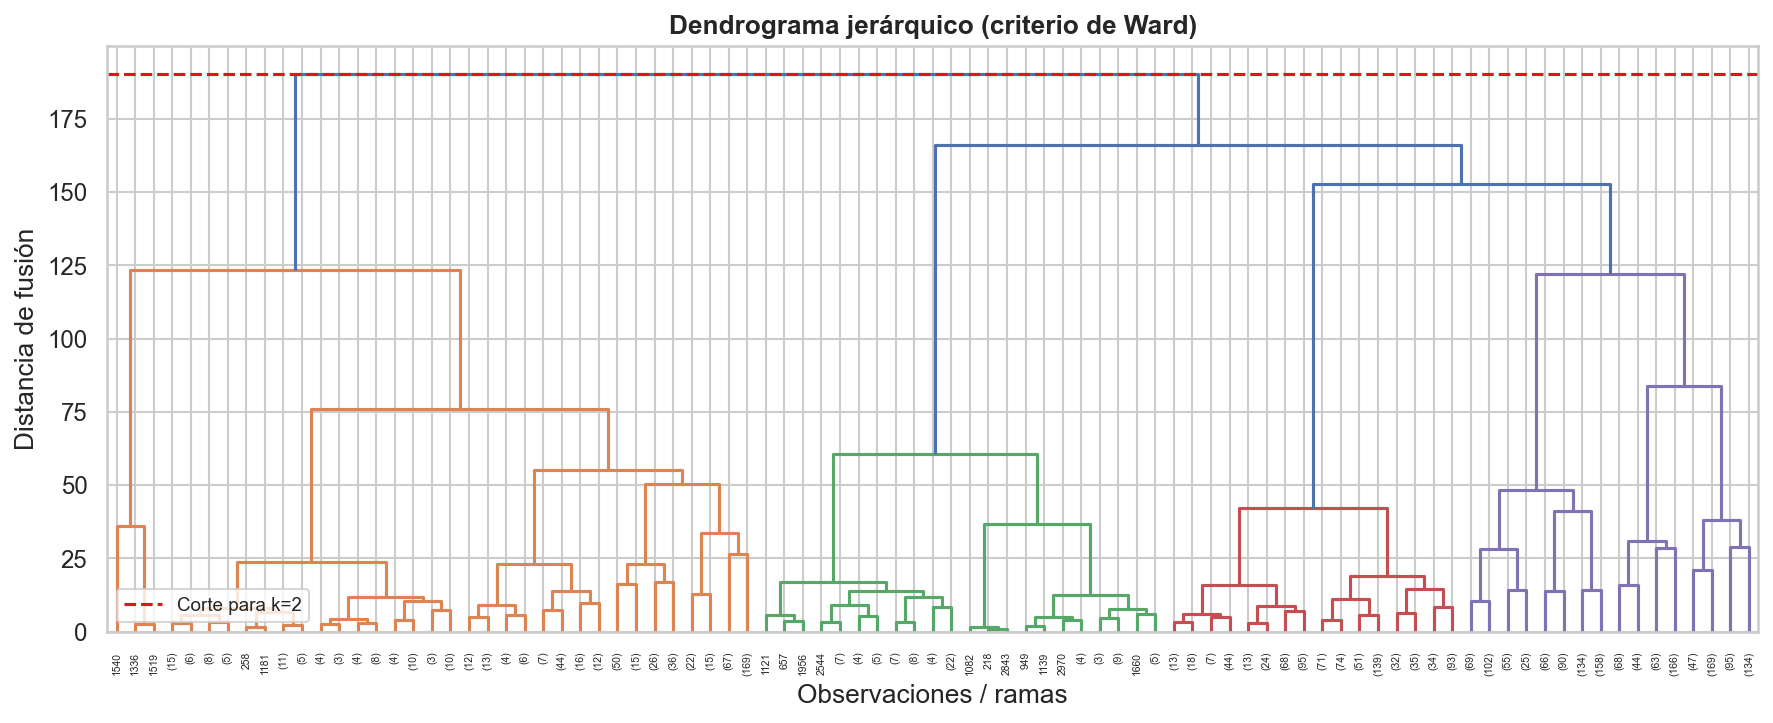

In [69]:
n_hc  = 3_000
sub_idx = X_cluster.sample(n_hc, random_state=RANDOM_STATE).index
sub_hc  = X_cluster.loc[sub_idx].copy()

Z = linkage(sub_hc, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, truncate_mode="level", p=6,
           color_threshold=0.7 * max(Z[:, 2]), ax=ax)
ax.set_title("Dendrograma jerárquico (criterio de Ward)", fontweight="bold")
ax.set_xlabel("Observaciones / ramas")
ax.set_ylabel("Distancia de fusión")
# Línea de corte para k_opt clusters
corte = Z[-(k_opt - 1), 2]
ax.axhline(corte, color=COLOR_ACCENT, linewidth=1.5,
           linestyle="--", label=f"Corte para k={k_opt}")
ax.legend(fontsize=9)
plt.tight_layout()

labels_hc = fcluster(Z, t=k_opt, criterion="maxclust") - 1  # 0-indexed
sil_hc    = silhouette_score(sub_hc, labels_hc,
                             sample_size=min(2_000, n_hc),
                             random_state=RANDOM_STATE)
print(f"\nSilueta jerárquico (Ward, submuestra, k={k_opt}): {sil_hc:.4f}")

8. Comparación k-means vs jerárquico


Concordancia K-means vs Jerárquico (submuestra):
Jerárquico Ward    0     1
K-means                   
0                612  2385
1                  3     0


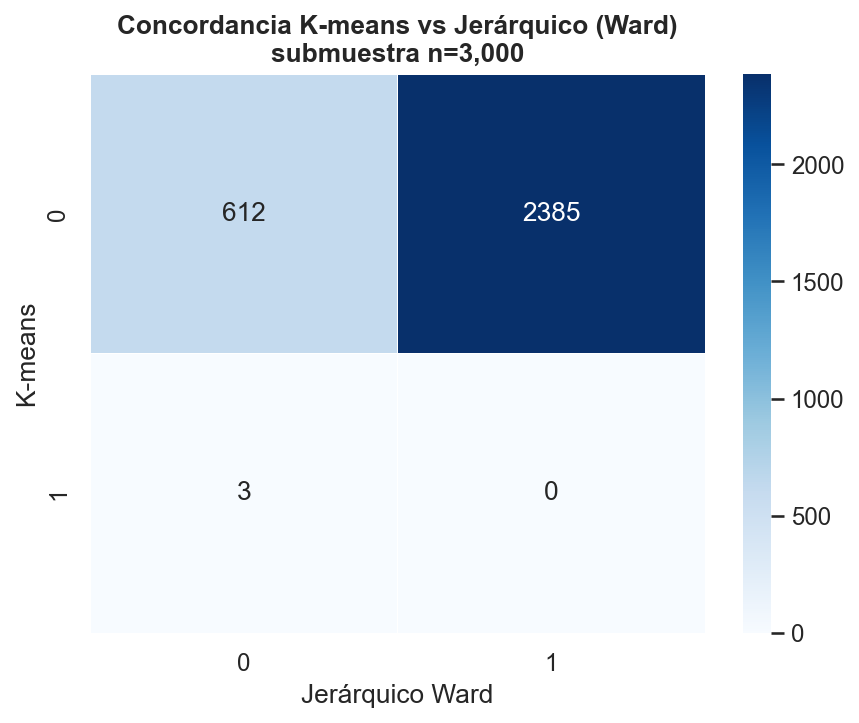

In [70]:
labels_km_sub = reducido.loc[sub_idx, "cluster_kmeans"].values
tabla_cruzada = pd.crosstab(
    pd.Series(labels_km_sub, name="K-means"),
    pd.Series(labels_hc,     name="Jerárquico Ward"),
)
print("\nConcordancia K-means vs Jerárquico (submuestra):")
print(tabla_cruzada.to_string())

# Heatmap de concordancia
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(tabla_cruzada, annot=True, fmt="d", cmap="Blues",
            linewidths=0.4, ax=ax)
ax.set_title("Concordancia K-means vs Jerárquico (Ward)\n"
             f"submuestra n={n_hc:,}", fontweight="bold")
plt.tight_layout()

In [71]:
resumen = pd.DataFrame({
    "modelo":        [f"K-means (k={k_opt})",
                      f"Jerárquico Ward (k={k_opt}, submuestra n={n_hc})"],
    "silueta_media": [sil_final, sil_hc],
})
print("\nResumen comparativo:")
print(resumen.round(4).to_string(index=False))

print(f"\n✓ Objeto 'reducido' listo con columna 'cluster_kmeans'.")
print(f"  Shape final: {reducido.shape}")


Resumen comparativo:
                                  modelo  silueta_media
                           K-means (k=2)         0.8874
Jerárquico Ward (k=2, submuestra n=3000)         0.3081

✓ Objeto 'reducido' listo con columna 'cluster_kmeans'.
  Shape final: (100000, 25)
